# 1. Environment Setup

In [72]:
import sys 
import subprocess
import importlib.util


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'datasets': 'datasets',
    'pyarrow': 'pyarrow',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'statsmodels': 'statsmodels', # For VIF calculation
    'sklearn': 'scikit-learn',
    'scipy': 'scipy',
    'pillow': 'pillow', # For Image downloading and processing
    'requests': 'requests', # For downloading images
    'torch': 'torch',
}

print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



In [73]:
import torch

if torch.cuda.is_available():
    print(f"CUDA: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
    DEVICE = torch.device("cuda")
else:
    print("CUDA not available; using CPU.")
    DEVICE = torch.device("cpu")

CUDA: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA capability: (12, 0)


In [74]:
# Import Required Libraries
import os
import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
from pathlib import Path
from datasets import load_dataset, Dataset
from scipy import stats

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from tqdm import tqdm
from PIL import Image
from io import BytesIO
import requests

# Disable HuggingFace Hub symlinks warning on Windows
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# 2. Configuration

In [75]:
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

PRODUCT_SIZE = 5 # Minimum number of reviews per product (parent level)
RANDOM_STATE = 42

SAMPLE_SIZE = 100_000

SAMPLED_FRACTION = 0.1 # Sample 10% of the data for clustering

# Get current working directory (robust)
BASE_DIR = Path.cwd()
IMAGE_DIR = BASE_DIR / "images" # Create images directory inside it

# 3. Load the Dataset

## 3.1 The entire dataset - 43M

In [76]:
# # CONFIGURATION
# REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

# print(f"Configuration:")
# print(f"  Source: Amazon Electronics Reviews (Hugging Face)\n")

## 3.2 Part dataset - 10K

In [77]:
# Load Dataset (Streaming)
import itertools

print(f"Loading {SAMPLE_SIZE:,} reviews from Amazon Electronics dataset...\n")

ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

df = Dataset.from_list(sample).to_pandas()

print(f"\nDataset loaded: {len(df):,} reviews.")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
print(f"  RANDOM STATE: {RANDOM_STATE}")

Loading 100,000 reviews from Amazon Electronics dataset...



Streaming: 100%|██████████| 100000/100000 [00:16<00:00, 5887.06it/s]



Dataset loaded: 100,000 reviews.
Memory Usage: 59.94 MB

  RANDOM STATE: 42


## 3.3 Overview

In [78]:
print("Shape of DataFrame:", df.shape)
print(f"Column Data Types:\n{df.dtypes}")

missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

print("Dataset preview:")
df.head(2)

Shape of DataFrame: (100000, 10)
Column Data Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
 No missing detected!
Dataset preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True


# 4. Content Filtering

In [79]:
print("Filtering for rows with valid content and required fields...")
rows_before = len(df)

# Remove rows where all elements are missing
df = df.dropna(how='all')
print(f"  After dropping completely empty rows: {df.shape[0]:,} rows")

# Keep rows with non-empty text OR title
df = df[(df['text'].fillna('').str.strip().str.len() > 0) | 
        (df['title'].fillna('').str.strip().str.len() > 0)]
print(f"  After filtering for content (text or title): {df.shape[0]:,} rows")

# Drop rows missing critical columns
df = df.dropna(subset=["text", "helpful_vote", "rating"])
print(f"  After dropping rows with missing critical fields: {df.shape[0]:,} rows")

# Summary
rows_dropped = rows_before - df.shape[0]
rows_pct = (rows_dropped / rows_before * 100) if rows_before > 0 else 0
print(f"\nTotal rows removed: {rows_dropped:,} ({rows_pct:.1f}%)\n")

Filtering for rows with valid content and required fields...
  After dropping completely empty rows: 100,000 rows
  After filtering for content (text or title): 100,000 rows
  After dropping rows with missing critical fields: 100,000 rows

Total rows removed: 0 (0.0%)



## 4.1 Filter Reviews as per helpful votes

Filtering to helpful_votes > 0 restricts the dataset to reviews that received actual community engagement, meaning at least one user interacted with the review and evaluated its usefulness.
This removes reviews that were never seen or evaluated by users, ensuring the model learns from socially validated feedback signals rather than treating unobserved reviews as implicitly “not helpful.”

In [80]:
df = df[df['helpful_vote'] > 0].copy()

print(f"  After filtering for helpful reviews, dataset shape: {df.shape[0]:,} rows.")

  After filtering for helpful reviews, dataset shape: 25,591 rows.


## 4.2 Product Level Filtering

Considering the reviews only when a product has at least 5 reviews that have helpful_votes>0.

In [81]:
# Count qualifying reviews per product (parent level)
product_counts = df.groupby("parent_asin").size()

# Identify products with at least 5 qualifying reviews
valid_products = product_counts[product_counts >= PRODUCT_SIZE].index

# Filter original dataframe
df = df[df["parent_asin"].isin(valid_products)]

print(f"  After filtering for products with >= {PRODUCT_SIZE} helpful reviews, dataset shape: {df.shape[0]:,} rows.\n")

  After filtering for products with >= 5 helpful reviews, dataset shape: 1,233 rows.



## 4.3 Drop unnecessary columns


- **user_id**: Drop user_id because reviewer identity does not generalise to unseen users, risks data leakage and bias, and adds privacy-sensitive information with no predictive value for review helpfulness.
- **asin**: Drop asin because it represents individual product variants (colour/size versions), which fragments the data and introduces artificial duplication, whereas parent_asin already groups all variants under the true product.

**parent_asin**: Keep parent_asin because it preserves product-level context needed for business insights, clustering, and later merchant recommendations.

In [82]:
df.drop(columns=['user_id'], inplace=True)
print(f"  After dropping 'user_id' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

df.drop(columns=['asin'], inplace=True)
print(f"  After dropping 'asin' column, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After dropping 'user_id' column, dataset shape: 1,233 x 9.
  After dropping 'asin' column, dataset shape: 1,233 x 8.


#  5. Feature Engineered

Convert the timestamp to datetime

In [83]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
print(f"  After converting 'timestamp' to datetime, dataset shape: {df.shape[0]:,} x {df.shape[1]:,}.")

  After converting 'timestamp' to datetime, dataset shape: 1,233 x 8.


Before Feature Engineering

In [84]:
print("Dataset Shape (BEFORE):")
print(f"  {df.shape[0]:,} rows x {df.shape[1]:,} columns\n")

print("Column Names:")
print(f"  {list(df.columns)}\n")

print("Data Types (BEFORE):")
print(df.dtypes)

Dataset Shape (BEFORE):
  1,233 rows x 8 columns

Column Names:
  ['rating', 'title', 'text', 'images', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase']

Data Types (BEFORE):
rating                      float64
title                           str
text                            str
images                       object
parent_asin                     str
timestamp            datetime64[ms]
helpful_vote                  int64
verified_purchase              bool
dtype: object


## 5.1 Textual Features

In [85]:
# Combine title and text with [SEP] token
df['combined_text'] = (
    df['title'].fillna("").str.strip() + " [SEP] " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Combine title and text without [SEP] token (alternative)
df['review_text'] = (
    df['title'].fillna("").str.strip() + " " + 
    df['text'].fillna("").str.strip()
).str.strip()

# Create review length feature
df['review_length'] = df['review_text'].str.len().fillna(0).astype('int32')

# Create review length feature
df['combined_text_length'] = df['combined_text'].str.len().fillna(0).astype('int32')

# Create title and text length features
df['title_length'] = df['title'].fillna("").str.len().astype('int16')
df['text_length'] = df['text'].fillna("").str.len().astype('int32')

# Create title to text ratio (zero-division safe)
df['title_to_text_ratio'] = (
    df['title_length'] / (df['text_length'] + 1)
).fillna(0).astype('float32')

# Count punctuation marks
df['exclamation_mark'] = df['combined_text'].str.count(r'!').fillna(0).astype('int16')
df['question_mark'] = df['combined_text'].str.count(r'\?').fillna(0).astype('int16')

# Word count
df['word_count'] = df['review_text'].fillna("").astype(str).str.split().str.len().fillna(0).astype('int32')

# Average characters per word (zero-division safe)
df['chars_per_word'] = (df['combined_text_length'] / df['word_count'].clip(lower=1)).round(4)

# Binary feature: is_long_review (1 if >200 words, else 0)
df['is_long'] = (df.get('word_count', 0) > 200).astype(int)

# Create binary feature: title_exists_only
df['title_exists_only'] = (
    (df['title'].notna()) & (df['title'].str.strip().ne('')) &
    ((df['text'].isna()) | (df['text'].str.strip().eq('')))
).astype('int8')

print("✓ Text features created:")
print("  - word_count, chars_per_word, is_long, title_exists_only")
print("  - combined_text, review_length, title_length, text_length")
print("  - title_to_text_ratio, exclamation_mark, question_mark")
print("  - review_text, combined_text_length (alternative combined feature)")

✓ Text features created:
  - word_count, chars_per_word, is_long, title_exists_only
  - combined_text, review_length, title_length, text_length
  - title_to_text_ratio, exclamation_mark, question_mark
  - review_text, combined_text_length (alternative combined feature)


## 5.2 Image and Media Features

In [86]:
# Create image features
df['image_count'] = df['images'].apply(
    lambda x: len(x) if isinstance(x, (list, np.ndarray)) else 0
).astype('int16')

df['has_image'] = (df['image_count'] > 0).astype('int8')

df['image_bucket'] = pd.cut(
    df['image_count'].fillna(0),
    bins=[-1, 0, 1, 2, np.inf],
    labels=['0 images', '1 image', '2 images', '3+ images'],
    ordered=True
)

print("✓ Image features created:")
print("  - image_count, has_image, image_bucket")

✓ Image features created:
  - image_count, has_image, image_bucket


## 5.3 Temporal Features

In [87]:
# Extract temporal features
df['day_of_week'] = df['timestamp'].dt.dayofweek.astype('int8')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype('int8')
df['year'] = df['timestamp'].dt.year

# Days since first review
first_review_date = df['timestamp'].min()
df['days_since_first_review'] = (
    (df['timestamp'] - first_review_date).dt.days
).fillna(0).astype('int32')

print("✓ Temporal features created:")
print("  - day_of_week, is_weekend, days_since_first_review")

✓ Temporal features created:
  - day_of_week, is_weekend, days_since_first_review


## 5.4 Purchase & Product Features

In [88]:
# Convert verified_purchase to binary feature
df['is_verified'] = df['verified_purchase'].astype('int8')
if 'verified_purchase' in df.columns:
    df = df.drop(columns=['verified_purchase'])

# Product popularity (review count per parent_asin)
df['product_popularity'] = (
    df.groupby('parent_asin')['parent_asin']
    .transform('count')
    .astype('int32')
)

# Log-transform product popularity to reduce skewness
df['log_popularity'] = np.log1p(df['product_popularity'])

print("✓ Purchase & Product features created:")
print("  - is_verified (from verified_purchase), product_popularity, log_popularity")

✓ Purchase & Product features created:
  - is_verified (from verified_purchase), product_popularity, log_popularity


## 5.5 Rating

In [89]:
# Derive sentiment (categorical)
sentiment_map = {
    1: 'very_negative', 
    2: 'negative', 
    3: 'neutral',
    4: 'positive',       
    5: 'very_positive'
}
df['sentiment'] = df['rating'].map(sentiment_map)

# rating_extremity: distance from neutral → captures U-shaped helpfulness
df['rating_extremity'] = (df['rating'] - 3).abs()

print("✓ Rating features created:")
print("  - sentiment (categorical), rating_extremity (numerical)")

✓ Rating features created:
  - sentiment (categorical), rating_extremity (numerical)


# 6. Target Variable 

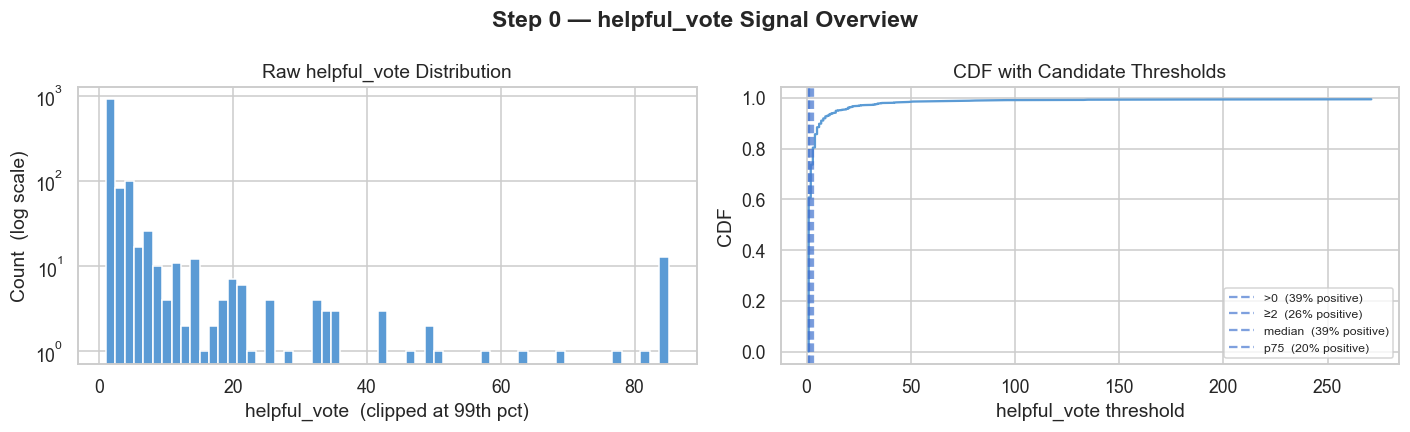

  Threshold  Positive N  Negative N Positive %     Ratio Imbalance Risk
  > 0  :EDA        1233           0     100.0% 1233.00:1           High
> 1: MEDIAN         484         749      39.3%    0.65:1            Low
   > 3: P75         242         991      19.6%    0.24:1       Moderate


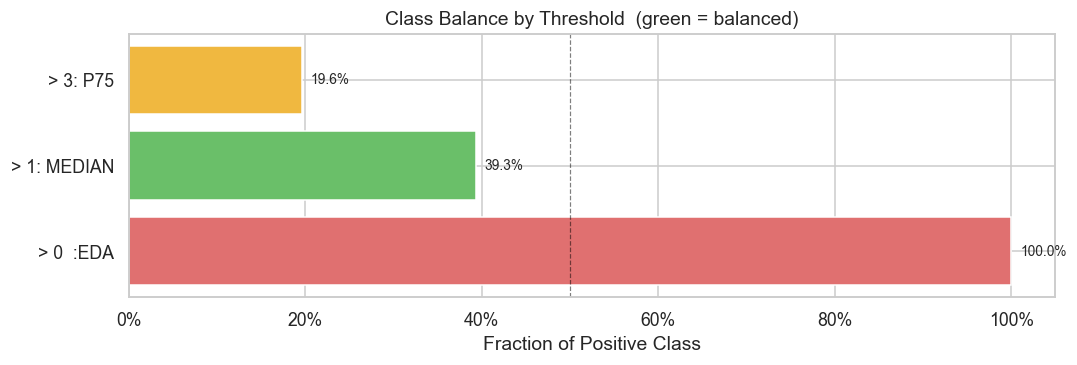

In [90]:
hv = df['helpful_vote'].clip(upper=df['helpful_vote'].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (log y-scale to show the long tail)
axes[0].hist(hv, bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_xlabel('helpful_vote  (clipped at 99th pct)')
axes[0].set_ylabel('Count  (log scale)')
axes[0].set_title('Raw helpful_vote Distribution')

# Right: CDF — helps us read off threshold positions directly
sorted_hv = np.sort(df['helpful_vote'].values)
cdf = np.arange(1, len(sorted_hv) + 1) / len(sorted_hv)
axes[1].plot(sorted_hv[:int(0.995 * len(sorted_hv))],
             cdf[:int(0.995 * len(sorted_hv))], color='#5b9bd5')
for t, lbl in [(1, '>0'), (2, '≥2'),
               (int(df['helpful_vote'].median()), 'median'),
               (int(df['helpful_vote'].quantile(0.75)), 'p75')]:
    pct = (df['helpful_vote'] > t).mean() if t > 0 else (df['helpful_vote'] >= t).mean()
    axes[1].axvline(t, linestyle='--', alpha=0.7, label=f'{lbl}  ({pct:.0%} positive)')
axes[1].set_xlabel('helpful_vote threshold')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF with Candidate Thresholds')
axes[1].legend(fontsize=8)

plt.suptitle('Step 0 — helpful_vote Signal Overview', fontweight='bold')
plt.tight_layout(); plt.show()


# Threshold Sensitivity Analysis
median_hv = int(df['helpful_vote'].median())
p75_hv    = int(df['helpful_vote'].quantile(0.75))

thresholds = [
    ('> 0  :EDA',    df['helpful_vote'].gt(0)),
    (f'> {median_hv}: MEDIAN',  df['helpful_vote'].gt(median_hv)),
    (f'> {p75_hv}: P75',  df['helpful_vote'].gt(p75_hv)),
]

rows = []
for name, mask in thresholds:
    pos = mask.sum()
    neg = (~mask).sum()
    pct = pos / len(df)
    rows.append({'Threshold': name, 'Positive N': pos, 'Negative N': neg,
                 'Positive %': f'{pct:.1%}', 'Ratio': f'{pos/max(neg,1):.2f}:1',
                 'Imbalance Risk': 'High' if pct < 0.15 or pct > 0.85 else
                                   'Moderate' if pct < 0.25 or pct > 0.75 else 'Low'})

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

# Visualise class balance
fig, ax = plt.subplots(figsize=(10, 3.5))
names  = [r['Threshold'] for r in rows]
ratios = [float(r['Positive %'].strip('%')) / 100 for r in rows]
bars = ax.barh(names, ratios, color=['#e07070' if r > 0.80 or r < 0.15
                                     else '#f0b840' if r > 0.70 or r < 0.25
                                     else '#6abf69' for r in ratios])
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Fraction of Positive Class')
ax.set_title('Class Balance by Threshold  (green = balanced)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, r in zip(bars, ratios):
    ax.text(r + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{r:.1%}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 6.1 Create the Target Variable

- Using Median (1) as a threshold

In [91]:
# Calculate helpful threshold using median
HELPFUL_THRESHOLD = df['helpful_vote'].median()

# Create target variable
df['is_helpful'] = (df['helpful_vote'] > HELPFUL_THRESHOLD).astype('int8')

print(f"Target Variable Distribution:")
print(df['is_helpful'].value_counts().sort_index())
print(f"\nClass Proportions:")
print(df['is_helpful'].value_counts(normalize=True).sort_index())

Target Variable Distribution:
is_helpful
0    749
1    484
Name: count, dtype: int64

Class Proportions:
is_helpful
0    0.607461
1    0.392539
Name: proportion, dtype: float64


# 7. Feature Analysis

## 7.1 Helper Functions

In [92]:
def two_class_dist(feature: str, label: str = 'is_helpful', clip_pct: float = 0.99,
                   xlabel: str = None, title: str = None):
    """KDE + rug for a numeric feature split by binary target."""
    sub = df[[feature, label]].dropna()
    q   = sub[feature].quantile(clip_pct)
    sub = sub[sub[feature] <= q]
    fig, ax = plt.subplots(figsize=(9, 4))
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub[label] == val, feature], ax=ax,
                    fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_xlabel(xlabel or feature)
    ax.set_title(title or f'Distribution of `{feature}` by Helpfulness')
    ax.legend()
    plt.tight_layout(); plt.show()
    # Point-biserial correlation
    r, p = stats.pointbiserialr(sub[label], sub[feature])
    print(f"  Point-biserial r = {r:+.4f}  (p = {p:.3g})")

def bar_vs_target(feature: str, label: str = 'is_helpful', title: str = None):
    """Stacked bar: proportion helpful per category."""
    sub = df[[feature, label]].dropna()
    order = sorted(sub[feature].unique())
    prop  = sub.groupby(feature)[label].mean()
    counts = sub[feature].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(prop.index.astype(str), prop.values, color='#5b9bd5', edgecolor='white')
    ax.set_ylabel('Proportion Helpful')
    ax.set_xlabel(feature)
    ax.set_title(title or f'Helpfulness Rate by `{feature}`')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for x, (cat, val) in enumerate(prop.items()):
        ax.text(x, val + 0.005, f'{counts[cat]:,}', ha='center', fontsize=8, color='#555')
    plt.tight_layout(); plt.show()

def compute_mi(features: list, label: str = 'is_helpful', n: int = 100_000) -> pd.Series:
    """Mutual information (classification) for a list of numeric features."""
    sub = df[features + [label]].dropna()
    if len(sub) > n:
        sub = sub.sample(n, random_state=RANDOM_STATE)
    X = sub[features].fillna(0)
    y = sub[label]
    mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    return pd.Series(mi, index=features).sort_values(ascending=False)

def vif_table(features: list) -> pd.DataFrame:
    """Variance Inflation Factor for a list of features."""
    sub = df[features].dropna().sample(min(50_000, len(df)), random_state=RANDOM_STATE)
    X   = sub.fillna(0)
    vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return pd.DataFrame({'Feature': features, 'VIF': vif}).sort_values('VIF', ascending=False)

print("Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table")

Helpers defined: two_class_dist, bar_vs_target, compute_mi, vif_table


## 7.2 Analysis

### Textual Features

In [93]:
print("Descriptive stats for combined_text:")
print(df['combined_text'].describe())

Descriptive stats for combined_text:
count                                                  1233
unique                                                 1233
top       Very nice! I love my new larger screen Kindle ...
freq                                                      1
Name: combined_text, dtype: object



Estimated > 256 tokens (DistilBERT max): 21.3% of reviews → will be truncated


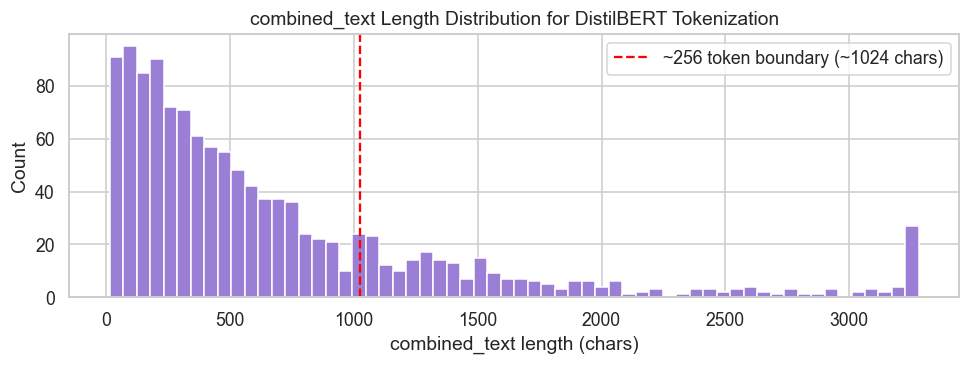


Estimated > 512 tokens (DistilBERT max): 5.9% of reviews → will be truncated


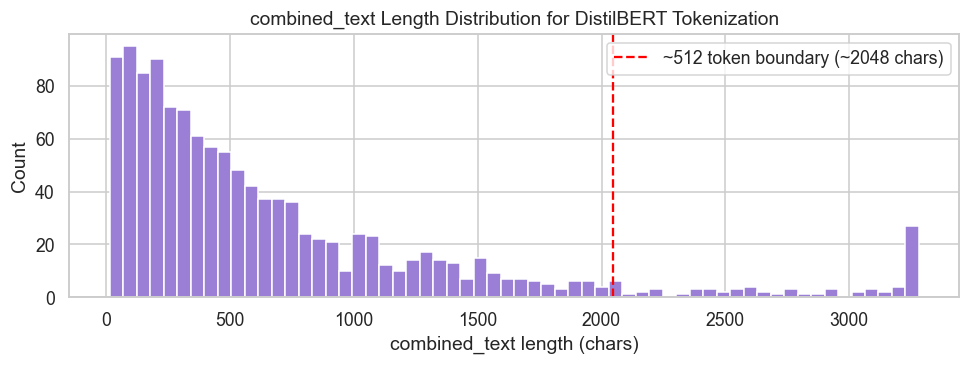

In [94]:
tokens = [256, 512]

for token in tokens:
    # Token length estimate (rough: 1 token ≈ 4 chars)
    est_tokens = (df['combined_text_length'] / 4).round(0).astype(int)
    over_limit = (est_tokens > token).mean()
    print(f"\nEstimated > {token} tokens (DistilBERT max): {over_limit:.1%} of reviews → will be truncated")

    # Length distribution
    fig, ax = plt.subplots(figsize=(9, 3.5))
    clip = df['combined_text_length'].quantile(0.98)
    ax.hist(df['combined_text_length'].clip(upper=clip), bins=60, color='#9b7fd6', edgecolor='white')
    ax.axvline(token * 4, color='red', linestyle='--', label=f'~{token} token boundary (~{token * 4} chars)')
    ax.set_xlabel('combined_text length (chars)')
    ax.set_ylabel('Count')
    ax.set_title('combined_text Length Distribution for DistilBERT Tokenization')
    ax.legend()
    plt.tight_layout(); plt.show()

In [95]:
has_text = (df['text'].notna()) & (df['text'].str.strip().ne(''))
only_title = (~has_text) & (df['title'].notna()) & (df['title'].str.strip().ne(''))

# Create comparison
comparison = pd.DataFrame({
    'Group': ['Title + Text', 'Title Only'],
    'Count': [has_text.sum(), only_title.sum()],
    'Helpful Count': [
        df.loc[has_text, 'is_helpful'].sum(),
        df.loc[only_title, 'is_helpful'].sum()
    ],
    'Helpfulness Rate': [
        df.loc[has_text, 'is_helpful'].mean(),
        df.loc[only_title, 'is_helpful'].mean()
    ]
})

print("="*70)
print("HELPFULNESS COMPARISON: Title+Text vs Title Only")
print("="*70)
print(comparison.to_string(index=False))

HELPFULNESS COMPARISON: Title+Text vs Title Only
       Group  Count  Helpful Count  Helpfulness Rate
Title + Text   1233            484          0.392539
  Title Only      0              0               NaN


Reviews with title but no text:
title_exists_only
0    1233
Name: count, dtype: int64

Proportion: 0.000%

HELPFULNESS ANALYSIS: Title Exists But Text Does Not


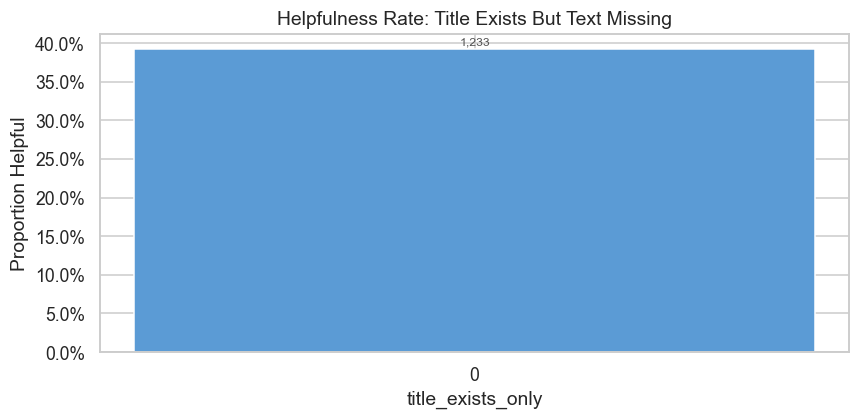


Point-biserial correlation: r = +nan  (p = nan)

is_helpful         Not Helpful  Helpful  Total
title_exists_only                             
Text Present               749      484   1233
Total                      749      484   1233


In [96]:
print("Reviews with title but no text:")
print(df['title_exists_only'].value_counts())
print(f"\nProportion: {df['title_exists_only'].mean():.3%}")

# Analyze relationship with is_helpful
print("\n" + "="*60)
print("HELPFULNESS ANALYSIS: Title Exists But Text Does Not")
print("="*60)

bar_vs_target('title_exists_only', 
              title='Helpfulness Rate: Title Exists But Text Missing')

# Correlation
sub = df[['is_helpful', 'title_exists_only']].dropna()
r, p = stats.pointbiserialr(sub['is_helpful'], sub['title_exists_only'])
print(f"\nPoint-biserial correlation: r = {r:+.4f}  (p = {p:.3g})")

# Cross-tabulation
print("\n" + "="*60)
ct = pd.crosstab(df['title_exists_only'], df['is_helpful'], margins=True)
ct = ct.rename(index={0: 'Text Present', 1: 'Text Missing', 'All': 'Total'},
               columns={0: 'Not Helpful', 1: 'Helpful', 'All': 'Total'})
print(ct)

### Lexical Features

Descriptive stats for review_length:
count    1233.0
mean      709.6
std       871.0
min         7.0
25%       197.0
50%       438.0
75%       882.0
max      9123.0
Name: review_length, dtype: float64


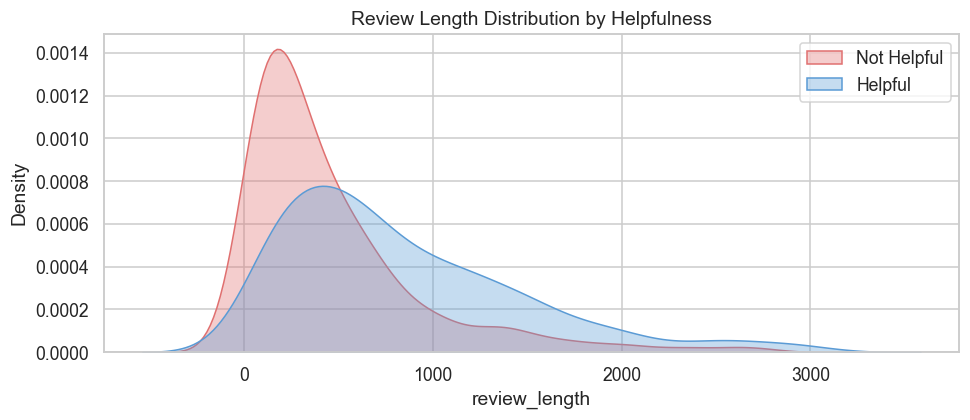

  Point-biserial r = +0.3145  (p = 7.08e-29)
  Median length — Not Helpful: 299 chars
  Median length — Helpful: 720 chars


In [97]:
print("Descriptive stats for review_length:")
print(df['review_length'].describe().round(1))

two_class_dist('review_length', clip_pct=0.97,
               title='Review Length Distribution by Helpfulness')

# Median length by helpfulness class
for cls, lbl in [(0, 'Not Helpful'), (1, 'Helpful')]:
    med = df.loc[df['is_helpful'] == cls, 'review_length'].median()
    print(f"  Median length — {lbl}: {med:.0f} chars")

  r(word_count, review_length) = 0.9983
  r(chars_per_word, review_length) = -0.1219


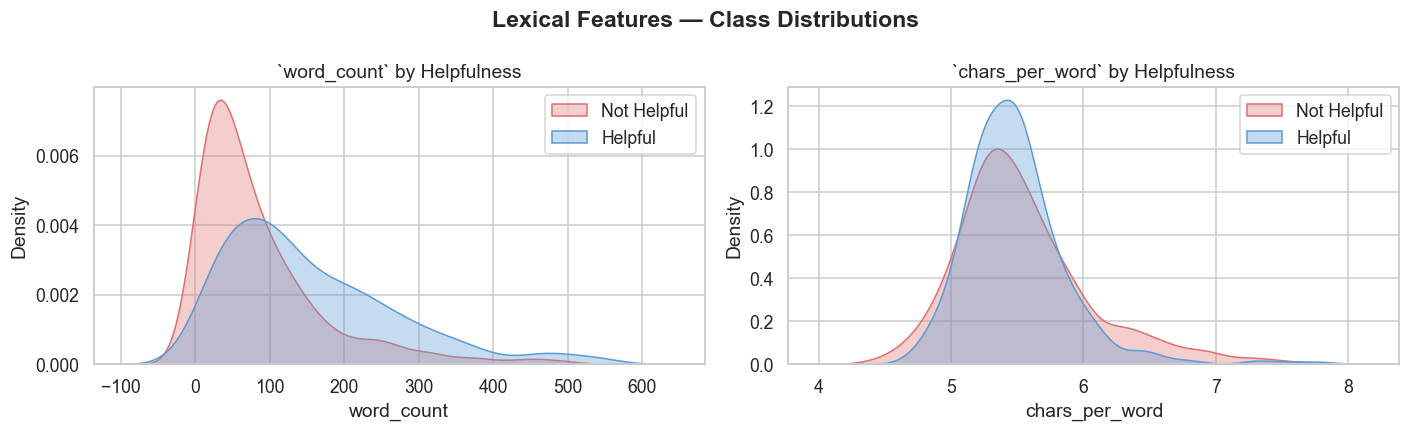

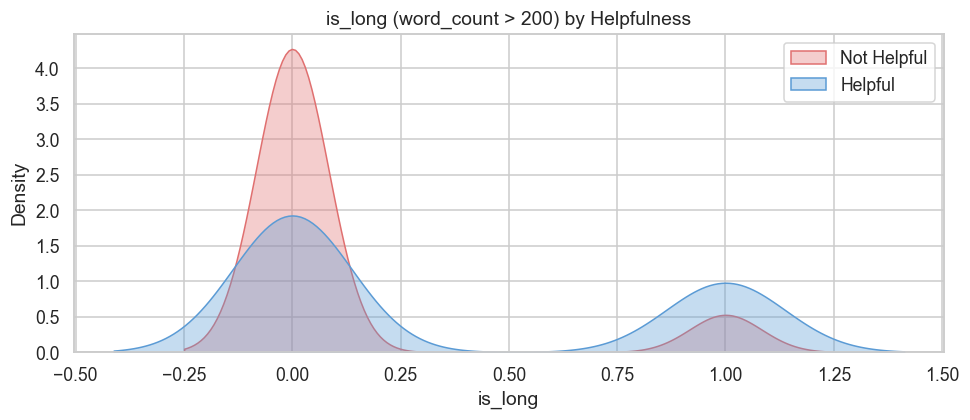

  Point-biserial r = +0.2782  (p = 2.41e-23)


In [98]:
# Correlation: word_count vs review_length
for f1, f2 in [('word_count', 'review_length'), ('chars_per_word', 'review_length')]:
    if f1 in df.columns and f2 in df.columns:
        r = df[[f1, f2]].corr().iloc[0, 1]
        print(f"  r({f1}, {f2}) = {r:.4f}")

# Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat, clip in zip(axes, ['word_count', 'chars_per_word'], [0.97, 0.99]):
    if feat not in df.columns:
        continue
    sub = df[[feat, 'is_helpful']].dropna()
    q   = sub[feat].quantile(clip)
    sub = sub[sub[feat] <= q]
    for val, lbl, col in [(0, 'Not Helpful', '#e07070'), (1, 'Helpful', '#5b9bd5')]:
        sns.kdeplot(sub.loc[sub['is_helpful'] == val, feat],
                    ax=ax, fill=True, alpha=0.35, label=lbl, color=col)
    ax.set_title(f'`{feat}` by Helpfulness')
    ax.legend()
plt.suptitle('Lexical Features — Class Distributions', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('is_long', title='is_long (word_count > 200) by Helpfulness')

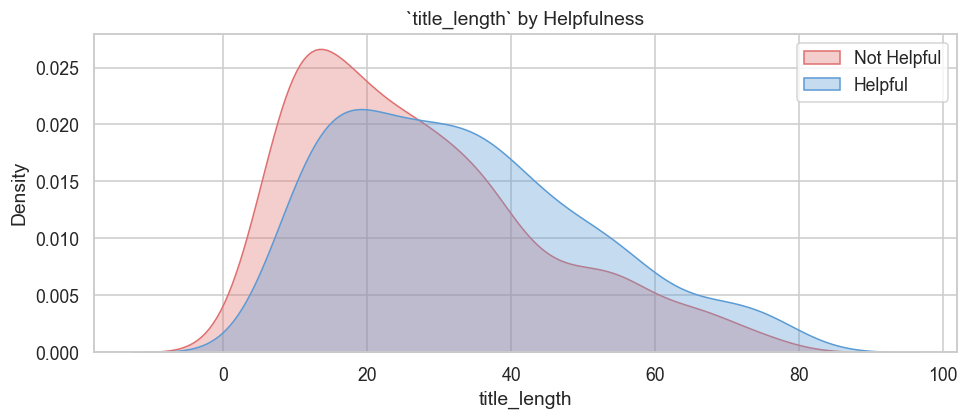

  Point-biserial r = +0.1712  (p = 2.55e-09)


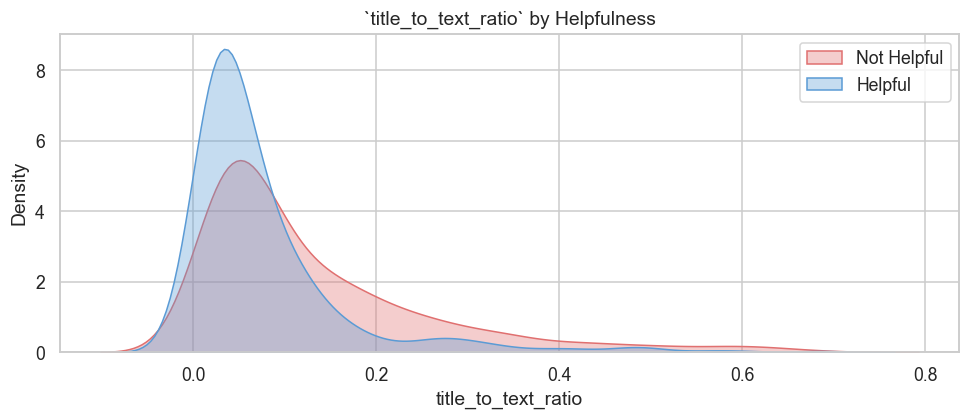

  Point-biserial r = -0.2245  (p = 3.96e-15)

  r(text_length, review_length) = 0.9997  ← redundant


In [99]:
for feat in ['title_length', 'title_to_text_ratio']:
    two_class_dist(feat, clip_pct=0.97, title=f'`{feat}` by Helpfulness')

# Correlation with review_length
if 'text_length' in df.columns:
    r = df[['text_length', 'review_length']].corr().iloc[0, 1]
    print(f"\n  r(text_length, review_length) = {r:.4f}  "
            f"← {'redundant' if abs(r) > 0.95 else 'non-redundant'}")

Descriptive stats for exclamation marks:
count    1233.0
mean        1.0
std         2.3
min         0.0
25%         0.0
50%         0.0
75%         1.0
max        31.0
Name: exclamation_mark, dtype: float64


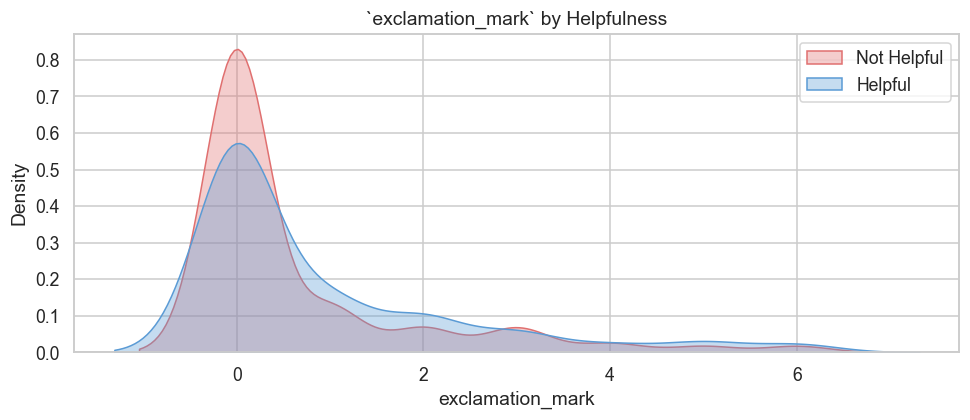

  Point-biserial r = +0.0911  (p = 0.00157)


In [100]:
print("Descriptive stats for exclamation marks:")
print(df['exclamation_mark'].describe().round(1))

two_class_dist('exclamation_mark', clip_pct=0.97, title=f'`exclamation_mark` by Helpfulness')

Descriptive stats for question marks:
count    1233.0
mean        0.2
std         0.8
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        18.0
Name: question_mark, dtype: float64


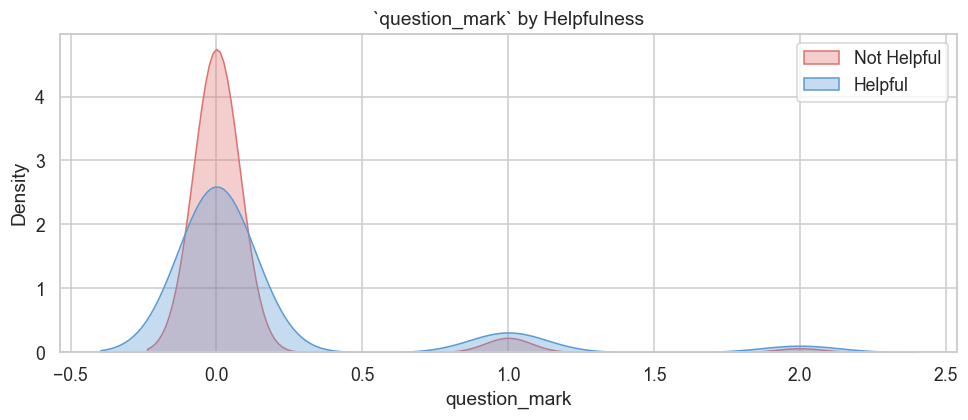

  Point-biserial r = +0.1326  (p = 3.36e-06)


In [101]:
print("Descriptive stats for question marks:")
print(df['question_mark'].describe().round(1))

two_class_dist('question_mark', clip_pct=0.97, title=f'`question_mark` by Helpfulness')

### Image and Media Features

Descriptive stats for image_count:
count    1233.000000
mean        0.158151
std         0.775100
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.000000
Name: image_count, dtype: float64


Descriptive stats for has_image:
count    1233.000000
mean        0.065693
std         0.247846
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: has_image, dtype: float64

r(image_count, has_image) = 0.7698	 ← high → has_image is redundant


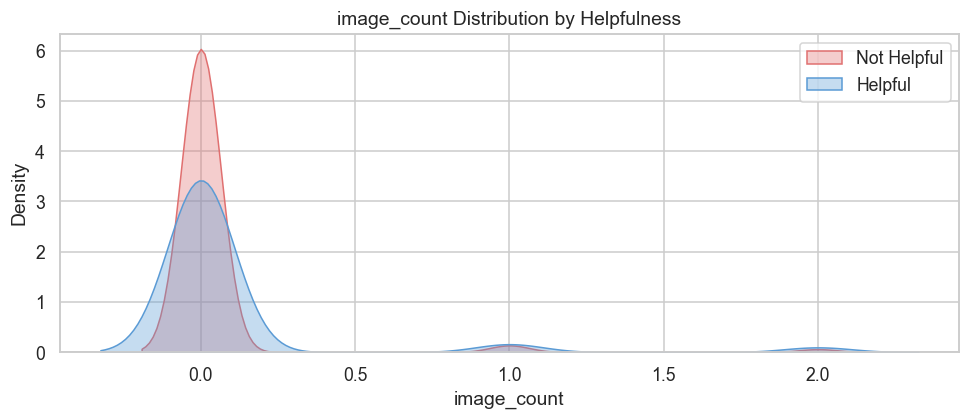

  Point-biserial r = +0.0884  (p = 0.00212)


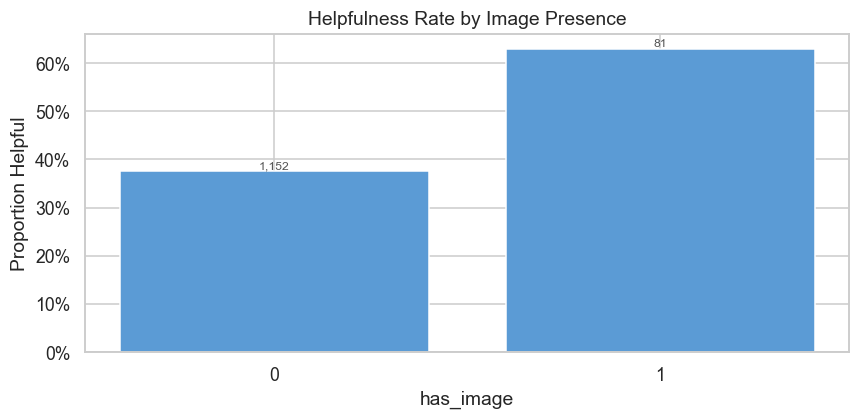

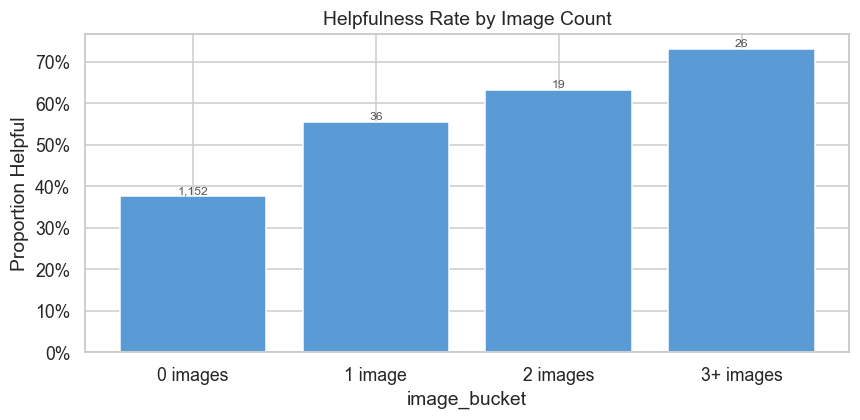

In [102]:
IMAGE_FEATURES = ['image_count', 'has_image']

print("Descriptive stats for image_count:")
print(df['image_count'].describe())

print("\n\nDescriptive stats for has_image:")
print(df['has_image'].describe())

# Correlation between image_count and has_image
r_img = df[['image_count', 'has_image']].corr().iloc[0, 1]
print(f"\nr(image_count, has_image) = {r_img:.4f}\t ← high → has_image is redundant")

# Visualize image_count distribution by helpfulness
two_class_dist('image_count', 
            clip_pct=0.97,
            title='image_count Distribution by Helpfulness')

# Visualize has_image by helpfulness (binary feature)
bar_vs_target('has_image', title='Helpfulness Rate by Image Presence')

# Helpfulness rate: 0, 1, 2, 3+ images
bar_vs_target('image_bucket', title='Helpfulness Rate by Image Count')


### Temporal Feature

In [103]:
# days_since_first_review: how long has this review been live?
if 'days_since_first_review' not in df.columns:
    ref_date = df['review_date'].max()   # NOTE: use train-set max in production!
    df['days_since_first_review'] = (ref_date - df['review_date']).dt.days
    print(f"Computed days_since_first_review  (ref = {ref_date.date()})")
    print("WARNING: ref_date must be computed from TRAIN set only in production.")

print("\n=== year distribution ===")
print(df['year'].value_counts().sort_index().head(10))


=== year distribution ===
year
2007      1
2008      6
2009      7
2010      5
2011     20
2012     40
2013     38
2014     63
2015     87
2016    149
Name: count, dtype: int64


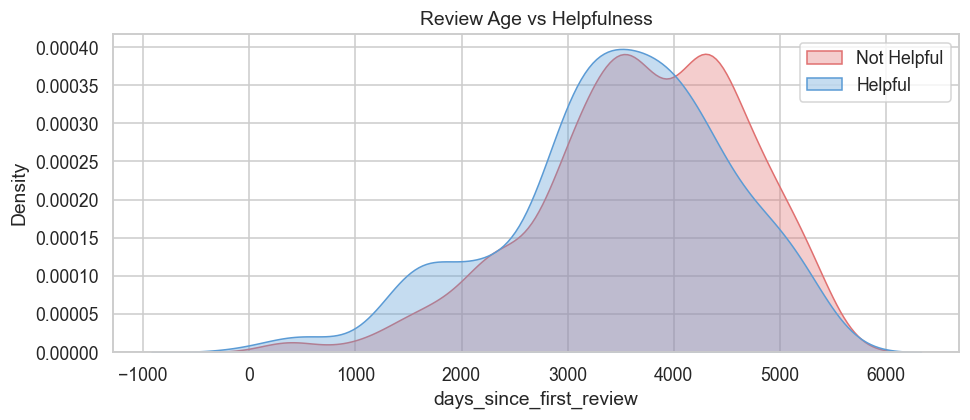

  Point-biserial r = -0.1168  (p = 5.13e-05)


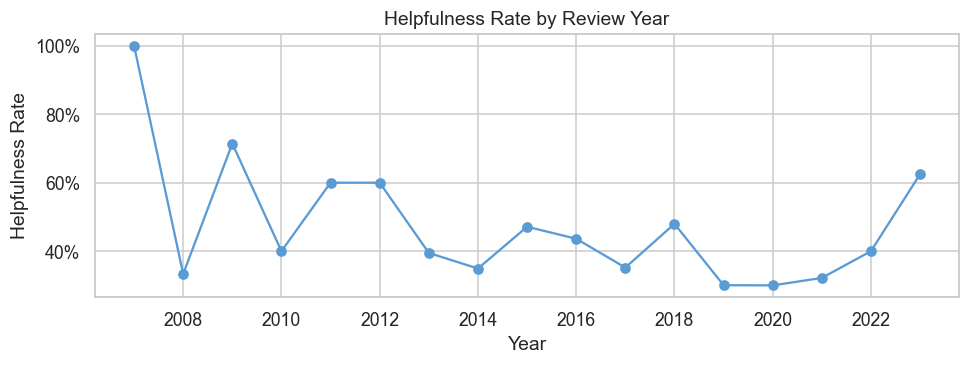

In [104]:
two_class_dist('days_since_first_review', clip_pct=0.97,
                title='Review Age vs Helpfulness')

# Year-level trend
if 'year' in df.columns:
    yr_help = df.groupby('year')['is_helpful'].mean()
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(yr_help.index, yr_help.values, marker='o', color='#5b9bd5')
    ax.set_xlabel('Year')
    ax.set_ylabel('Helpfulness Rate')
    ax.set_title('Helpfulness Rate by Review Year')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.tight_layout(); plt.show()

### Purchase & Product Features

Descriptive stats for product_popularity:
count    1233.0
mean       11.2
std         9.5
min         5.0
25%         5.0
50%         6.0
75%        11.0
max        36.0
Name: product_popularity, dtype: float64
Descriptive stats for log_popularity:
count    1233.0
mean        2.3
std         0.6
min         1.8
25%         1.8
50%         1.9
75%         2.5
max         3.6
Name: log_popularity, dtype: float64


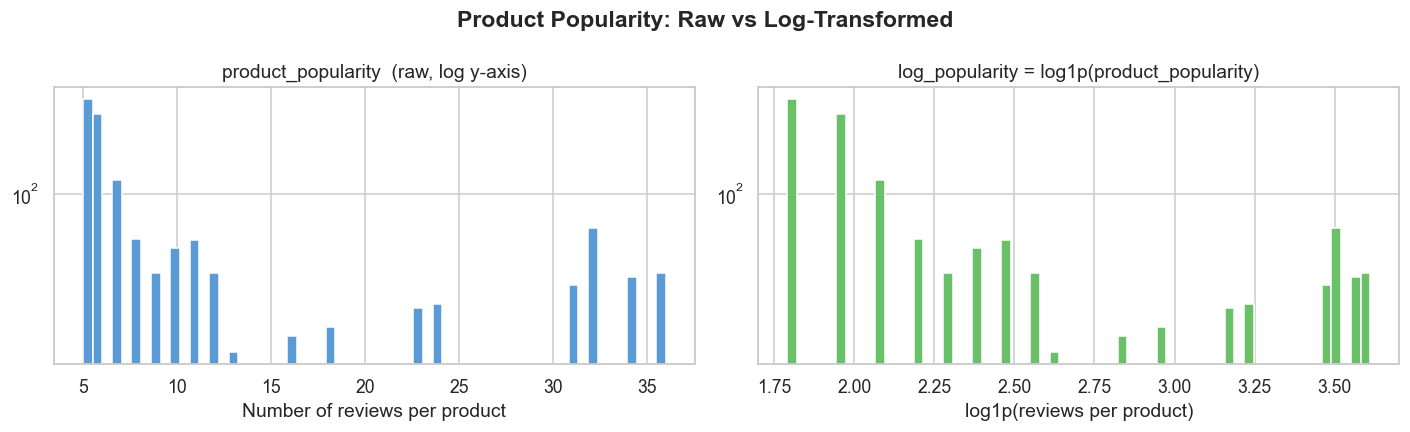

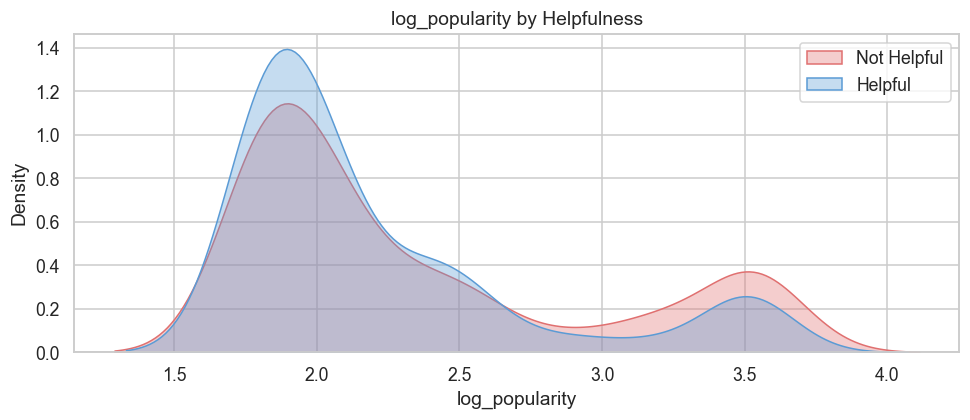

  Point-biserial r = -0.1136  (p = 6.4e-05)

  Spearman r — product_popularity (raw): -0.0903
  Spearman r — log_popularity:           -0.0903


In [105]:
print("Descriptive stats for product_popularity:")
print(df['product_popularity'].describe().round(1))

print("Descriptive stats for log_popularity:")
print(df['log_popularity'].describe().round(1))


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution — log y to show the power law
axes[0].hist(df['product_popularity'].clip(upper=df['product_popularity'].quantile(0.99)),
                bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_title('product_popularity  (raw, log y-axis)')
axes[0].set_xlabel('Number of reviews per product')

# Log-transformed
axes[1].hist(df['log_popularity'], bins=60, color='#6abf69', edgecolor='white', log=True)
axes[1].set_title('log_popularity = log1p(product_popularity)')
axes[1].set_xlabel('log1p(reviews per product)')

plt.suptitle('Product Popularity: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('log_popularity', title='log_popularity by Helpfulness')

r_raw = stats.spearmanr(df['product_popularity'].dropna(),
                            df['is_helpful'][:len(df['product_popularity'].dropna())]).correlation
r_log = stats.spearmanr(df['log_popularity'].dropna(),
                            df['is_helpful'][:len(df['log_popularity'].dropna())]).correlation
print(f"\n  Spearman r — product_popularity (raw): {r_raw:+.4f}")
print(f"  Spearman r — log_popularity:           {r_log:+.4f}")

### Rating

rating
1.0    195
2.0     67
3.0     89
4.0    193
5.0    689
Name: count, dtype: int64

Missing: 0


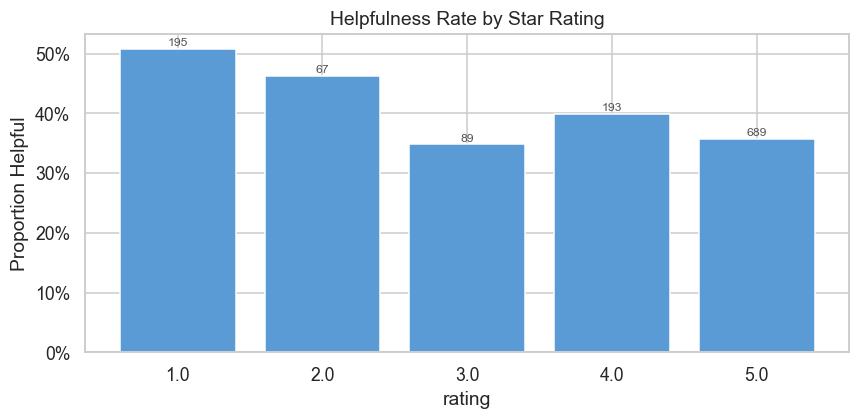

  rating                 point-biserial r = -0.1074  p = 0.000157
  rating_extremity       point-biserial r = +0.0053  p = 0.854


In [106]:
print(df['rating'].value_counts().sort_index())
print(f"\nMissing: {df['rating'].isna().sum()}")

bar_vs_target('rating', title='Helpfulness Rate by Star Rating')

# Correlations
for feat in ['rating', 'rating_extremity']:
    if feat in df.columns:
        sub = df[['is_helpful', feat]].dropna()

        r, p = stats.pointbiserialr(
            sub['is_helpful'],
            sub[feat]
        )
        print(f"  {feat:<22} point-biserial r = {r:+.4f}  p = {p:.3g}")

### Verified Purchase

Descriptive stats for log_popularity:
count    1233.0
mean        2.3
std         0.6
min         1.8
25%         1.8
50%         1.9
75%         2.5
max         3.6
Name: log_popularity, dtype: float64


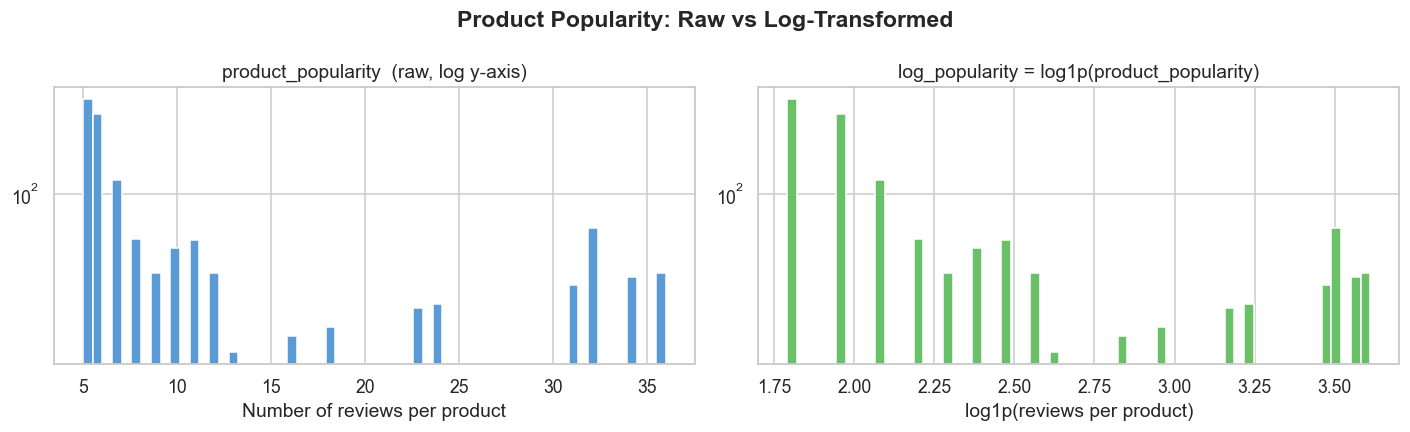

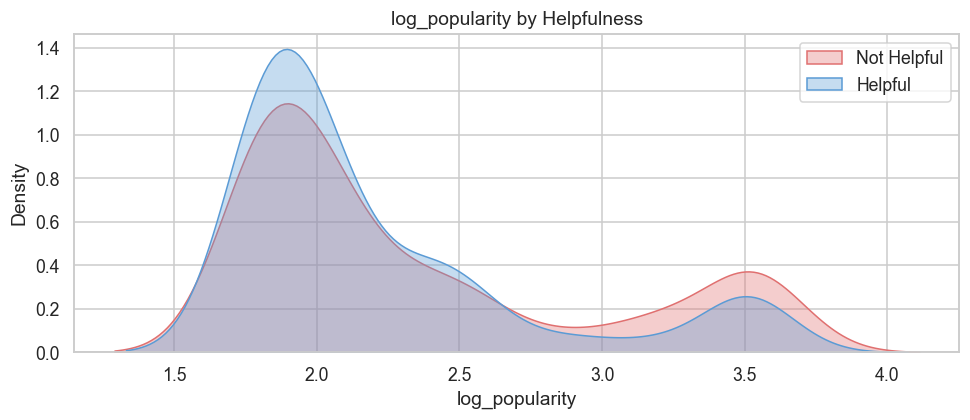

  Point-biserial r = -0.1136  (p = 6.4e-05)

  Spearman r — product_popularity (raw): -0.0903
  Spearman r — log_popularity:           -0.0903


In [107]:
print("Descriptive stats for log_popularity:")
print(df['log_popularity'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw distribution — log y to show the power law
axes[0].hist(df['product_popularity'].clip(upper=df['product_popularity'].quantile(0.99)),
                bins=60, color='#5b9bd5', edgecolor='white', log=True)
axes[0].set_title('product_popularity  (raw, log y-axis)')
axes[0].set_xlabel('Number of reviews per product')

# Log-transformed
axes[1].hist(df['log_popularity'], bins=60, color='#6abf69', edgecolor='white', log=True)
axes[1].set_title('log_popularity = log1p(product_popularity)')
axes[1].set_xlabel('log1p(reviews per product)')

plt.suptitle('Product Popularity: Raw vs Log-Transformed', fontweight='bold')
plt.tight_layout(); plt.show()

two_class_dist('log_popularity', title='log_popularity by Helpfulness')

r_raw = stats.spearmanr(df['product_popularity'].dropna(),
                            df['is_helpful'][:len(df['product_popularity'].dropna())]).correlation
r_log = stats.spearmanr(df['log_popularity'].dropna(),
                            df['is_helpful'][:len(df['log_popularity'].dropna())]).correlation
print(f"\n  Spearman r — product_popularity (raw): {r_raw:+.4f}")
print(f"  Spearman r — log_popularity:           {r_log:+.4f}")

### Overall 

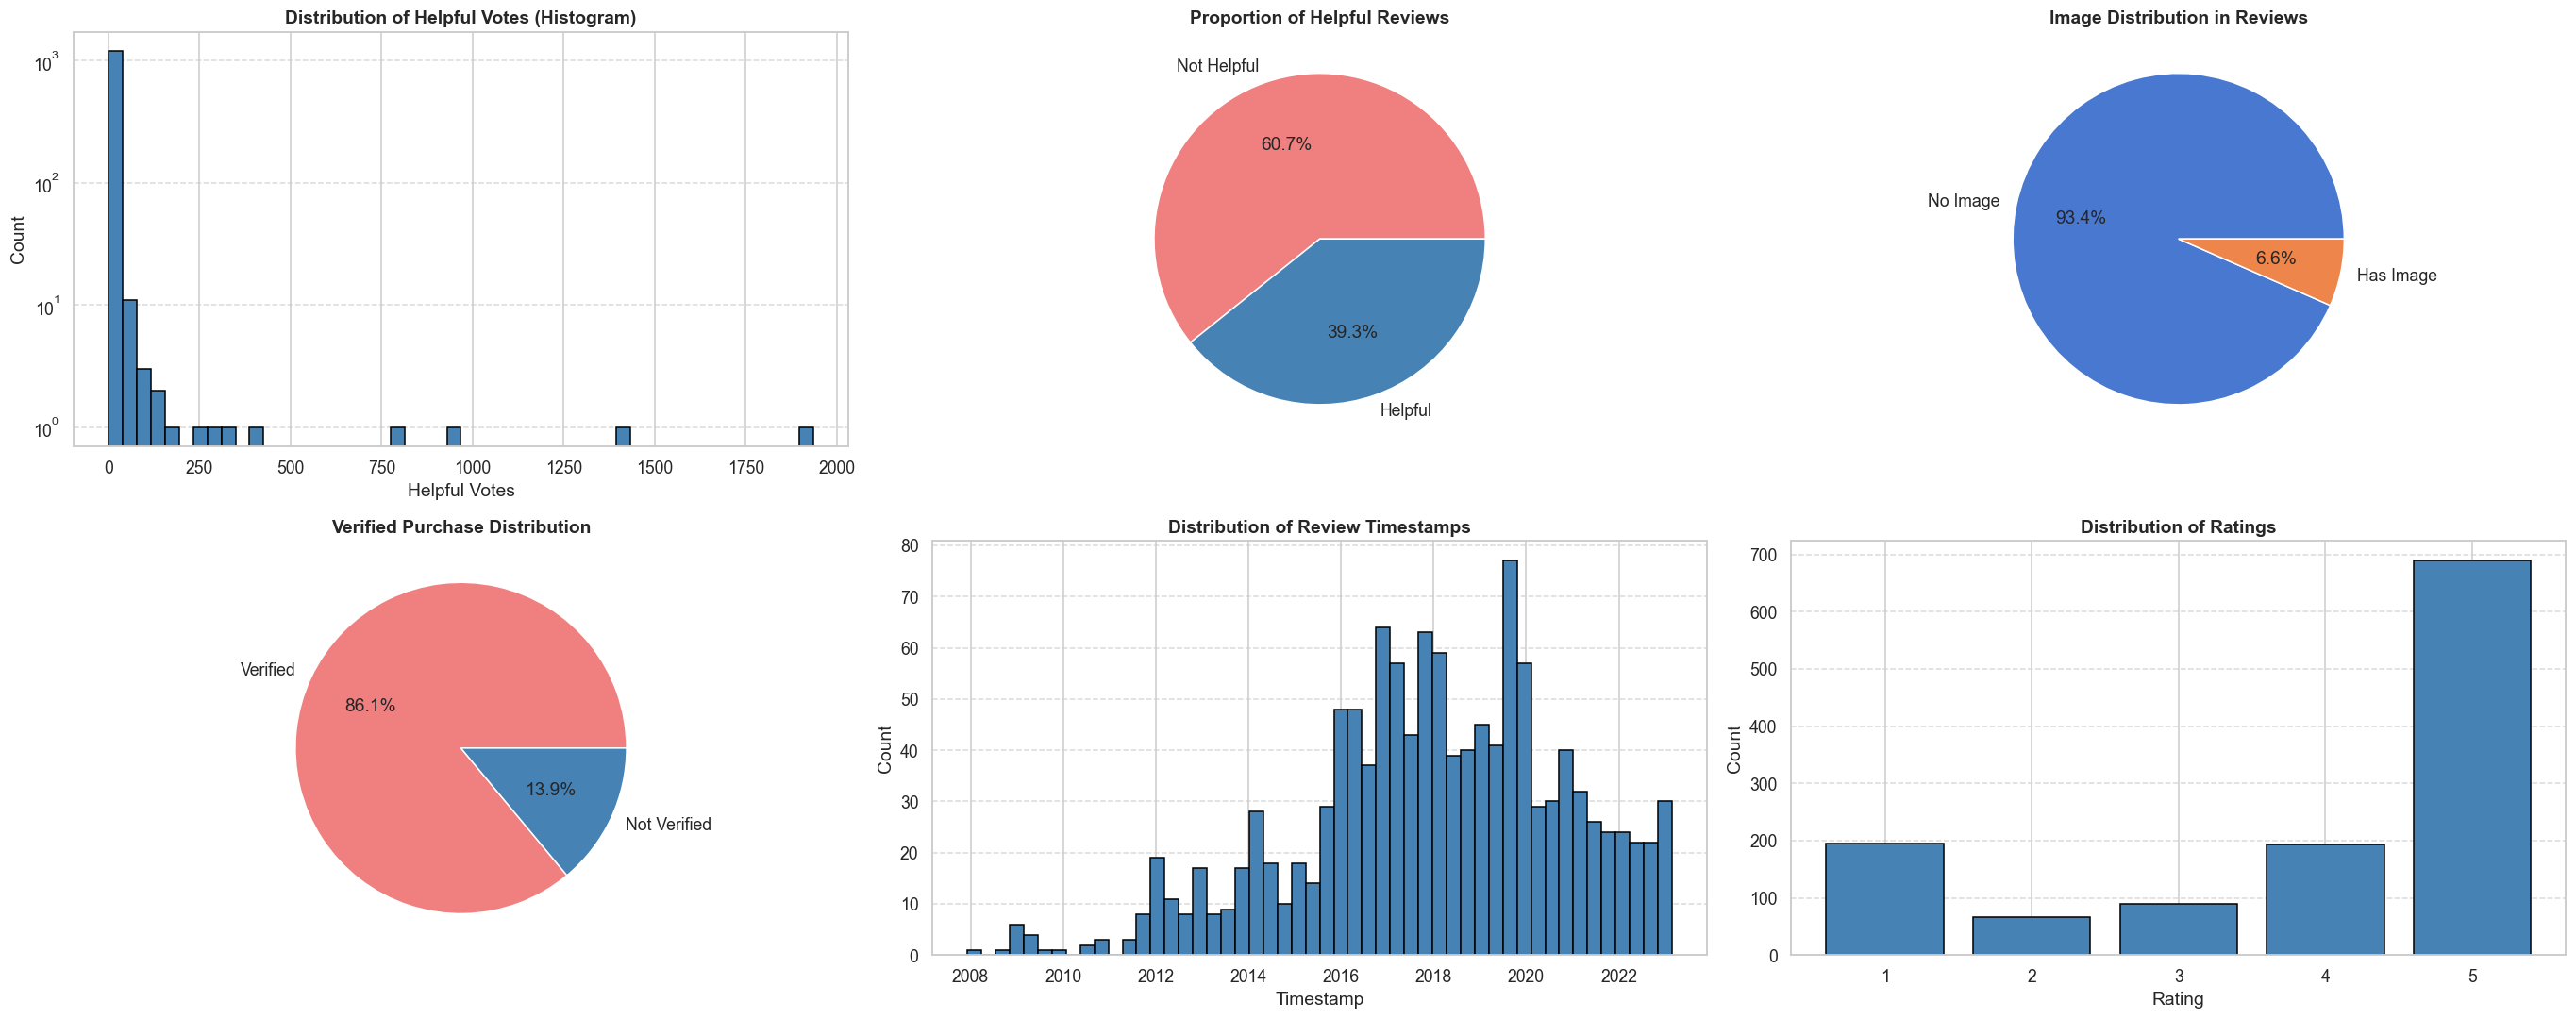


⭐ Rating Distribution:
  1.0:  15.8% █████
  2.0:   5.4% █
  3.0:   7.2% ██
  4.0:  15.7% █████
  5.0:  55.9% ██████████████████


<Figure size 704x528 with 0 Axes>

In [108]:
# Section 4: All Visualizations Combined into Subplots
fig, axes = plt.subplots(2, 3, figsize=(25, 10))
axes = axes.flatten()


# 1. Helpful Votes Histogram
axes[0].hist(df['helpful_vote'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Helpful Votes (Histogram)', fontweight='bold')
axes[0].set_xlabel('Helpful Votes')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Helpful Votes Pie Chart
is_helpful_review = df['is_helpful']
counts = is_helpful_review.value_counts(sort=False).sort_index()
axes[1].pie(counts, labels=['Not Helpful', 'Helpful'], autopct='%1.1f%%', 
            colors=['lightcoral', 'steelblue'])
axes[1].set_title('Proportion of Helpful Reviews', fontweight='bold')

# 3. Image Distribution
has_image = df['has_image'].value_counts()
axes[2].pie(has_image.values, 
            labels=['Has Image' if i else 'No Image' for i in has_image.index],
            autopct='%1.1f%%')
axes[2].set_title('Image Distribution in Reviews', fontweight='bold')

# 4. Verified Purchase Distribution
verified = df['is_verified'].value_counts()
axes[3].pie(verified.values, 
            labels=['Verified' if v else 'Not Verified' for v in verified.index],
            autopct='%1.1f%%', colors=['lightcoral', 'steelblue'])
axes[3].set_title('Verified Purchase Distribution', fontweight='bold')

# 5. Timestamp Distribution
axes[4].hist(df['timestamp'], bins=50, color='steelblue', edgecolor='black')
axes[4].set_title('Distribution of Review Timestamps', fontweight='bold')
axes[4].set_xlabel('Timestamp')
axes[4].set_ylabel('Count')
axes[4].grid(axis='y', linestyle='--', alpha=0.7)

# 6. Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[5].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[5].set_title('Distribution of Ratings', fontweight='bold')
axes[5].set_xlabel('Rating')
axes[5].set_ylabel('Count')
axes[5].set_xticks(rating_counts.index)
axes[5].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print statistics after the plot
print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

plt.tight_layout()
plt.show()

## 7.3 Statistical Analysis

In [109]:
NUMERIC_COLS = df.select_dtypes(include='number').columns

if 'helpful_vote' in NUMERIC_COLS:
    NUMERIC_COLS = NUMERIC_COLS.drop('helpful_vote')

print(f"Numeric features available for MI and VIF: {NUMERIC_COLS}")

Numeric features available for MI and VIF: Index(['rating', 'review_length', 'combined_text_length', 'title_length',
       'text_length', 'title_to_text_ratio', 'exclamation_mark',
       'question_mark', 'word_count', 'chars_per_word', 'is_long',
       'title_exists_only', 'image_count', 'has_image', 'day_of_week',
       'is_weekend', 'year', 'days_since_first_review', 'is_verified',
       'product_popularity', 'log_popularity', 'rating_extremity',
       'is_helpful'],
      dtype='str')


CORRELATION ANALYSIS


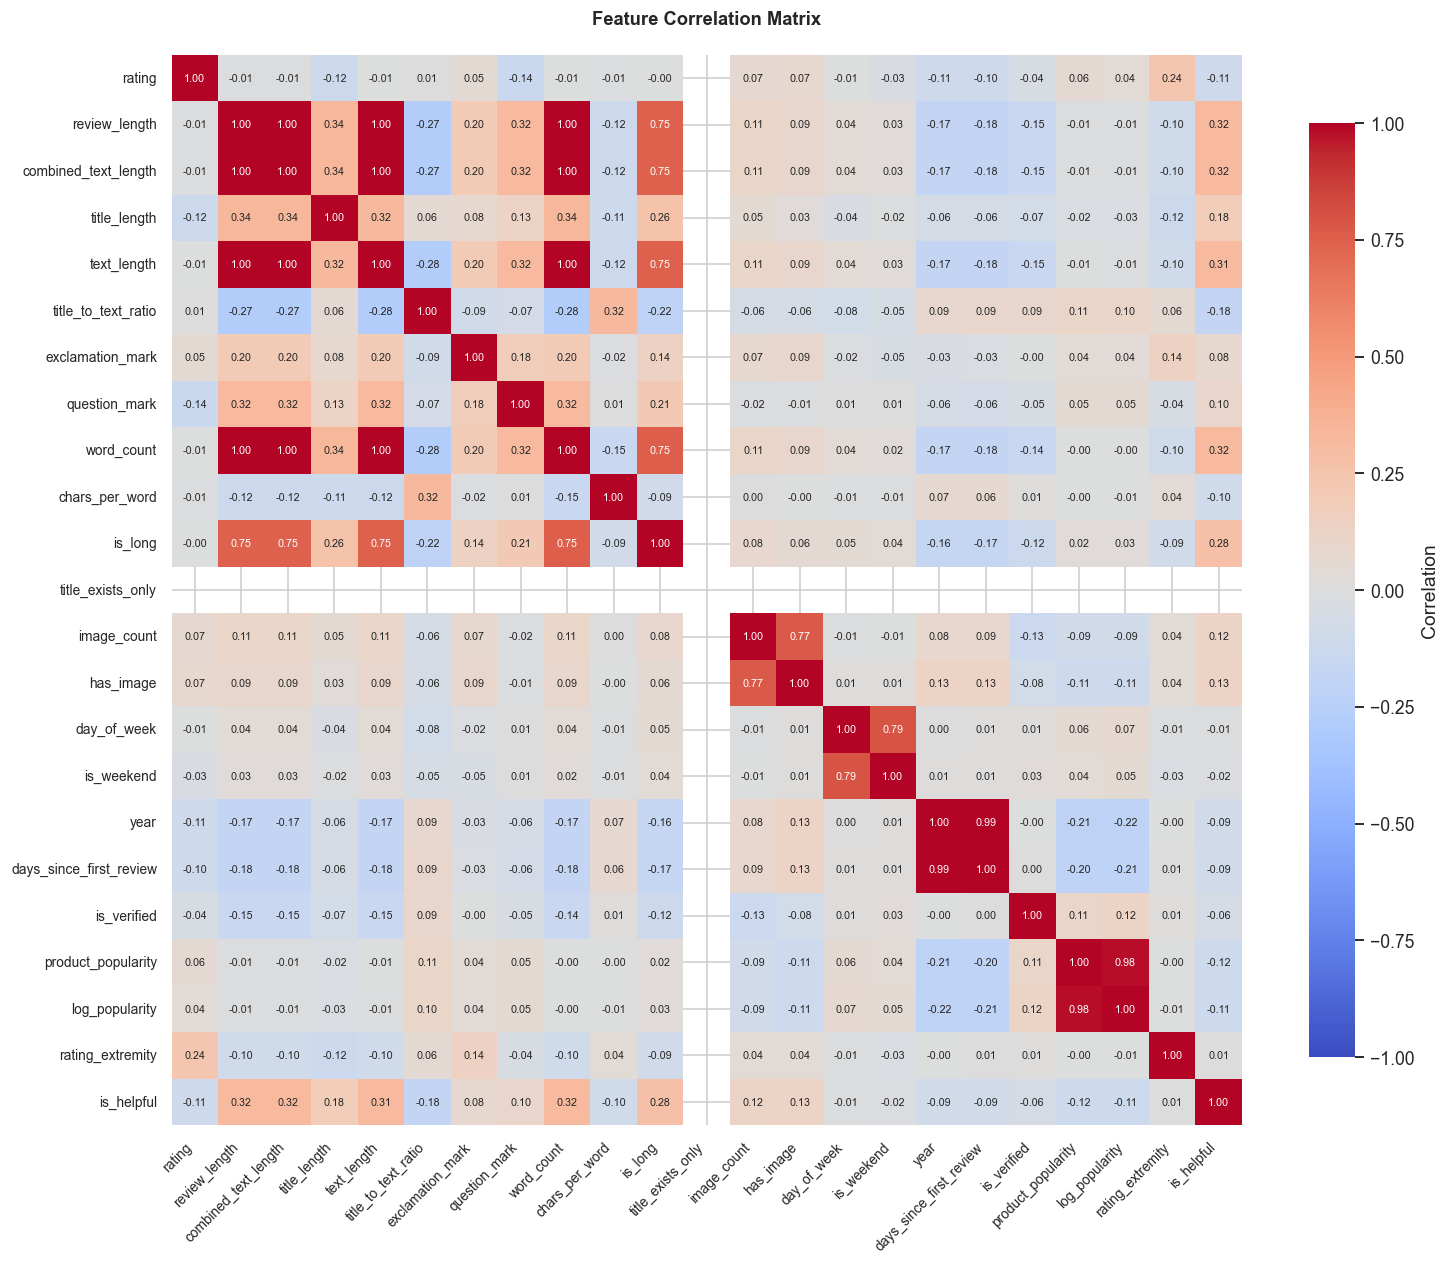


Key Correlations with Helpful Votes:
  word_count               :  0.3193
  review_length            :  0.3158
  combined_text_length     :  0.3158
  text_length              :  0.3140
  is_long                  :  0.2782
  title_length             :  0.1800
  has_image                :  0.1287
  image_count              :  0.1189
  question_mark            :  0.0990
  exclamation_mark         :  0.0777
  rating_extremity         :  0.0053
  day_of_week              : -0.0133
  is_weekend               : -0.0158
  is_verified              : -0.0598
  days_since_first_review  : -0.0932
  year                     : -0.0936
  chars_per_word           : -0.0965
  rating                   : -0.1074
  log_popularity           : -0.1136
  product_popularity       : -0.1156
  title_to_text_ratio      : -0.1755
  title_exists_only        :     nan


Helpful Votes by Rating:
        Count  Mean  Median
rating                     
1.0       195  0.51     1.0
2.0        67  0.46     0.0
3.0      

In [110]:
# CORRELATION ANALYSIS
print("CORRELATION ANALYSIS")
print("=" * 70)

# Numeric correlation matrix
corr_matrix = df[NUMERIC_COLS].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 7}, 
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

# Key insights
print("\nKey Correlations with Helpful Votes:")
helpful_corr = corr_matrix['is_helpful'].sort_values(ascending=False)
for col, val in helpful_corr.items():
    if col != 'is_helpful':
        print(f"  {col:25s}: {val:7.4f}")

# Helpful votes by rating
print(f"\n\nHelpful Votes by Rating:")
helpful_by_rating = df.groupby('rating')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_by_rating.columns = ['Count', 'Mean', 'Median']
print(helpful_by_rating.round(2))

# Helpful votes by verified purchase
print(f"\n\nHelpful Votes by Verified Purchase:")
helpful_verified = df.groupby('is_verified')['is_helpful'].agg(['count', 'mean', 'median'])
helpful_verified.index = ['Not Verified', 'Verified']
helpful_verified.columns = ['Count', 'Mean', 'Median']
print(helpful_verified.round(2))

In [111]:
# Subset + drop missing target
sub = df[NUMERIC_COLS].copy()
sub = sub.dropna(subset=['is_helpful'])
print("Number of records dropped due to missing target:", df.shape[0] - sub.shape[0])

sub_sample = sub.sample(
    n=min(500_000, len(sub)),
    random_state=42
)
print("Number of records used for MI and VIF calculations:", sub_sample.shape[0])

Number of records dropped due to missing target: 0
Number of records used for MI and VIF calculations: 1233


=== Statistical Evidence — All Numeric Features ===

                Feature  MI_Score  Spearman_r   VIF  Significant  High_VIF
            text_length    0.0954      0.3751   inf         True      True
             word_count    0.0915      0.3736 387.5         True      True
   combined_text_length    0.0693      0.3753   inf         True      True
          review_length    0.0659      0.3753   inf         True      True
         log_popularity    0.0362     -0.0903  23.8         True      True
                   year    0.0330     -0.0913  89.5         True      True
                is_long    0.0321      0.2782   2.4         True     False
         chars_per_word    0.0296     -0.0442   1.5        False     False
     product_popularity    0.0275     -0.0903  23.7         True      True
    title_to_text_ratio    0.0266     -0.2901   1.3         True     False
             is_weekend    0.0205     -0.0158   2.7        False     False
              has_image    0.0201      0.1287  

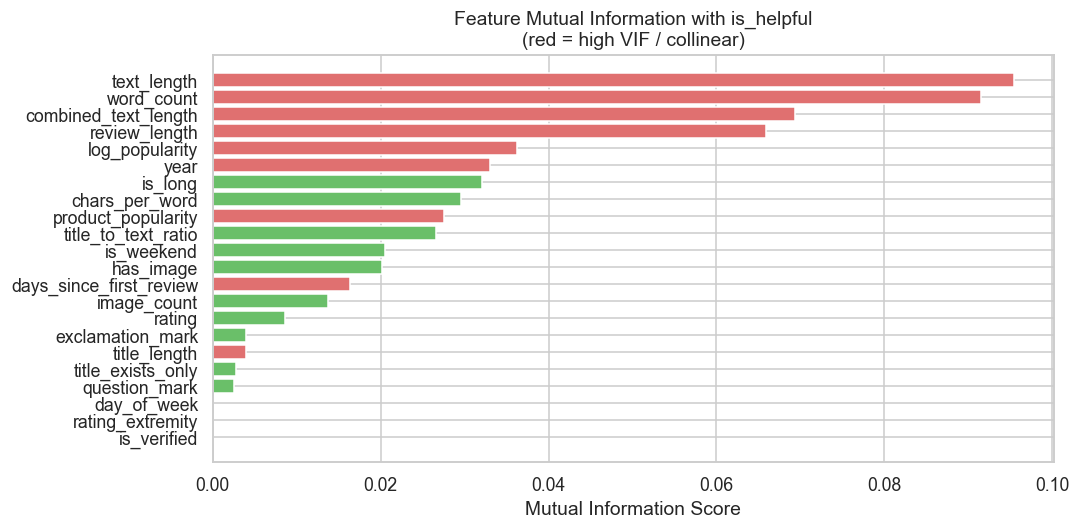

In [112]:
# Mutual Information (classification) — non-parametric, captures non-linear relationships
mi_scores = mutual_info_classif(
    sub_sample[NUMERIC_COLS.drop('is_helpful')],
    sub_sample['is_helpful'],
    random_state=42
)

# ── Spearman Correlation ──
sp_results = []
for feat in NUMERIC_COLS.drop('is_helpful'):
    r, p = stats.spearmanr(sub_sample[feat], sub_sample['is_helpful'])
    sp_results.append((feat, r, p))

# ── VIF (robust) ──
vif_sub = sub_sample[NUMERIC_COLS.drop('is_helpful')].copy()

# Drop zero-variance AFTER cleaning
vif_sub = vif_sub.loc[:, vif_sub.std() > 0]

# Final safety: ensure pure float matrix
vif_sub = vif_sub.astype(float)

vif_vals = [
    variance_inflation_factor(vif_sub.values, i)
    for i in range(vif_sub.shape[1])
]

vif_dict = dict(zip(vif_sub.columns, vif_vals))

# ── Assemble Evidence Table ──
evidence = pd.DataFrame({
    'Feature': NUMERIC_COLS.drop('is_helpful'),
    'MI_Score': mi_scores.round(4),
    'Spearman_r': [r for _, r, _ in sp_results],
    'Spearman_p': [p for _, _, p in sp_results],
    'VIF': [vif_dict.get(f, np.nan) for f in NUMERIC_COLS.drop('is_helpful')],
}).sort_values('MI_Score', ascending=False)

# Formatting
evidence['Spearman_r']  = evidence['Spearman_r'].round(4)
evidence['VIF']         = evidence['VIF'].round(1)
evidence['Significant'] = evidence['Spearman_p'] < 0.01
evidence['High_VIF']    = evidence['VIF'] > 10

print("=== Statistical Evidence — All Numeric Features ===\n")
print(
    evidence[['Feature', 'MI_Score', 'Spearman_r', 'VIF',
              'Significant', 'High_VIF']]
    .to_string(index=False)
)

# ── Plot MI Scores ──
fig, ax = plt.subplots(figsize=(10, 5))

sorted_ev = evidence.sort_values('MI_Score')

colors = [
    '#e07070' if v > 10 else '#6abf69'
    for v in sorted_ev['VIF']
]

ax.barh(
    sorted_ev['Feature'],
    sorted_ev['MI_Score'],
    color=colors,
    edgecolor='white'
)

ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Mutual Information with is_helpful\n(red = high VIF / collinear)')

plt.tight_layout()
plt.show()

## 7.4 Final Feature List

In [113]:
FINAL_FEATURES = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
    "images",
    "combined_text",
    "is_helpful", # target variable
    "helpful_vote", # for sentiment analysis
    "parent_asin", # for sentiment analysis
]

for feat in FINAL_FEATURES:
    if feat not in df.columns:
        print(f"Warning: {feat} not found in DataFrame — skipping.")
    else:
        print(f"✓ Retaining feature: {feat}")

df = df[FINAL_FEATURES].copy()

✓ Retaining feature: rating
✓ Retaining feature: review_length
✓ Retaining feature: chars_per_word
✓ Retaining feature: image_bucket
✓ Retaining feature: days_since_first_review
✓ Retaining feature: is_verified
✓ Retaining feature: log_popularity
✓ Retaining feature: rating_extremity
✓ Retaining feature: question_mark
✓ Retaining feature: exclamation_mark
✓ Retaining feature: title_length
✓ Retaining feature: title_to_text_ratio
✓ Retaining feature: images
✓ Retaining feature: combined_text
✓ Retaining feature: is_helpful
✓ Retaining feature: helpful_vote
✓ Retaining feature: parent_asin


Check if any value is empty

In [114]:
print("Shape of DataFrame:", df.shape)

missing = df.isnull().sum()

if missing.sum() == 0:
    print(" No missing detected!")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} missing values. ({count/len(df)*100:.1f}%)")

Shape of DataFrame: (1233, 17)
 No missing detected!


In [115]:
print("Dataset preview:")
df.head(2)

Dataset preview:


,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,images,combined_text,is_helpful,helpful_vote,parent_asin
70,5.0,93,5.5000,0 images,2916,1,1.945910,2.0,0,2,45,0.937500,[],Very nice! I love my new larger screen Kindle ...,1,2,B00VKIY9RG
226,1.0,76,5.8571,0 images,4948,1,2.079442,2.0,0,5,31,0.688889,[],NO GOOD! DONT WASTE YOUR MONEY! [SEP] Not good...,0,1,B09Q5BNT76


# 8. Clustering and Sampling

In [116]:
FEATURES_FOR_CLUSTERING = [
    "review_length", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "rating_extremity",
]

## 8.1 Change categorical to ordinal encoding

- 'image_bucket' feature is categorical --> converting to ordinal

In [117]:
if "image_bucket" in df.columns:
    # Print the current dtype and values to diagnose
    print(f"Current dtype of 'image_bucket': {df['image_bucket'].dtype}")
    print(f"Unique values: {df['image_bucket'].unique()}")
    
    # Define the mapping
    image_bucket_map = {
        '0 images': 0,
        '1 image': 1,
        '2 images': 2,
        '3+ images': 3
    }
    
    # Convert categorical to string first
    df['image_bucket'] = df['image_bucket'].astype(str).map(image_bucket_map)
    
    # Check for NaNs in all clustering features
    nan_counts = df[FEATURES_FOR_CLUSTERING].isna().sum()
    print(f"\nNaN counts in clustering features:\n{nan_counts}\n")
    
    print("    ✓ 'image_bucket' successfully mapped to numeric values for clustering.")
    print("    Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3")
    print(f"\nValue counts after mapping:\n{df['image_bucket'].value_counts().sort_index()}")
else:
    print("⚠️ 'image_bucket' column not found in dataset")

Current dtype of 'image_bucket': category
Unique values: ['0 images', '1 image', '3+ images', '2 images']
Categories (4, str): ['0 images' < '1 image' < '2 images' < '3+ images']

NaN counts in clustering features:
review_length              0
image_bucket               0
days_since_first_review    0
is_verified                0
rating_extremity           0
dtype: int64

    ✓ 'image_bucket' successfully mapped to numeric values for clustering.
    Mapping: '0 images'→0, '1 image'→1, '2 images'→2, '3+ images'→3

Value counts after mapping:
image_bucket
0    1152
1      36
2      19
3      26
Name: count, dtype: int64


## 8.2 Clustering

### Check if features considered for clustering are numeric

In [118]:
features = df.select_dtypes(include=[np.number]).columns.tolist()

for feat in FEATURES_FOR_CLUSTERING:
    if feat not in features:
        print(f"⚠️ Warning: Feature '{feat}' not found in dataset. Not a numeric feature, so it should be skipped in clustering.")
    else:
        print(f"✓ Feature '{feat}' is numeric and will be included in clustering.")

✓ Feature 'review_length' is numeric and will be included in clustering.
✓ Feature 'image_bucket' is numeric and will be included in clustering.
✓ Feature 'days_since_first_review' is numeric and will be included in clustering.
✓ Feature 'is_verified' is numeric and will be included in clustering.
✓ Feature 'rating_extremity' is numeric and will be included in clustering.


### KMeans for k=[2,5]

- We have checked the k range from '2 to 15'
- Clustering was performed on 100_000 records

In [119]:
features = FEATURES_FOR_CLUSTERING

df_kmeans = df[features].copy()
print("Dataframe for clustering:")
df_kmeans.head(2)

Dataframe for clustering:


,review_length,image_bucket,days_since_first_review,is_verified,rating_extremity
70,93,0,2916,1,2.0
226,76,0,4948,1,2.0


In [120]:
df_kmeans_scaled = StandardScaler().fit_transform(df_kmeans)
print("Data scaled for clustering.")

Data scaled for clustering.


In [121]:
inertia = []
sil_scores = []
k_range = range(2, 6)

for k in k_range:
    print(f"Running KMeans for k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(df_kmeans_scaled)
    inertia.append(kmeans.inertia_)

    sample_idx = np.random.choice(len(df_kmeans_scaled), len(df_kmeans_scaled), replace=False)
    df_kmeans_sample = df_kmeans_scaled[sample_idx]
    labels_sample = labels[sample_idx]

    sil_score = silhouette_score(df_kmeans_sample, labels_sample)
    sil_scores.append(sil_score)

    print(f"  Inertia for {k} clusters: {inertia[-1]:.2f}")
    print(f"  Silhouette Score for {k} clusters: {sil_score:.4f}")

Running KMeans for k=2...
  Inertia for 2 clusters: 5083.03
  Silhouette Score for 2 clusters: 0.3039
Running KMeans for k=3...
  Inertia for 3 clusters: 3946.64
  Silhouette Score for 3 clusters: 0.3660
Running KMeans for k=4...
  Inertia for 4 clusters: 2978.08
  Silhouette Score for 4 clusters: 0.4014
Running KMeans for k=5...
  Inertia for 5 clusters: 2453.21
  Silhouette Score for 5 clusters: 0.4212


Visualization of KMeans Clusters for different k values

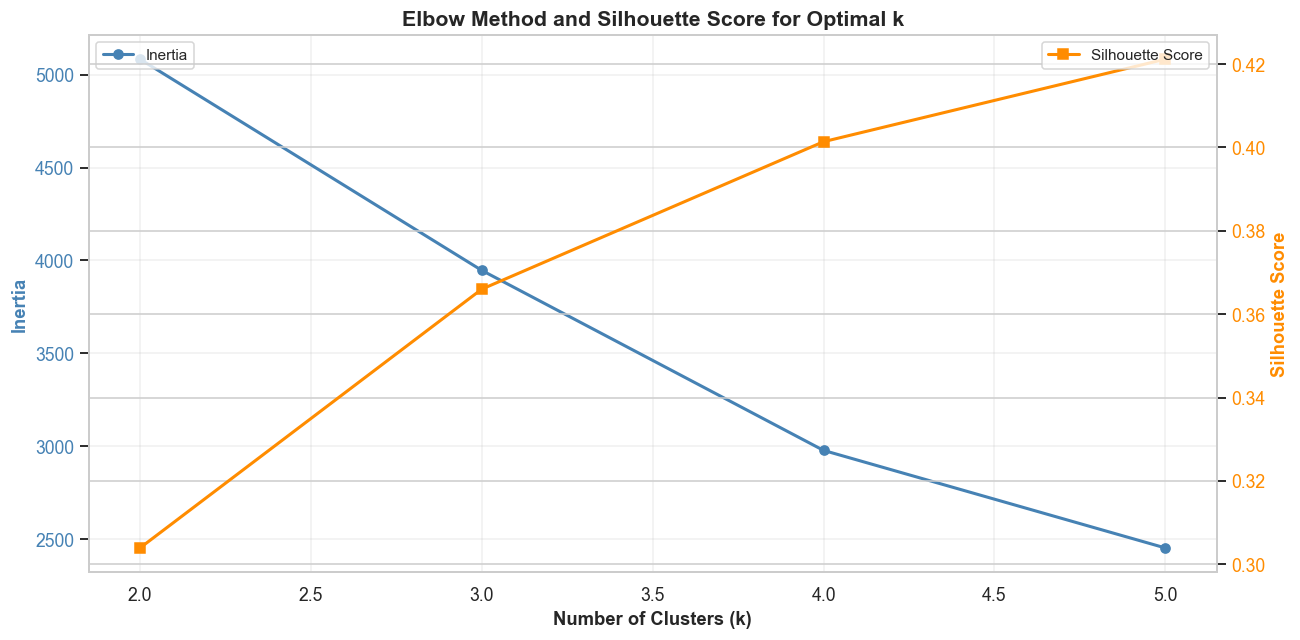

In [122]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Elbow Curve on left y-axis
ax1.plot(k_range, inertia, 'o-', color='steelblue', linewidth=2, markersize=6, label='Inertia')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia', color='steelblue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Create second y-axis for Silhouette Score using twinx()
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=6, label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='darkorange', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Title and legends
plt.title('Elbow Method and Silhouette Score for Optimal k', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

From the original KMeans graph:

- Highest Silhouette Score occurs at k = 3 (0.5157) → best cluster separation and cohesion.
- After k = 3, the silhouette score drops sharply at k = 4 (0.4142), indicating over-segmentation.
- Although inertia keeps decreasing (expected behavior), the quality of clustering worsens beyond k = 3.
- The slight elbow at k = 4 is weaker evidence compared to the clear silhouette optimum at k = 3.

### Form Clusters with k = 3

In [123]:
# num_clusters = int(input("Based on the Elbow and Silhouette analysis, enter the optimal number of clusters (k): "))
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=RANDOM_STATE)
df_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_kmeans_scaled)

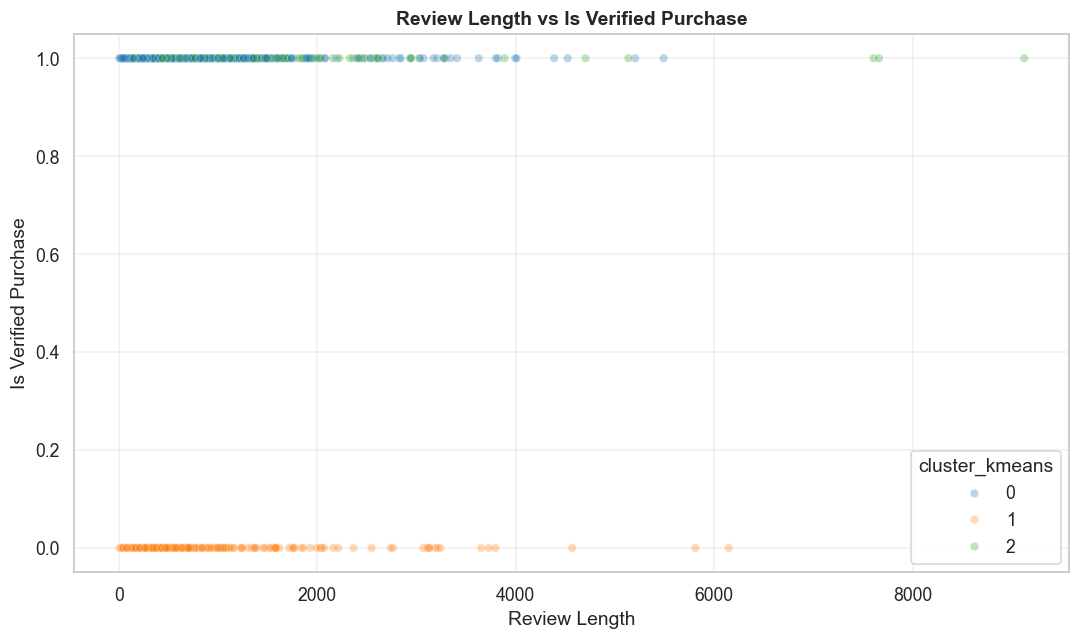

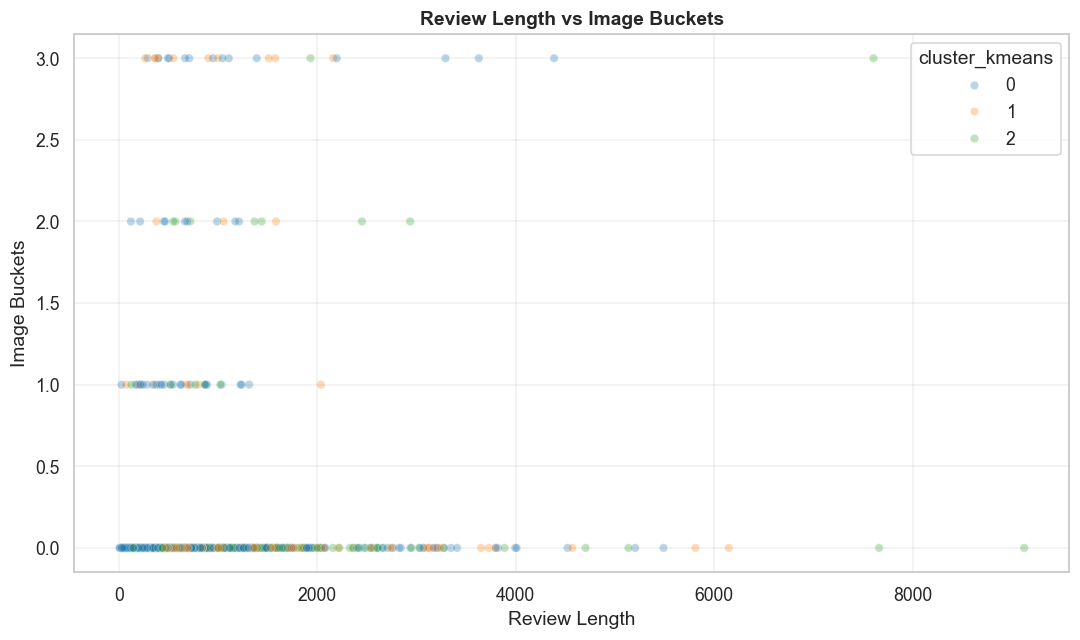

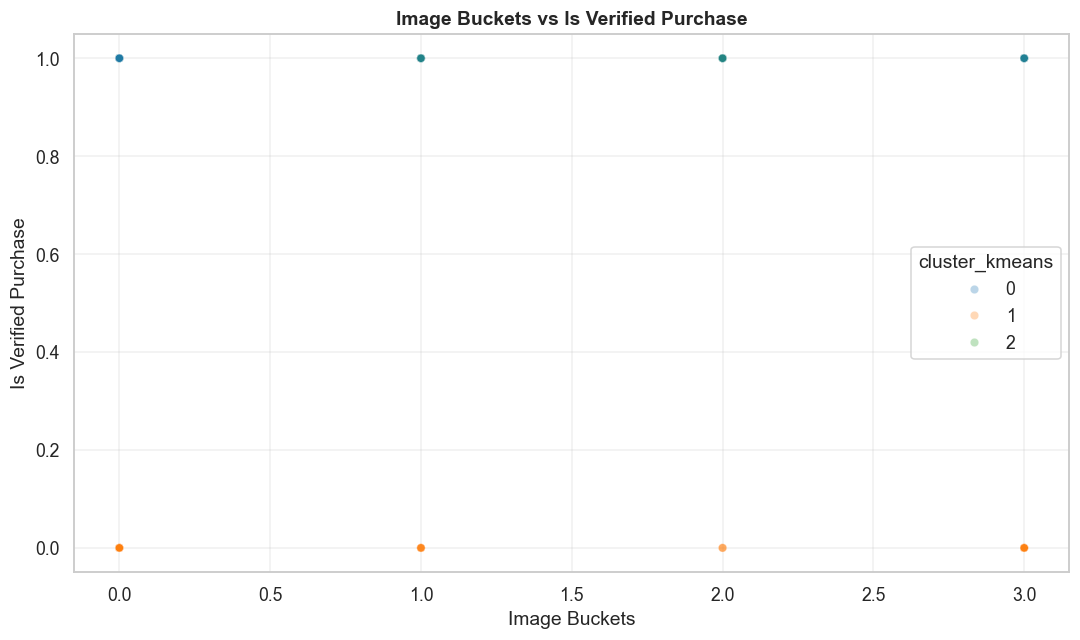

In [124]:
# Sample data for visualization (same as your pipeline)
# viz_df = df_kmeans.sample(n=100_000, random_state=RANDOM_STATE)
viz_df = df_kmeans.copy()

def scatter_clusters(df, feat_x, feat_y, title, x_label, y_label):
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=feat_x,
        y=feat_y,
        hue='cluster_kmeans',
        palette='tab10',
        alpha=0.3,
        s=30,
        legend='full'
    )

    plt.title(title, fontweight='bold')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


scatter_clusters(viz_df, 'review_length', 'is_verified',
                    title='Review Length vs Is Verified Purchase',
                    x_label='Review Length',
                    y_label='Is Verified Purchase')


scatter_clusters(viz_df, 'review_length', 'image_bucket',
                    title='Review Length vs Image Buckets',
                    x_label='Review Length',
                    y_label='Image Buckets')


scatter_clusters(viz_df, 'image_bucket', 'is_verified',
                    title='Image Buckets vs Is Verified Purchase',
                    x_label='Image Buckets',
                    y_label='Is Verified Purchase')

3D PCA Visualization of Clusters

Text(0.5, 0, 'PCA Component 3')

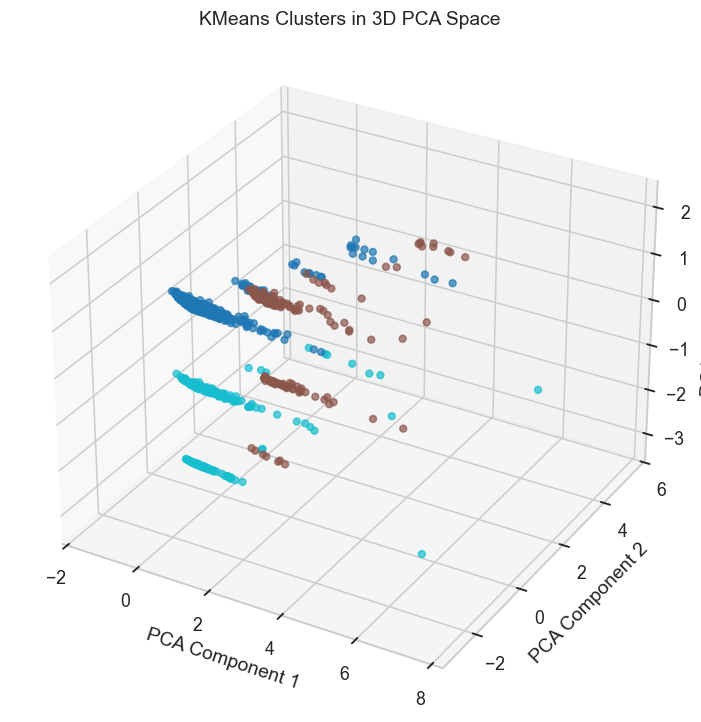

In [125]:
pca3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca3d.fit_transform(df_kmeans_scaled)


# 3D Scatter Plot of PCA Components colored by KMeans clusters
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c = df_kmeans['cluster_kmeans'],
    cmap = 'tab10',
    s = 20,
    alpha = 0.7
)

ax.set_title('KMeans Clusters in 3D PCA Space')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

Cluster Portfolio & Behavioural Profiles

In [126]:
# CLUSTER PORTFOLIO / PROFILE

# Number of samples per cluster
cluster_size = df_kmeans.groupby('cluster_kmeans').size().rename("count")

# Percentage share of each cluster
cluster_percentage = (
    df_kmeans['cluster_kmeans']
    .value_counts(normalize=True)
    .sort_index() * 100
).rename("percentage")

# Behavioural statistics per cluster
cluster_profile = df_kmeans.groupby('cluster_kmeans').agg({
    'review_length': ['mean', 'median'],
    'image_bucket': ['mean', 'median'],
    'days_since_first_review': ['mean', 'median'],
    'is_verified': 'mean',
    'rating_extremity': ['mean', 'median'],
})

# Combine everything
cluster_portfolio = pd.concat(
    [cluster_size, cluster_percentage, cluster_profile],
    axis=1
)

cluster_portfolio

,count,percentage,"(review_length, mean)","(review_length, median)","(image_bucket, mean)","(image_bucket, median)","(days_since_first_review, mean)","(days_since_first_review, median)","(is_verified, mean)","(rating_extremity, mean)","(rating_extremity, median)"
cluster_kmeans,,,,,,,,,,,
0,768,62.287105,583.695312,348.0,0.109375,0.0,3671.652344,3687.0,1.0,2.000000,2.0
1,172,13.949716,1030.104651,684.5,0.250000,0.0,3659.151163,4007.0,0.0,1.627907,2.0
2,293,23.763179,851.511945,537.0,0.085324,0.0,3652.215017,3549.0,1.0,0.723549,1.0


### Summary

| Cluster | Meaning | Sampling value |
| --- | --- | --- |
| 0 | Mainstream verified reviews | Majority baseline |
| 1 | Long-form unverified reviews | Distinct minority |
| 2 | Image-rich verified reviews | Smallest segment |

**Cluster 0** accounts for 85.1% of the data. These reviews are moderate in length, almost always verified, rarely include images, and show slightly higher rating extremity than cluster 1. This cluster represents the **typical review behavior** in the dataset.

**Cluster 1** makes up 10.8% of the data. It contains the longest reviews by far, is almost entirely unverified, uses few images, and has similar rating extremity to the other clusters. This cluster represents **lengthy, opinion-heavy reviews**.

**Cluster 2** accounts for 4.1% of the data. These reviews are relatively long, contain the most images by a large margin, and are mostly verified. This cluster represents **media-rich reviews**.

## 8.3 Sampling

Cluster-based sampling, rather than sampling on a single feature such as rating or `parent_asin`, preserves the multidimensional structure of review behavior. It captures how variables like rating, helpfulness, review length, and verification interact, instead of reducing representativeness to one column.

Unlike deterministic uniform sampling, our stratified random approach retains natural variation, including rare cases and noise within each cluster. This may slightly reduce training metrics, but it improves robustness and generalization to real-world consumer data.

**Reference:** Song, J. and Xu, J. (2024) ‘A clustering-based partially stratified sampling for high-dimensional structural reliability assessment’, *Computers and Structures*, 299, 107390. doi: 10.1016/j.compstruc.2024.107390.

In [127]:
df['cluster_kmeans'] = df_kmeans['cluster_kmeans']

In [128]:
sampled_df = (
    df
    .groupby('cluster_kmeans', as_index=False)
    .sample(frac=SAMPLED_FRACTION, random_state=RANDOM_STATE)
)

# Check the dtypes of the sampled dataframe
print(f"Dtypes in sampled dataframe: \n{sampled_df.dtypes}")
print(f"Sampled dataframe shape: {sampled_df.shape}")

Dtypes in sampled dataframe: 
rating                     float64
review_length                int32
chars_per_word             float64
image_bucket                 int64
days_since_first_review      int32
is_verified                   int8
log_popularity             float64
rating_extremity           float64
question_mark                int16
exclamation_mark             int16
title_length                 int16
title_to_text_ratio        float32
images                      object
combined_text                  str
is_helpful                    int8
helpful_vote                 int64
parent_asin                    str
cluster_kmeans               int32
dtype: object
Sampled dataframe shape: (123, 18)


The original DF and the sampled DF will have the same proportion of values from each clusters

In [129]:
print("Original size:", len(df))
print("Sampled size:", len(sampled_df))

print("\nOriginal cluster distribution:")
print(df['cluster_kmeans'].value_counts(normalize=True))

print("\nSampled cluster distribution:")
print(sampled_df['cluster_kmeans'].value_counts(normalize=True))

Original size: 1233
Sampled size: 123

Original cluster distribution:
cluster_kmeans
0    0.622871
2    0.237632
1    0.139497
Name: proportion, dtype: float64

Sampled cluster distribution:
cluster_kmeans
0    0.626016
2    0.235772
1    0.138211
Name: proportion, dtype: float64


# 9. Download the Images

- Required for Multimodal --> Text + Images + Metadata. In Section []

In [130]:
image_counts = (
    df["images"]
    .astype(str)
    .apply(lambda x: x != "[]" and x != "nan")
    .value_counts()
)
print(f"\n📸 Image Distribution:")
print(f"  Has Image: {image_counts.get(True, 0):,} reviews ({image_counts.get(True, 0)/len(df)*100:.1f}%)")
print(f"  No Image: {image_counts.get(False, 0):,} reviews ({image_counts.get(False, 0)/len(df)*100:.1f}%)")


📸 Image Distribution:
  Has Image: 81 reviews (6.6%)
  No Image: 1,152 reviews (93.4%)


## 9.1 Extract Image Outline/URL

In [131]:
def extract_first_image_url(images_column):

    if isinstance(images_column, np.ndarray):
        images_column = images_column.tolist()

    # Empty list
    if len(images_column) == 0:
        return None

    first = images_column[0]

    # Priority selection
    return (
        first.get("large_image_url")
        or first.get("medium_image_url")
        or first.get("small_image_url")
    )

df["image_url"] = df["images"].apply(extract_first_image_url)

print("Images available:", df["image_url"].notna().sum())

Images available: 81


## 9.2 Download Image

The timeout was kept as 10 seconds to get the image when the internet speed is slow. 
The speed of the internet is very slow for the last 10% of download, that is 1.83s/it.

In [132]:
# Many image URLs are broken or inaccessible, so we log and skip without raising an exception
# This was used in the original code, but commented here to avoid cluttering output

def download_image(url, save_path):
    try:
        response = requests.get(url, timeout=2)

        if response.status_code != 200:
            print(f"HTTP Error {response.status_code}: {url}")
            return False

        image = Image.open(BytesIO(response.content))
        image.verify()  # validate image

        with open(save_path, "wb") as f:
            f.write(response.content)

        return True

    except requests.exceptions.Timeout:
        print(f"Timeout: {url}")
        return False
    except requests.exceptions.ConnectionError:
        print(f"Connection Error: {url}")
        return False
    except Exception as e:
        print(f"Error: {type(e).__name__} - {url}")
        return False

#### Download Loop

This will keep track of all the images that are being downloaded successfully or have failed.

In [133]:
success = 0
failed = 0

for idx, row in tqdm(df.iterrows(), total=len(df)):

    url = row["image_url"]

    if pd.isna(url):
        continue

    filename = f"{idx}.jpg"
    save_path = os.path.join(IMAGE_DIR, filename)

    # Skip already downloaded images
    if os.path.exists(save_path):
        success += 1
        continue

    ok = download_image(url, save_path)

    if ok:
        success += 1
    else:
        failed += 1

print(f"\n\nDownloaded: {success}")
print(f"Failed: {failed}")

  4%|▎         | 46/1233 [00:00<00:07, 154.44it/s]

Error: FileNotFoundError - https://m.media-amazon.com/images/I/61pP-e01IpL._SL1600_.jpg


  5%|▌         | 62/1233 [00:00<00:12, 92.25it/s] 

Error: FileNotFoundError - https://images-na.ssl-images-amazon.com/images/I/71NPg9-I7xL.jpg
Error: FileNotFoundError - https://images-na.ssl-images-amazon.com/images/I/71ID0SaZhjL._SL1600_.jpg


  6%|▌         | 72/1233 [00:01<00:27, 42.70it/s]

...

Error: FileNotFoundError - https://images-na.ssl-images-amazon.com/images/I/71DIDeZj7wL._SL1600_.jpg


 98%|█████████▊| 1204/1233 [00:24<00:00, 72.12it/s]

Error: FileNotFoundError - https://images-na.ssl-images-amazon.com/images/I/71Wr5-ShBIL.jpg


100%|██████████| 1233/1233 [00:25<00:00, 49.13it/s]

Error: FileNotFoundError - https://m.media-amazon.com/images/I/71zAqT3NdoL._SL1600_.jpg


Downloaded: 0
Failed: 81


#### Save Image Mapping

This code maps each dataframe index to a local image file path, assigns the existing image location to a new `image_path` column, and displays sample rows to verify the mapping between image URLs, stored files, and image buckets.

In [134]:
# Ensure the folder exists
os.makedirs(IMAGE_DIR, exist_ok=True)

def get_path(i):   
    p = os.path.join(IMAGE_DIR, f"{i}.jpg")
    return p if os.path.exists(p) else None

df["image_path"] = df.index.map(get_path)

#### Drop Redundant Features

- images 
- image_url

In [135]:
drop_cols = ["images", "image_url"]
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print(f"Dataset shape: {df.shape[0]:2,} rows x {df.shape[1]} columns")

Dataset shape: 1,233 rows x 18 columns


# 10. Helpful Review Models

- Please include everything here (Include the Explainability)

## 10.1 Lithika's model - Explain why ML models are not proper as well!

> **Section 10.1 — 

# Helpful Amazon Review Prediction -- LSTM Pipeline

**Binary classification**: predict whether an Amazon review is helpful (`helpful` = 1).

Target logic used in this notebook:
- Prefer an existing binary label column when present (`is_helpful` or `helpful`).
- Otherwise, derive the label from vote-count columns (`helpful_vote`/`helpful_votes`) using a strict threshold (`> 1`).

## Notebook Structure

| # | Section | Purpose |
|---|---------|---------|
| 1 | Load Data | Read processed dataset (parquet/csv fallback) |
| 2 | Create Target | Resolve binary target from available label/vote columns |
| 3 | **EDA & Visualizations** | Correlation matrix, distributions, word clouds |
| 4 | **Improved Text Preprocessing** | HTML removal, stopwords, lemmatization |
| 5 | Train / Test Split | Stratified, before tokenization |
| 6 | Tokenization & Vocabulary | Built on train only |
| 7 | **GloVe Pretrained Embeddings** | 100-d vectors for known words |
| 8 | **Baseline Models (TF-IDF)** | Logistic Reg, Naive Bayes, Random Forest |
| 9 | PyTorch DataLoaders | Text + metadata tensors, scaling, batch setup |
| 10 | **Model Architectures** | Shared hyperparameters + 3 model definitions |
| 11 | Training Utilities | Weighted BCE, Adam, scheduler, clipping, early stopping |
| 12 | Train Vanilla LSTM | Baseline run + model-specific configuration |
| 13 | Train BiLSTM + GloVe | Text-only upgraded run + configuration |
| 14 | Train Hybrid BiLSTM | Text+metadata fusion run + configuration |
| 15 | **Comprehensive Evaluation** | Classification reports, confusion matrices |
| 16 | **ROC Curves** | All models on one plot |
| 17 | **Model Comparison** | Summary table + bar chart + training curves |
| 18 | **BERT Experiment** | Transformer-based approach (optional) |
| 19 | Explainability (LIME + SHAP) | Local and global interpretation |
| 20 | Conclusion & Key Findings | Summary of results |

**Key improvements over baseline notebook**:
- Pretrained GloVe embeddings
- Bidirectional LSTM (reads text forward + backward)
- Hybrid model fusing text + metadata features
- Class-weight handling for imbalance
- Baseline comparisons (LR / NB / RF) for context
- Rich visualisations (correlation heatmap, word clouds, ROC curves)


In [136]:
import sys, subprocess

packages = [
    "pip", "setuptools", "wheel",
    "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn",
    "torch", "nltk", "wordcloud",
]
print("Installing / upgrading dependencies ...")
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages]
)

import nltk
for res in ["stopwords", "wordnet", "punkt_tab"]:
    nltk.download(res, quiet=True)
print("Done.")

Installing / upgrading dependencies ...
Done.


In [137]:
import ast
from pathlib import Path
from collections import Counter
import re, html, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


PyTorch: 2.11.0+cu128 | device: cuda


### Modelling data scale (read before Section 10.1)

**Full processed dataset (high row count)**  
The file `data/processed/s03_filter.parquet` is the processed, cluster-sampled Amazon Electronics reviews table used for group-level modelling (the presentation's documented methodology: 8.47M product-filtered rows -> 3% KMeans-stratified sample -> re-applying the >=5-reviews-per-product filter on the sample itself). It contains 99,627 rows. An 80/20 stratified train-test split then yields roughly **79,700** train and **19,900** test examples.

**What this notebook often uses instead**  
Earlier sections may build `df` from a **streamed** slice (for example `SAMPLE_SIZE = 100_000` from the Hugging Face JSONL), then apply filters and feature engineering. The streamed slice is **not** the same draw or ordering as the full parquet. Section **10.1** then sets `df_lstm` from **`df`** when it exists, otherwise from **`sampled_df`** (Section 8.3 cluster-stratified sample, often a **small fraction** of rows). In a representative run, `df_lstm` can sit on the order of **~1k-2k** rows, i.e. far smaller than the parquet.

**Why metrics and model rankings change**  
Small `df_lstm` means **noisier** accuracy, F1, and AUC, a **different** tokenizer vocabulary fit on train text, and fewer effective training examples for neural models. You should not expect numeric parity with a full-parquet run until the **row count, label definition, and feature columns** match.

**How to align Section 10.1 with full-scale behaviour**

1. **Point the LSTM inputs at the large table**  
   Load `data/processed/s03_filter.parquet` with `pd.read_parquet(...)` and assign to `df` or `df_lstm` before Section 10.1, after ensuring text, label, and metadata columns line up with what the cells below expect (or merge parquet fields into your engineered frame).

2. **Use one clear binary target**  
   Prefer `is_helpful` from the parquet if present, or keep the **same** vote-threshold rule you use elsewhere in this notebook. Changing the definition shifts all metrics.

3. **Use a stratified split at scale**  
   For example `train_test_split(..., test_size=0.2, stratify=y, random_state=42)` (use the seed you report in your write-up). Mirror any inner train/validation split used for early stopping.

4. **Match the training recipe**  
   Align `MAX_VOCAB`, `MAX_LEN`, batch size (many setups use on the order of 256), epochs, early stopping, and the hybrid model's **metadata column list** with what you describe in your methodology.

5. **Do not train deep models only on `sampled_df` unless that is intentional**  
   The Section 8.3 sample is useful for clustering and EDA; it is usually **too small** to stand in for the full dataset in LSTM training. For large-N behaviour, build `df_lstm` from the full engineered `df` or directly from the parquet. If you must subsample, use `df.sample(n, random_state=...)` on the large table rather than relying on the **first** N streamed rows, which can bias genre and time.

*Note:* Even with identical data settings, small run-to-run differences can remain because of library versions, hardware, and nondeterministic GPU operations in PyTorch.


### 10.1.1 Load Data

Uses **`df`** from this notebook when available (engineered frame after Sections 3–7), otherwise **`sampled_df`** from Section 8.3.

In [138]:
# Modelling frame from this notebook (default: engineered `df`, not the full parquet):
# - Prefer `df`: engineered reviews from Sections 3–7 (e.g. streamed SAMPLE_SIZE / 100k then filtered).
# - Else `sampled_df`: only if you ran Section 8.3 clustering + stratified sampling.
_g = globals()
if "df" in _g and _g["df"] is not None:
    _src = _g["df"]
    _src_name = "df (main engineered frame)"
elif "sampled_df" in _g and _g["sampled_df"] is not None:
    _src = _g["sampled_df"]
    _src_name = "sampled_df (Section 8.3 cluster-stratified sample)"
else:
    raise NameError(
        "Neither `df` nor `sampled_df` is defined. Run Sections 3–7 to build `df`, "
        "or Section 8.3 for `sampled_df`, before this cell."
    )

df_lstm = _src.reset_index(drop=True).copy()
print(f"df_lstm from {_src_name!r}, shape={df_lstm.shape}")

# Column aliases expected by the Section 10.1 pipeline below
if "title" not in df_lstm.columns and "title_text" in df_lstm.columns:
    df_lstm["title"] = df_lstm["title_text"]

if "is_verified" not in df_lstm.columns and "verified_purchase" in df_lstm.columns:
    df_lstm["is_verified"] = (
        pd.to_numeric(df_lstm["verified_purchase"], errors="coerce").fillna(0).astype(int)
    )

# Target column name used in Section 10.1 (`helpful`)
if "helpful" not in df_lstm.columns:
    if "is_helpful" in df_lstm.columns:
        df_lstm["helpful"] = (
            pd.to_numeric(df_lstm["is_helpful"], errors="coerce").fillna(0).astype(int)
        )
    else:
        vote_col = next(
            (c for c in ("helpful_vote", "helpful_votes") if c in df_lstm.columns),
            None,
        )
        if vote_col is None:
            raise KeyError(
                "Need `is_helpful`, `helpful`, or helpful_vote on the modelling frame."
            )
        hv = pd.to_numeric(df_lstm[vote_col], errors="coerce").fillna(0)
        df_lstm["helpful"] = (hv > 1).astype(int)

print("Shape:", df_lstm.shape)
print("Target:\n", df_lstm["helpful"].value_counts())
df_lstm.head(3)


df_lstm from 'df (main engineered frame)', shape=(1233, 18)
Shape: (1233, 19)
Target:
 helpful
0    749
1    484
Name: count, dtype: int64


,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio,combined_text,is_helpful,helpful_vote,parent_asin,cluster_kmeans,image_path,helpful
0,5.0,93,5.5000,0,2916,1,1.945910,2.0,0,2,45,0.937500,Very nice! I love my new larger screen Kindle ...,1,2,B00VKIY9RG,0,None,1
1,1.0,76,5.8571,0,4948,1,2.079442,2.0,0,5,31,0.688889,NO GOOD! DONT WASTE YOUR MONEY! [SEP] Not good...,0,1,B09Q5BNT76,0,None,0
2,5.0,311,5.5614,0,3673,1,2.197225,2.0,0,0,16,0.054237,Better than ever [SEP] Wow - we like the gray ...,0,1,B07456BG8N,0,None,0


### 10.1.2 Create Target & Verify Label Distribution

Target construction follows a robust fallback order:

1. If an existing binary label column is available (`is_helpful` or `helpful`), use it directly.
2. Otherwise, use a vote-count column (`helpful_vote`/`helpful_votes`) and apply:
   - `helpful = 1 if helpful_vote > 1 else 0`

This keeps the notebook compatible with multiple processed dataset variants while preserving a strict threshold when raw vote counts are used.

In [139]:
# Verify / build `helpful` (skipped if already set on `df_lstm`)
threshold = 1

if "helpful" in df_lstm.columns:
    print("Using existing `helpful` column from upstream pipeline.")
else:
    candidate_cols = [
        "helpful_vote",
        "helpful_votes",
        "is_helpful",
        "helpful",
        "vote",
        "votes",
    ]
    vote_col = next((c for c in candidate_cols if c in df_lstm.columns), None)
    if vote_col is None:
        raise KeyError(
            "No helpful-vote/label column found. Tried: "
            f"{candidate_cols}. Available columns: {list(df_lstm.columns)}"
        )

    helpful_raw = pd.to_numeric(df_lstm[vote_col], errors="coerce").fillna(0)
    print(f"Using target source column: {vote_col}")

    uniq = set(helpful_raw.astype(int).unique())
    if uniq.issubset({0, 1}):
        print(f"{vote_col} appears binary; using it directly as target.")
        df_lstm["helpful"] = helpful_raw.astype(int)
    else:
        print(f"{vote_col}  min={helpful_raw.min()}  threshold={threshold}  max={helpful_raw.max()}")
        print(f"Using strict threshold: helpful = 1 if {vote_col} > {threshold}")
        df_lstm["helpful"] = (helpful_raw > threshold).astype(int)

print("\n" + "=" * 40)
print("LABEL DISTRIBUTION")
print("=" * 40)
print(df_lstm["helpful"].value_counts())
print()
print(df_lstm["helpful"].value_counts(normalize=True))
print("=" * 40)

if df_lstm["helpful"].nunique() < 2:
    raise ValueError("Only one class present -- model cannot learn.")

minority_frac = df_lstm["helpful"].value_counts(normalize=True).min()
print(f"\nMinority class fraction: {minority_frac:.4f}")
if minority_frac < 0.1:
    print("WARNING: Highly imbalanced dataset (minority < 10%).")


Using existing `helpful` column from upstream pipeline.

LABEL DISTRIBUTION
helpful
0    749
1    484
Name: count, dtype: int64

helpful
0    0.607461
1    0.392539
Name: proportion, dtype: float64

Minority class fraction: 0.3925


### 10.1.3 Exploratory Data Analysis & Visualizations

Before modelling, we explore feature distributions, inter-feature correlations, and word-level patterns to understand what distinguishes helpful reviews from unhelpful ones.

In [140]:
print("Dataset Overview")
print("=" * 60)
print(f"Shape: {df_lstm.shape}")
print(f"Missing values:\n{df_lstm.isnull().sum()}")
print()
df_lstm.describe().T


Dataset Overview
Shape: (1233, 19)
Missing values:
rating                        0
review_length                 0
chars_per_word                0
image_bucket                  0
days_since_first_review       0
is_verified                   0
log_popularity                0
rating_extremity              0
question_mark                 0
exclamation_mark              0
title_length                  0
title_to_text_ratio           0
combined_text                 0
is_helpful                    0
helpful_vote                  0
parent_asin                   0
cluster_kmeans                0
image_path                 1233
helpful                       0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
rating,1233.0,3.903487,1.504731,1.000000,3.000000,5.000000,5.000000,5.000000
review_length,1233.0,709.609895,871.024939,7.000000,197.000000,438.000000,882.000000,9123.000000
chars_per_word,1233.0,5.560864,0.601947,4.394400,5.235300,5.456100,5.725800,11.500000
image_bucket,1233.0,0.123277,0.515398,0.000000,0.000000,0.000000,0.000000,3.000000
days_since_first_review,1233.0,3665.289538,1045.481831,0.000000,3066.000000,3682.000000,4381.000000,5557.000000
is_verified,1233.0,0.860503,0.346605,0.000000,1.000000,1.000000,1.000000,1.000000
log_popularity,1233.0,2.291416,0.594258,1.791759,1.791759,1.945910,2.484907,3.610918
rating_extremity,1233.0,1.644769,0.611317,0.000000,1.000000,2.000000,2.000000,2.000000
question_mark,1233.0,0.168694,0.811300,0.000000,0.000000,0.000000,0.000000,18.000000
exclamation_mark,1233.0,1.020276,2.333844,0.000000,0.000000,0.000000,1.000000,31.000000


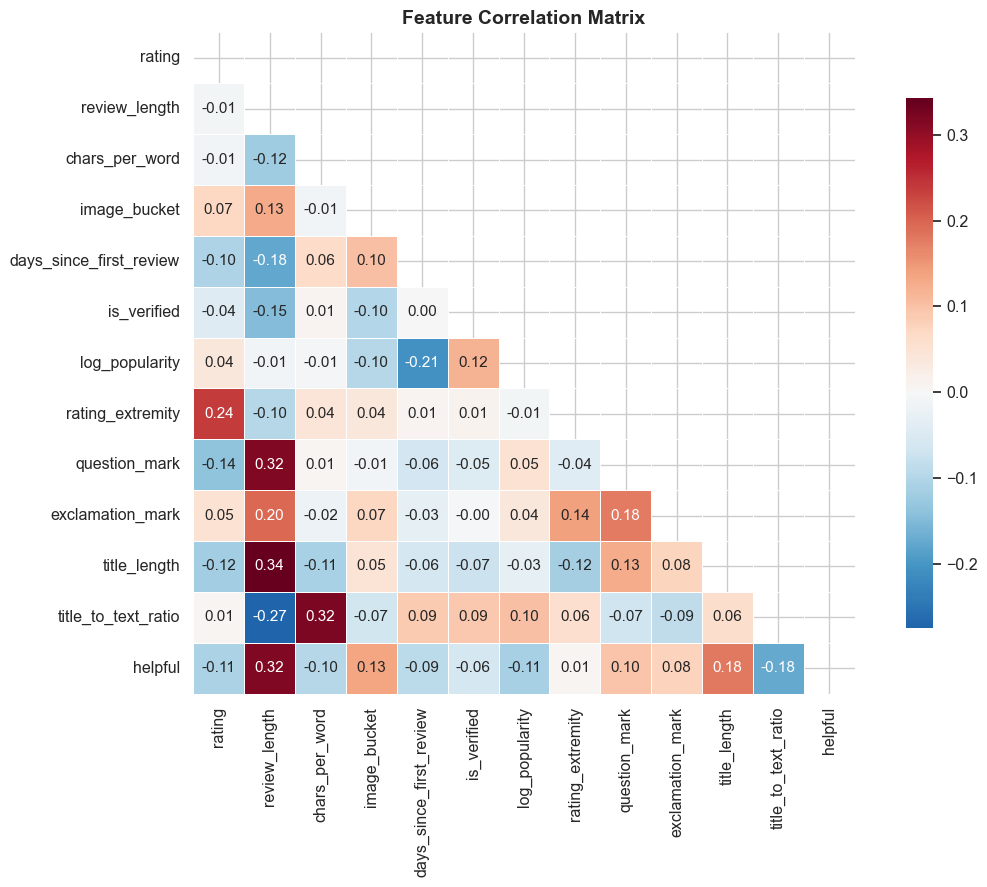


Correlation with target (helpful):
              review_length: +0.3158  +++++++++++++++
               title_length: +0.1800  ++++++++
               image_bucket: +0.1333  ++++++
              question_mark: +0.0990  ++++
           exclamation_mark: +0.0777  +++
           rating_extremity: +0.0053  
                is_verified: -0.0598  ++
    days_since_first_review: -0.0932  ++++
             chars_per_word: -0.0965  ++++
                     rating: -0.1074  +++++
             log_popularity: -0.1136  +++++
        title_to_text_ratio: -0.1755  ++++++++


In [141]:
preferred_cols = [
    "rating",
    "review_length",
    "char_per_word",
    "chars_per_word",  # compatibility with precomputed parquet variant
    "image_bucket",
    "image_count",  # main pipeline (raw `images` often dropped later)
    "days_since_first_review",
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
    "images",
    "helpful",
]

numeric_cols = [
    c for c in preferred_cols
    if c in df_lstm.columns and pd.api.types.is_numeric_dtype(df_lstm[c])
]
if "helpful" not in numeric_cols:
    raise KeyError("'helpful' target column missing; run target creation cell first.")

corr = df_lstm[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelation with target (helpful):")
target_corr = corr["helpful"].drop("helpful").sort_values(ascending=False)
for feat, val in target_corr.items():
    if pd.isna(val):
        print(f"  {feat:>25s}: NaN     (constant or insufficient variance)")
        continue
    bar = "+" * int(abs(val) * 50)
    print(f"  {feat:>25s}: {val:+.4f}  {bar}")


KeyError: 'images'

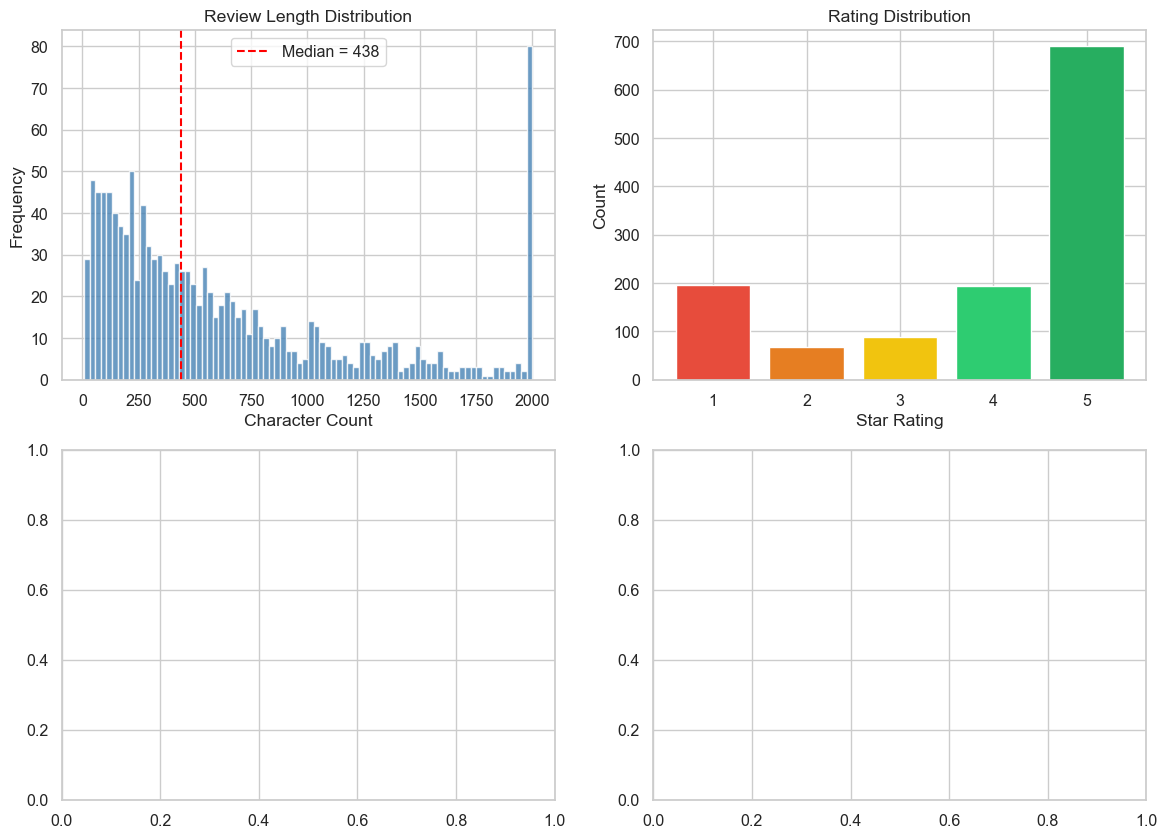

In [142]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_lstm["review_length"].clip(upper=2000), bins=80,
                color="steelblue", edgecolor="white", alpha=0.8)
axes[0, 0].axvline(df_lstm["review_length"].median(), color="red", linestyle="--",
                    label=f'Median = {df_lstm["review_length"].median():.0f}')
axes[0, 0].set_title("Review Length Distribution")
axes[0, 0].set_xlabel("Character Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

rating_counts = df_lstm["rating"].value_counts().sort_index()
colors_r = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
axes[0, 1].bar(rating_counts.index, rating_counts.values,
               color=colors_r, edgecolor="white")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Star Rating")
axes[0, 1].set_ylabel("Count")

# Main notebook often drops raw `images`; use image_count / image_bucket when needed.
if "image_count" in df_lstm.columns:
    _img_hist = pd.to_numeric(df_lstm["image_count"], errors="coerce").fillna(0).clip(upper=5)
    _img_hist_title = "image_count (clipped at 5)"
    _img_hist_xlabel = "Image count"
elif "images" in df_lstm.columns and pd.api.types.is_numeric_dtype(df_lstm["images"]):
    _img_hist = pd.to_numeric(df_lstm["images"], errors="coerce").fillna(0).clip(upper=5)
    _img_hist_title = "images (numeric, clipped at 5)"
    _img_hist_xlabel = "Number of images"
elif "image_bucket" in df_lstm.columns:
    _img_hist = pd.to_numeric(df_lstm["image_bucket"], errors="coerce").fillna(0)
    _img_hist_title = "image_bucket"
    _img_hist_xlabel = "Bucket (ordinal)"
else:
    _img_hist = None

if _img_hist is not None:
    axes[1, 0].hist(_img_hist, bins=np.arange(-0.5, 6.5, 1),
                    color="seagreen", edgecolor="white", alpha=0.8)
    axes[1, 0].set_title(_img_hist_title)
    axes[1, 0].set_xlabel(_img_hist_xlabel)
    axes[1, 0].set_ylabel("Frequency")
else:
    axes[1, 0].text(
        0.5, 0.5, "No image_count / numeric images / image_bucket",
        ha="center", va="center", transform=axes[1, 0].transAxes,
    )
    axes[1, 0].set_title("Image features (not in dataframe)")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

label_counts = df_lstm["helpful"].value_counts().sort_index()
axes[1, 1].bar(["Not Helpful (0)", "Helpful (1)"], label_counts.values,
               color=["#3498db", "#e74c3c"], edgecolor="white")
axes[1, 1].set_title("Target Label Distribution")
axes[1, 1].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[1, 1].text(i, v + max(1, int(0.005 * label_counts.max())), f"{v:,}", ha="center", fontweight="bold")

plt.suptitle("Data Distributions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


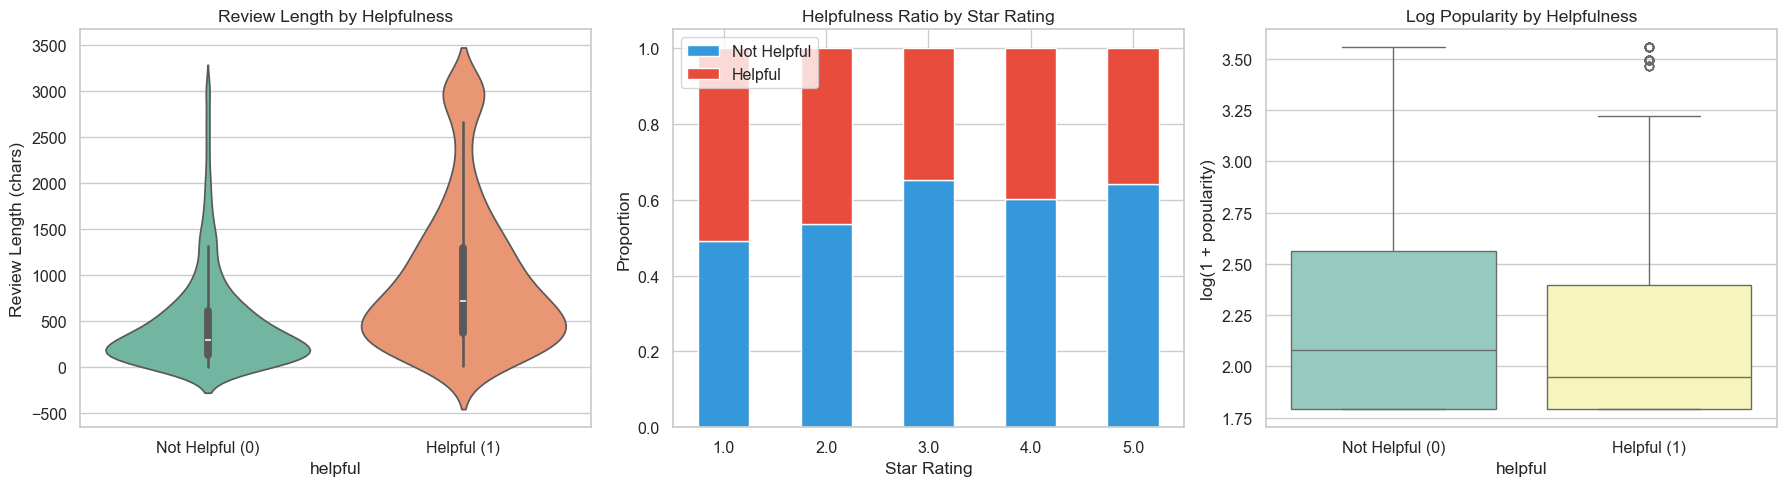

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=df_lstm, x="helpful",
               y=df_lstm["review_length"].clip(upper=3000),
               ax=axes[0], palette="Set2", inner="box")
axes[0].set_title("Review Length by Helpfulness")
axes[0].set_xticklabels(["Not Helpful (0)", "Helpful (1)"])
axes[0].set_ylabel("Review Length (chars)")

helpful_rating = df_lstm.groupby(["rating", "helpful"]).size().unstack(fill_value=0)
helpful_rating_pct = helpful_rating.div(helpful_rating.sum(axis=1), axis=0)
helpful_rating_pct.plot(kind="bar", stacked=True, ax=axes[1],
                        color=["#3498db", "#e74c3c"], edgecolor="white")
axes[1].set_title("Helpfulness Ratio by Star Rating")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Proportion")
axes[1].legend(["Not Helpful", "Helpful"], loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

cap = df_lstm["log_popularity"].quantile(0.95)
sns.boxplot(data=df_lstm, x="helpful",
            y=df_lstm["log_popularity"].clip(upper=cap),
            ax=axes[2], palette="Set3")
axes[2].set_title("Log Popularity by Helpfulness")
axes[2].set_xticklabels(["Not Helpful (0)", "Helpful (1)"])
axes[2].set_ylabel("log(1 + popularity)")

plt.tight_layout()
plt.show()


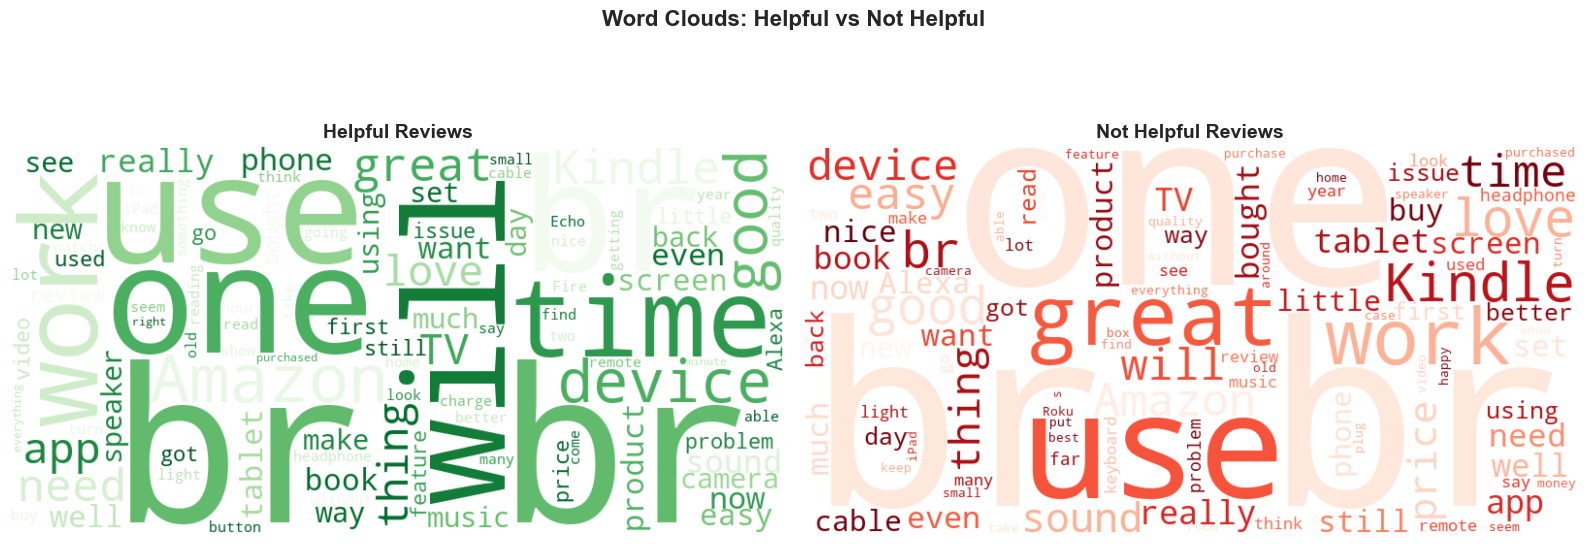

In [144]:
text_col = "clean_text" if "clean_text" in df_lstm.columns else "combined_text"

def build_wc_corpus(mask, text_column, sample_size=5000):
    n = int(mask.sum())
    if n == 0:
        return ""
    sampled = df_lstm.loc[mask, text_column].sample(min(sample_size, n), random_state=SEED)
    sampled = sampled.fillna("").astype(str)
    sampled = sampled.str.replace("[SEP]", " ", regex=False).str.strip()
    sampled = sampled[sampled.str.len() > 0]
    return " ".join(sampled.tolist())

helpful_corpus = build_wc_corpus(df_lstm["helpful"] == 1, text_col)
not_helpful_corpus = build_wc_corpus(df_lstm["helpful"] == 0, text_col)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def draw_wordcloud_or_placeholder(ax, corpus, title, cmap):
    if corpus.strip():
        wc = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap=cmap,
            max_words=100,
            random_state=SEED,
        )
        wc.generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, "No non-empty text available", ha="center", va="center", fontsize=12)
        ax.set_title(f"{title} (empty corpus)", fontsize=14, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

draw_wordcloud_or_placeholder(axes[0], helpful_corpus, "Helpful Reviews", "Greens")
draw_wordcloud_or_placeholder(axes[1], not_helpful_corpus, "Not Helpful Reviews", "Reds")

plt.suptitle("Word Clouds: Helpful vs Not Helpful", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 10.1.4 Improved Text Preprocessing

Full cleaning pipeline applied to `combined_text` (`review_text + [SEP] + title`):
1. **HTML unescape** & tag removal
2. **URL removal**
3. **Lowercase**
4. **Special-character removal** (preserve `[SEP]`)
5. **Stop-word removal** (NLTK English stop words)
6. **Lemmatization** (WordNet lemmatiser)

In [145]:
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
SPECIAL_RE = re.compile(r"[^a-z\s\[\]]")

def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.lower()
    text = SPECIAL_RE.sub(" ", text)
    text = text.replace("[ sep ]", " [SEP] ")
    tokens = text.split()
    cleaned_tokens = []
    for w in tokens:
        if w == "[sep]":
            cleaned_tokens.append("[SEP]")
            continue
        if w in STOP_WORDS or len(w) <= 1:
            continue
        cleaned_tokens.append(LEMMATIZER.lemmatize(w))
    return " ".join(cleaned_tokens)

print("Text Cleaning Examples:")
print("=" * 80)
for i in range(3):
    orig = df_lstm["combined_text"].iloc[i][:200]
    clean = clean_text(df_lstm["combined_text"].iloc[i])[:200]
    print(f"\nOriginal : {orig}...")
    print(f"Cleaned  : {clean}...")
    print("-" * 80)

print("\nCleaning all combined text (text + [SEP] + title) ...")
df_lstm["clean_text"] = df_lstm["combined_text"].apply(clean_text)
print("Done.")

empty_after = (df_lstm["clean_text"].str.len() == 0).sum()
print(f"Empty rows after cleaning: {empty_after}")
df_lstm.loc[df_lstm["clean_text"].str.len() == 0, "clean_text"] = "empty"
print(f"Final dataset size: {len(df_lstm):,}")


Text Cleaning Examples:

Original : Very nice! I love my new larger screen Kindle [SEP] Very nice!  I love my new larger screen Kindle....
Cleaned  : nice love new larger screen kindle [SEP] nice love new larger screen kindle...
--------------------------------------------------------------------------------

Original : NO GOOD! DONT WASTE YOUR MONEY! [SEP] Not good! Sound quality is awful!  Dont buy!...
Cleaned  : good dont waste money [SEP] good sound quality awful dont buy...
--------------------------------------------------------------------------------

Original : Better than ever [SEP] Wow - we like the gray color. The sound has definitely improved and the smaller profile fits my wife's desires for the room.<br />We're still learning how to really use this and...
Cleaned  : better ever [SEP] wow like gray color sound definitely improved smaller profile fit wife desire room still learning really use also tie dot bedroom recommended echo really recommend gen version...
-----------

### 10.1.5 Train / Test Split (BEFORE tokenization)

Split is done *before* tokenization so the vocabulary is built only on training data, preventing data leakage.  Metadata features are split in parallel for the hybrid model.


In [159]:
# Build model inputs: cleaned text sequences, binary label, and structured metadata.
X_text = np.array(df_lstm["clean_text"].tolist(), dtype=object)
y = np.array(df_lstm["helpful"].tolist(), dtype=np.int64)

# Metadata branch for the hybrid architecture (kept aligned with text rows).
_META_CANDIDATES = [
    "rating",
    "review_length",
    ("char_per_word", "chars_per_word"),
    "image_bucket",
    "days_since_first_review",
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
    ("images", "image_count"),
]
META_COLS = []
for item in _META_CANDIDATES:
    if isinstance(item, tuple):
        for cand in item:
            if cand in df_lstm.columns:
                META_COLS.append(cand)
                break
    elif item in df_lstm.columns:
        META_COLS.append(item)
if len(META_COLS) < 5:
    raise KeyError(f"Resolved too few metadata columns ({len(META_COLS)}): {META_COLS}")

X_meta = df_lstm[META_COLS].fillna(0).to_numpy(dtype=np.float32)

# Single stratified split keeps class ratio stable across train/test sets.
(X_train_text, X_test_text,
 y_train, y_test,
 X_train_meta, X_test_meta) = train_test_split(
    X_text, y, X_meta,
    test_size=0.2, shuffle=True, random_state=SEED, stratify=y,
)

print(f"Train size: {len(X_train_text):,}  |  Test size: {len(X_test_text):,}")
print(f"Train label dist: 0={int((y_train==0).sum()):,}  1={int((y_train==1).sum()):,}")
print(f"Test  label dist: 0={int((y_test==0).sum()):,}  1={int((y_test==1).sum()):,}")
print(f"Metadata features ({len(META_COLS)}): {META_COLS}")

Train size: 986  |  Test size: 247
Train label dist: 0=599  1=387
Test  label dist: 0=150  1=97
Metadata features (12): ['rating', 'review_length', 'chars_per_word', 'image_bucket', 'days_since_first_review', 'is_verified', 'log_popularity', 'rating_extremity', 'question_mark', 'exclamation_mark', 'title_length', 'title_to_text_ratio']


### 10.1.6 Tokenization & Vocabulary (fit on train only)


In [160]:
# Keep vocabulary capped for memory/stability while covering most token frequency mass.
MAX_VOCAB = 50_000
MAX_LEN = 200
PAD_ID = 0
OOV_ID = 1

def simple_tokenize(text: str) -> list:
    return text.split()

# Count token frequencies on train only (prevents test leakage).
counter = Counter()
for text in X_train_text:
    counter.update(simple_tokenize(text))

most_common = counter.most_common(MAX_VOCAB - 2)
word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
vocab_size = len(word2idx) + 2
idx2word = {v: k for k, v in word2idx.items()}

print(f"Vocabulary size (incl. PAD+OOV): {vocab_size}")
print(f"Unique tokens in training corpus: {len(counter):,}")
print(f"Coverage by top {MAX_VOCAB - 2}: "
      f"{sum(c for _, c in most_common) / sum(counter.values()):.2%}")

def text_to_ids(text, mapping, max_len):
    # Unknown tokens map to OOV_ID; sequences are fixed-length by truncate/pad.
    ids = [mapping.get(tok, OOV_ID) for tok in simple_tokenize(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [PAD_ID] * (max_len - len(ids))
    return ids

X_train_pad = np.array(
    [text_to_ids(t, word2idx, MAX_LEN) for t in X_train_text], dtype=np.int64
)
X_test_pad = np.array(
    [text_to_ids(t, word2idx, MAX_LEN) for t in X_test_text], dtype=np.int64
)

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")

Vocabulary size (incl. PAD+OOV): 6290
Unique tokens in training corpus: 6,288
Coverage by top 49998: 100.00%

X_train_pad shape: (986, 200)
X_test_pad  shape: (247, 200)


### 10.1.7 GloVe Pretrained Embeddings

Instead of learning word representations from scratch, we initialise the embedding layer with **GloVe 6B 100-d** vectors.  Words like *"great"*, *"terrible"*, *"waste"* already carry meaning, giving the LSTM a significant head-start.

> Download `glove.6B.zip` from <https://nlp.stanford.edu/data/glove.6B.zip>, extract `glove.6B.100d.txt`, and place it in the **workspace root** or `data/` folder.


In [161]:
# Paths for GloVe download (project root / `lstm` folder)
_cwd = Path.cwd()
workspace = _cwd if (_cwd / 'data').exists() else _cwd.parent

GLOVE_DIM = 100
GLOVE_FILENAME = "glove.6B.100d.txt"
GLOVE_ZIP_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

glove_candidates = [
    Path(GLOVE_FILENAME),
    workspace / GLOVE_FILENAME,
    workspace / "data" / GLOVE_FILENAME,
]
GLOVE_PATH = None
for p in glove_candidates:
    if p.exists():
        GLOVE_PATH = p
        break

if GLOVE_PATH is None:
    import urllib.request, zipfile, io
    dest_dir = workspace / "data"
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_file = dest_dir / GLOVE_FILENAME
    print(f"GloVe not found locally. Downloading from {GLOVE_ZIP_URL} ...")
    print("(~862 MB zip -- this may take a few minutes)")
    resp = urllib.request.urlopen(GLOVE_ZIP_URL)
    zip_bytes = resp.read()
    print("Download complete. Extracting glove.6B.100d.txt ...")
    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        with zf.open(GLOVE_FILENAME) as src, open(dest_file, "wb") as dst:
            dst.write(src.read())
    GLOVE_PATH = dest_file
    print(f"Saved to {GLOVE_PATH}")
    del zip_bytes

def load_glove(path, dim):
    embeddings = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            if len(vec) == dim:
                embeddings[word] = vec
    return embeddings

def build_embedding_matrix(word2idx, glove_dict, dim):
    matrix = np.random.normal(scale=0.6,
                              size=(len(word2idx) + 2, dim)).astype(np.float32)
    matrix[PAD_ID] = np.zeros(dim)
    found = 0
    for word, idx in word2idx.items():
        if word in glove_dict:
            matrix[idx] = glove_dict[word]
            found += 1
    return matrix, found

print(f"Loading GloVe from {GLOVE_PATH} ...")
glove_dict = load_glove(GLOVE_PATH, GLOVE_DIM)
print(f"Loaded {len(glove_dict):,} GloVe vectors")
embedding_matrix, found = build_embedding_matrix(word2idx, glove_dict, GLOVE_DIM)
print(f"Vocabulary coverage: {found}/{len(word2idx)} ({found/len(word2idx):.1%})")
del glove_dict

USE_GLOVE = True
EMBED_DIM = GLOVE_DIM
print(f"\nEmbedding dimension: {EMBED_DIM}")
print(f"Using pretrained embeddings: {USE_GLOVE}")

Loading GloVe from c:\Users\LithiChang\WM9B7-AIDL-AmazonReview\data\glove.6B.100d.txt ...
Loaded 400,000 GloVe vectors
Vocabulary coverage: 6013/6288 (95.6%)

Embedding dimension: 100
Using pretrained embeddings: True


### 10.1.8 Baseline Models (TF-IDF)

Before investing in deep-learning models, we train three traditional baselines on **TF-IDF** features.  This lets us say:

> *"The LSTM outperformed traditional models due to its ability to capture sequential word patterns."*

Baselines: **Logistic Regression**, **Naive Bayes**, **Random Forest**.


In [162]:
print("Training baseline models with TF-IDF features ...")
print("=" * 60)

MAX_BL = 200_000
if len(X_train_text) > MAX_BL:
    bl_idx = np.random.choice(len(X_train_text), MAX_BL, replace=False)
    X_bl_train, y_bl_train = X_train_text[bl_idx], y_train[bl_idx]
    print(f"Sub-sampled training data to {MAX_BL:,} for speed")
else:
    X_bl_train, y_bl_train = X_train_text, y_train

tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(X_bl_train)
X_tfidf_test = tfidf.transform(X_test_text)

baseline_results = {}

print("\n1. Logistic Regression ...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr_model.fit(X_tfidf_train, y_bl_train)
lr_pred = lr_model.predict(X_tfidf_test)
lr_prob = lr_model.predict_proba(X_tfidf_test)[:, 1]
baseline_results["Logistic Regression"] = dict(
    accuracy=accuracy_score(y_test, lr_pred),
    f1=f1_score(y_test, lr_pred),
    precision=precision_score(y_test, lr_pred),
    recall=recall_score(y_test, lr_pred),
    auc=roc_auc_score(y_test, lr_prob),
    y_pred=lr_pred, y_prob=lr_prob, y_true=y_test,
)
print(f"   Acc={baseline_results['Logistic Regression']['accuracy']:.4f}  "
      f"F1={baseline_results['Logistic Regression']['f1']:.4f}")

print("2. Naive Bayes ...")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_tfidf_train, y_bl_train)
nb_pred = nb_model.predict(X_tfidf_test)
nb_prob = nb_model.predict_proba(X_tfidf_test)[:, 1]
baseline_results["Naive Bayes"] = dict(
    accuracy=accuracy_score(y_test, nb_pred),
    f1=f1_score(y_test, nb_pred),
    precision=precision_score(y_test, nb_pred),
    recall=recall_score(y_test, nb_pred),
    auc=roc_auc_score(y_test, nb_prob),
    y_pred=nb_pred, y_prob=nb_prob, y_true=y_test,
)
print(f"   Acc={baseline_results['Naive Bayes']['accuracy']:.4f}  "
      f"F1={baseline_results['Naive Bayes']['f1']:.4f}")

print("3. Random Forest ...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=50,
                                  random_state=SEED, n_jobs=-1)
rf_model.fit(X_tfidf_train, y_bl_train)
rf_pred = rf_model.predict(X_tfidf_test)
rf_prob = rf_model.predict_proba(X_tfidf_test)[:, 1]
baseline_results["Random Forest"] = dict(
    accuracy=accuracy_score(y_test, rf_pred),
    f1=f1_score(y_test, rf_pred),
    precision=precision_score(y_test, rf_pred),
    recall=recall_score(y_test, rf_pred),
    auc=roc_auc_score(y_test, rf_prob),
    y_pred=rf_pred, y_prob=rf_prob, y_true=y_test,
)
print(f"   Acc={baseline_results['Random Forest']['accuracy']:.4f}  "
      f"F1={baseline_results['Random Forest']['f1']:.4f}")

print("\n" + "=" * 60)
print("Baseline Summary:")
for name, r in baseline_results.items():
    print(f"  {name:25s}  Acc={r['accuracy']:.4f}  F1={r['f1']:.4f}  AUC={r['auc']:.4f}")

Training baseline models with TF-IDF features ...

1. Logistic Regression ...
   Acc=0.6923  F1=0.5000
2. Naive Bayes ...
   Acc=0.6073  F1=0.0202
3. Random Forest ...
   Acc=0.6842  F1=0.4730

Baseline Summary:
  Logistic Regression        Acc=0.6923  F1=0.5000  AUC=0.7411
  Naive Bayes                Acc=0.6073  F1=0.0202  AUC=0.6535
  Random Forest              Acc=0.6842  F1=0.4730  AUC=0.7192


### 10.1.9 Prepare PyTorch DataLoaders

This section prepares tensors for the deep models and keeps text + metadata aligned row-by-row.

**What happens here:**
- Split train partition into **train/validation** with `test_size=0.15` and stratification.
- Standardize metadata with `StandardScaler` fit on train only, then apply to val/test.
- Compute `pos_weight = n_neg / n_pos` for imbalance-aware BCE training.

**Batching setup used in this notebook:**
- `BATCH_SIZE = 256` for training and validation
- `batch_size = 512` for test/inference (faster evaluation)
- Each batch contains `(token_ids, scaled_metadata, label)` tensors


In [187]:
# Create train/validation split from training partition only.
X_tr, X_val, y_tr, y_val, meta_tr, meta_val = train_test_split(
    X_train_pad, y_train, X_train_meta,
    test_size=0.15, shuffle=True, random_state=SEED, stratify=y_train,
)

# Scale metadata using training statistics, then reuse on val/test.
meta_scaler = StandardScaler()
meta_tr_sc = meta_scaler.fit_transform(meta_tr).astype(np.float32)
meta_val_sc = meta_scaler.transform(meta_val).astype(np.float32)
meta_test_sc = meta_scaler.transform(X_test_meta).astype(np.float32)

print(f"Training   : {X_tr.shape[0]:,}")
print(f"Validation : {X_val.shape[0]:,}")
print(f"Hold-out   : {X_test_pad.shape[0]:,}")

# Positive-class weighting for BCEWithLogitsLoss to reduce imbalance bias.
n_neg, n_pos = (y_tr == 0).sum(), (y_tr == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"\nClass counts  neg={n_neg:,}  pos={n_pos:,}")
print(f"pos_weight = {pos_weight.item():.4f}")

BATCH_SIZE = 256

def make_loader(X_pad, meta, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X_pad, dtype=torch.long),
        torch.tensor(meta, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr, meta_tr_sc, y_tr, BATCH_SIZE, True)
val_loader   = make_loader(X_val, meta_val_sc, y_val, BATCH_SIZE, False)
test_loader  = make_loader(X_test_pad, meta_test_sc, y_test, 512, False)

print(f"\nBatches  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

Training   : 838
Validation : 148
Hold-out   : 247

Class counts  neg=509  pos=329
pos_weight = 1.5471

Batches  train=4  val=1  test=1


### 10.1.10 Model Architectures

We define **three** PyTorch models of increasing sophistication:

| Model | Embedding | Direction | Metadata | Role |
|-------|-----------|-----------|----------|------|
| `VanillaLSTM` | Random | Forward only | No | Text-only baseline |
| `BiLSTMGloVe` | GloVe (or random) | Bidirectional, 2-layer | No | Stronger text encoder |
| `HybridBiLSTM` | GloVe (or random) | Bidirectional, 2-layer | Yes | Text + metadata fusion |


In [188]:
class VanillaLSTM(nn.Module):
    '''Baseline: unidirectional LSTM with random embeddings.'''
    def __init__(self, vocab_sz, emb_dim, hid_dim, pad_idx=0, drop=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(hid_dim, 1)

    def forward(self, text, meta=None):
        x = self.emb(text)
        _, (h, _) = self.lstm(x)
        return self.fc(self.drop(h[-1])).squeeze(1)


class BiLSTMGloVe(nn.Module):
    '''Bidirectional 2-layer LSTM with optional pretrained embeddings.'''
    def __init__(self, vocab_sz, emb_dim, hid_dim,
                 weights=None, pad_idx=0, drop=0.3, freeze=False):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=pad_idx)
        if weights is not None:
            self.emb.weight = nn.Parameter(
                torch.tensor(weights, dtype=torch.float32),
                requires_grad=not freeze,
            )
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True,
                            bidirectional=True, num_layers=2, dropout=drop)
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(hid_dim * 2, 1)

    def forward(self, text, meta=None):
        x = self.drop(self.emb(text))
        _, (h, _) = self.lstm(x)
        out = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.drop(out)).squeeze(1)


class HybridBiLSTM(nn.Module):
    '''BiLSTM (text) + Dense (metadata) fusion model.'''
    def __init__(self, vocab_sz, emb_dim, hid_dim, meta_dim,
                 weights=None, pad_idx=0, drop=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=pad_idx)
        if weights is not None:
            self.emb.weight = nn.Parameter(
                torch.tensor(weights, dtype=torch.float32),
                requires_grad=True,
            )
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True,
                            bidirectional=True, num_layers=2, dropout=drop)
        self.meta_net = nn.Sequential(
            nn.Linear(meta_dim, 32), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(32, 16), nn.ReLU(),
        )
        self.drop = nn.Dropout(drop)
        self.head = nn.Sequential(
            nn.Linear(hid_dim * 2 + 16, 64), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(64, 1),
        )

    def forward(self, text, meta):
        x = self.drop(self.emb(text))
        _, (h, _) = self.lstm(x)
        txt = torch.cat([h[-2], h[-1]], dim=1)
        txt = self.drop(txt)
        m = self.meta_net(meta)
        return self.head(torch.cat([txt, m], dim=1)).squeeze(1)


for cls in [VanillaLSTM, BiLSTMGloVe, HybridBiLSTM]:
    print(f"{cls.__name__:20s}  {cls.__doc__.strip()}")

VanillaLSTM           Baseline: unidirectional LSTM with random embeddings.
BiLSTMGloVe           Bidirectional 2-layer LSTM with optional pretrained embeddings.
HybridBiLSTM          BiLSTM (text) + Dense (metadata) fusion model.


### 10.1.11 Training Utilities

A reusable training loop is used for all deep models with consistent optimization settings.

**Core training config:**
- Loss: **class-weighted** `BCEWithLogitsLoss(pos_weight=...)`
- Optimizer: `Adam(lr=1e-3)`
- Scheduler: `ReduceLROnPlateau(mode='min', factor=0.5, patience=1)`
- Gradient clipping: `max_norm=1.0`
- Early stopping: patience-based (`patience=3` in `train_model`)
- Default epochs per model call: `epochs=5`
- Prediction threshold at evaluation: `sigmoid(logit) >= 0.5`


In [165]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3,
                pw=None, patience=3, name="Model"):
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1,
    )
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_val, wait, best_state = float("inf"), 0, None

    for ep in range(1, epochs + 1):
        model.train()
        s_loss, s_ok, s_n = 0.0, 0, 0
        for xb, mb, yb in train_loader:
            xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb, mb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            s_loss += loss.item() * xb.size(0)
            s_ok += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()
            s_n += xb.size(0)

        model.eval()
        v_loss, v_ok, v_n = 0.0, 0, 0
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
                logits = model(xb, mb)
                loss = criterion(logits, yb)
                v_loss += loss.item() * xb.size(0)
                v_ok += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()
                v_n += xb.size(0)

        tl, ta = s_loss / s_n, s_ok / s_n
        vl, va = v_loss / v_n, v_ok / v_n
        scheduler.step(vl)
        hist["loss"].append(tl); hist["val_loss"].append(vl)
        hist["accuracy"].append(ta); hist["val_accuracy"].append(va)

        print(f"  [{name}] Epoch {ep}/{epochs}  "
              f"loss={tl:.4f}  acc={ta:.4f}  val_loss={vl:.4f}  val_acc={va:.4f}")

        if vl < best_val:
            best_val, wait = vl, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {ep}")
                break

    if best_state:
        model.load_state_dict(best_state)
    return hist


def evaluate_model(model, loader):
    model.eval()
    probs_list, true_list = [], []
    with torch.no_grad():
        for xb, mb, yb in loader:
            xb, mb = xb.to(device), mb.to(device)
            logits = model(xb, mb)
            probs_list.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            true_list.extend(yb.numpy().tolist())
    yp = np.array(probs_list)
    yt = np.array(true_list, dtype=int)
    ypred = (yp >= 0.5).astype(int)
    return dict(
        accuracy=accuracy_score(yt, ypred),
        precision=precision_score(yt, ypred, zero_division=0),
        recall=recall_score(yt, ypred, zero_division=0),
        f1=f1_score(yt, ypred, zero_division=0),
        auc=roc_auc_score(yt, yp),
        y_true=yt, y_pred=ypred, y_prob=yp,
    )

### 10.1.12 Train Vanilla LSTM (Baseline)

This is the reference deep model before bidirectionality, pretrained embeddings, and metadata fusion.

**Configuration used in this run:**
- Embedding: random, trainable (`emb_dim=128`)
- Encoder: unidirectional LSTM (`hid_dim=128`, `dropout=0.3`)
- Optimization: `epochs=5`, `Adam(lr=1e-3)`, class-weighted BCE
- Batching: train/val `256`
- Regularization: gradient clipping, LR scheduling, early stopping


In [166]:
print("=" * 60)
print("Training Vanilla LSTM (Baseline)")
print("=" * 60)

model_vanilla = VanillaLSTM(
    vocab_sz=vocab_size, emb_dim=128, hid_dim=128,
    pad_idx=PAD_ID, drop=0.3,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model_vanilla.parameters()):,}\n")
history_vanilla = train_model(
    model_vanilla, train_loader, val_loader,
    epochs=5, lr=1e-3, pw=pos_weight, name="Vanilla LSTM",
)

Training Vanilla LSTM (Baseline)
Parameters: 937,345

  [Vanilla LSTM] Epoch 1/5  loss=0.8427  acc=0.3890  val_loss=0.8409  val_acc=0.3851
  [Vanilla LSTM] Epoch 2/5  loss=0.8387  acc=0.5394  val_loss=0.8398  val_acc=0.6351
  [Vanilla LSTM] Epoch 3/5  loss=0.8344  acc=0.6360  val_loss=0.8389  val_acc=0.6419
  [Vanilla LSTM] Epoch 4/5  loss=0.8328  acc=0.6420  val_loss=0.8379  val_acc=0.6419
  [Vanilla LSTM] Epoch 5/5  loss=0.8304  acc=0.6384  val_loss=0.8369  val_acc=0.6486


### 10.1.13 Train Bidirectional LSTM + GloVe

This model strengthens text representation while staying text-only.

**Key upgrades over vanilla:**
- **Bidirectional**: reads the review both left-to-right and right-to-left
- **2-layer** stacked LSTM for richer sequence encoding
- **GloVe embeddings**: starts from pretrained vectors and fine-tunes during training

**Configuration used in this run:**
- Embeddings: GloVe initialized (`emb_dim=100`, `freeze=False`)
- Encoder: 2-layer bidirectional LSTM (`hid_dim=128`, `dropout=0.3`)
- Optimization: `epochs=5`, `Adam(lr=1e-3)`, class-weighted BCE
- Batching: train/val `256`
- Regularization: gradient clipping, LR scheduling, early stopping


In [167]:
print("=" * 60)
print("Training BiLSTM + GloVe")
print("=" * 60)

model_bilstm = BiLSTMGloVe(
    vocab_sz=vocab_size, emb_dim=EMBED_DIM, hid_dim=128,
    weights=embedding_matrix, pad_idx=PAD_ID, drop=0.3, freeze=False,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model_bilstm.parameters()):,}")
print(f"Embedding: {'GloVe' if USE_GLOVE else 'random'} (dim={EMBED_DIM})\n")
history_bilstm = train_model(
    model_bilstm, train_loader, val_loader,
    epochs=5, lr=1e-3, pw=pos_weight, name="BiLSTM+GloVe",
)

Training BiLSTM + GloVe
Parameters: 1,260,041
Embedding: GloVe (dim=100)

  [BiLSTM+GloVe] Epoch 1/5  loss=0.8403  acc=0.5215  val_loss=0.8330  val_acc=0.6284
  [BiLSTM+GloVe] Epoch 2/5  loss=0.8336  acc=0.6158  val_loss=0.8241  val_acc=0.6419
  [BiLSTM+GloVe] Epoch 3/5  loss=0.8272  acc=0.6372  val_loss=0.8081  val_acc=0.6419
  [BiLSTM+GloVe] Epoch 4/5  loss=0.8149  acc=0.6456  val_loss=0.7995  val_acc=0.6419
  [BiLSTM+GloVe] Epoch 5/5  loss=0.8092  acc=0.6181  val_loss=0.7934  val_acc=0.6351


### 10.1.14 Train Hybrid BiLSTM (Text + Metadata)

The hybrid model combines sequence semantics and structured review signals.

**Fusion design:**
- **Text branch**: 2-layer BiLSTM over token IDs (`emb_dim=100`, `hid_dim=128`, `dropout=0.3`)
- **Metadata branch**: MLP over `13` scaled numeric features
- Concatenate both branch outputs, then classify with a dense head

**Metadata features used:**
`rating`, `review_length`, `char_per_word`, `image_bucket`, `days_since_first_review`, `is_verified`, `log_popularity`, `rating_extremity`, `question_mark`, `exclamation_mark`, `title_length`, `title_to_text_ratio`, `images`

**Configuration used in this run:**
- Optimization: `epochs=5`, `Adam(lr=1e-3)`, class-weighted BCE
- Batching: train/val `256`, test `512`
- Regularization: gradient clipping (`1.0`), ReduceLROnPlateau, early stopping (`patience=3`)


In [168]:
print("=" * 60)
print("Training Hybrid BiLSTM (Text + Metadata)")
print("=" * 60)

model_hybrid = HybridBiLSTM(
    vocab_sz=vocab_size, emb_dim=EMBED_DIM, hid_dim=128,
    meta_dim=len(META_COLS), weights=embedding_matrix,
    pad_idx=PAD_ID, drop=0.3,
).to(device)

print(f"Parameters: {sum(p.numel() for p in model_hybrid.parameters()):,}")
print(f"Metadata features: {META_COLS}\n")
history_hybrid = train_model(
    model_hybrid, train_loader, val_loader,
    epochs=5, lr=1e-3, pw=pos_weight, name="Hybrid BiLSTM",
)

Training Hybrid BiLSTM (Text + Metadata)
Parameters: 1,278,265
Metadata features: ['rating', 'review_length', 'chars_per_word', 'image_bucket', 'days_since_first_review', 'is_verified', 'log_popularity', 'rating_extremity', 'question_mark', 'exclamation_mark', 'title_length', 'title_to_text_ratio']

  [Hybrid BiLSTM] Epoch 1/5  loss=0.8424  acc=0.3926  val_loss=0.8393  val_acc=0.3919
  [Hybrid BiLSTM] Epoch 2/5  loss=0.8390  acc=0.4368  val_loss=0.8347  val_acc=0.6622
  [Hybrid BiLSTM] Epoch 3/5  loss=0.8344  acc=0.6146  val_loss=0.8256  val_acc=0.6486
  [Hybrid BiLSTM] Epoch 4/5  loss=0.8261  acc=0.6253  val_loss=0.8110  val_acc=0.6351
  [Hybrid BiLSTM] Epoch 5/5  loss=0.8140  acc=0.6432  val_loss=0.7986  val_acc=0.6554


### 10.1.15 Comprehensive Evaluation on Hold-Out Test Set

For each deep-learning model we compute accuracy, precision, recall, F1, and AUC-ROC, plus a full `classification_report`.


In [169]:
print("=" * 60)
print("HOLD-OUT TEST SET EVALUATION")
print("=" * 60)

dl_results = {}
for name, mdl in [("Vanilla LSTM", model_vanilla),
                   ("BiLSTM+GloVe", model_bilstm),
                ("Hybrid BiLSTM", model_hybrid)]:
    res = evaluate_model(mdl, test_loader)
    dl_results[name] = res
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(f"  Accuracy  : {res['accuracy']:.4f}")
    print(f"  Precision : {res['precision']:.4f}")
    print(f"  Recall    : {res['recall']:.4f}")
    print(f"  F1-Score  : {res['f1']:.4f}")
    print(f"  AUC-ROC   : {res['auc']:.4f}")
    print()
    print(classification_report(
        res["y_true"], res["y_pred"], digits=4,
        target_names=["Not Helpful", "Helpful"],
    ))

HOLD-OUT TEST SET EVALUATION

──────────────────────────────────────────────────
  Vanilla LSTM
──────────────────────────────────────────────────
  Accuracy  : 0.6316
  Precision : 0.7500
  Recall    : 0.0928
  F1-Score  : 0.1651
  AUC-ROC   : 0.5660

              precision    recall  f1-score   support

 Not Helpful     0.6255    0.9800    0.7636       150
     Helpful     0.7500    0.0928    0.1651        97

    accuracy                         0.6316       247
   macro avg     0.6878    0.5364    0.4644       247
weighted avg     0.6744    0.6316    0.5286       247


──────────────────────────────────────────────────
  BiLSTM+GloVe
──────────────────────────────────────────────────
  Accuracy  : 0.6194
  Precision : 0.5118
  Recall    : 0.6701
  F1-Score  : 0.5804
  AUC-ROC   : 0.6712

              precision    recall  f1-score   support

 Not Helpful     0.7333    0.5867    0.6519       150
     Helpful     0.5118    0.6701    0.5804        97

    accuracy                    

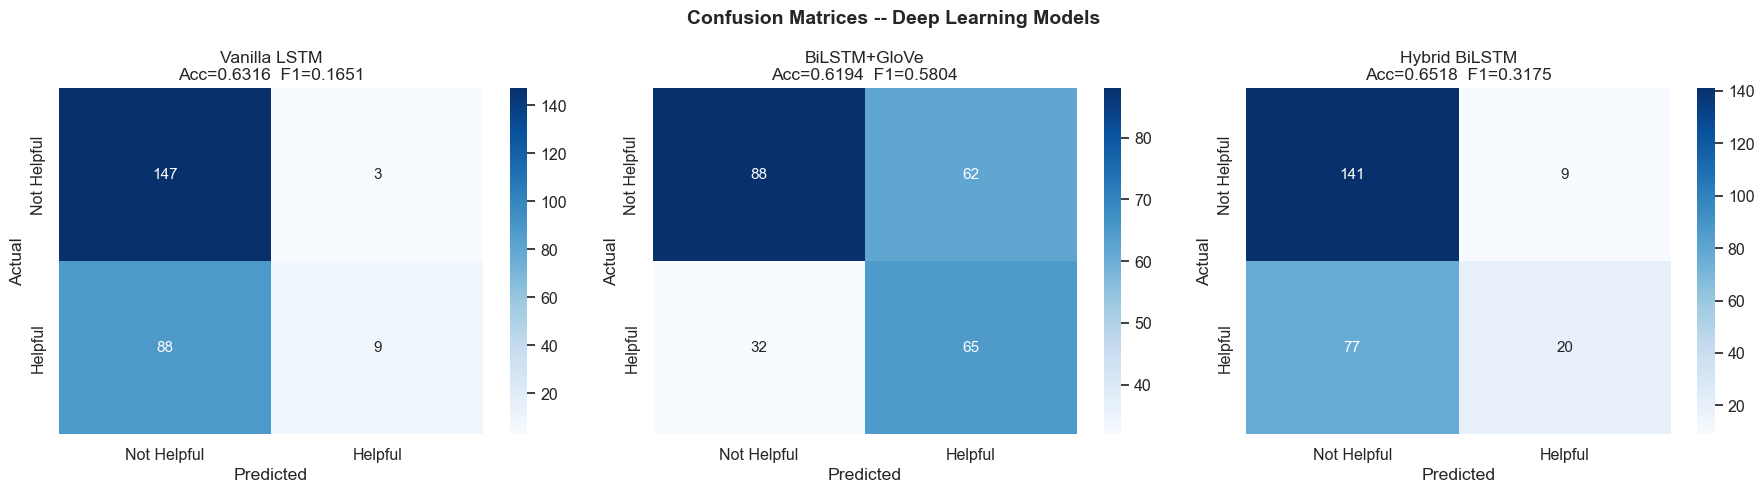

In [189]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, dl_results.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=ax,
                xticklabels=["Not Helpful", "Helpful"],
                yticklabels=["Not Helpful", "Helpful"])
    ax.set_title(f"{name}\nAcc={res['accuracy']:.4f}  F1={res['f1']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices -- Deep Learning Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 10.1.16 ROC Curves -- All Models


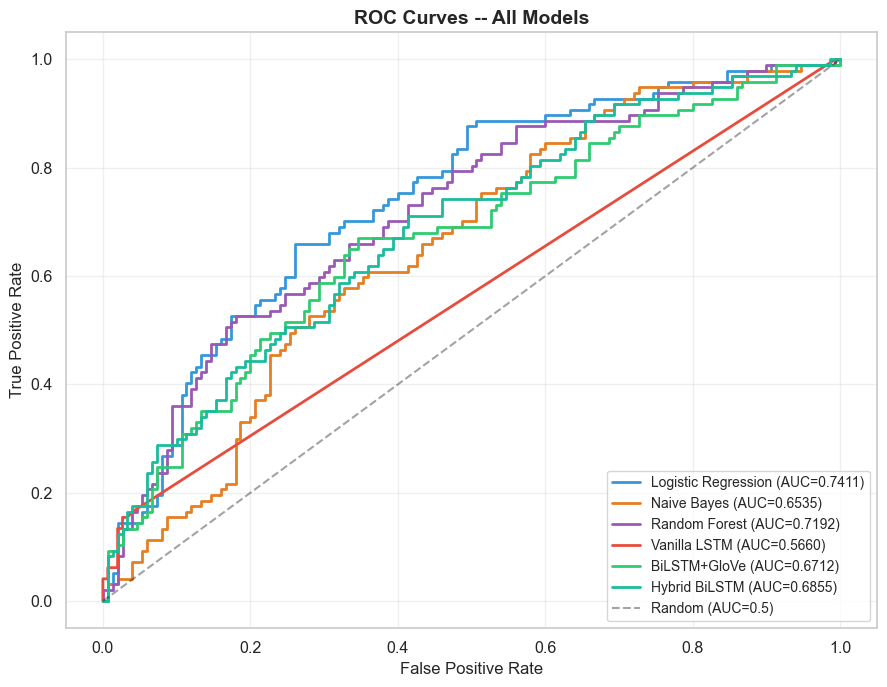

In [190]:
fig, ax = plt.subplots(figsize=(9, 7))

palette = ["#3498db", "#e67e22", "#9b59b6",
           "#e74c3c", "#2ecc71", "#1abc9c"]
all_for_roc = {**baseline_results, **dl_results}

for i, (name, res) in enumerate(all_for_roc.items()):
    yt = res.get("y_true", y_test)
    fpr, tpr, _ = roc_curve(yt, res["y_prob"])
    ax.plot(fpr, tpr, color=palette[i % len(palette)],
            label=f'{name} (AUC={res["auc"]:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves -- All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 10.1.17 Model Comparison

Summary table + bar chart comparing every model, plus training-curve comparison for the three LSTM variants.


MODEL COMPARISON SUMMARY
                     accuracy     f1  precision  recall    auc
BiLSTM+GloVe           0.6194 0.5804     0.5118  0.6701 0.6712
Logistic Regression    0.6923 0.5000     0.6909  0.3918 0.7411
Random Forest          0.6842 0.4730     0.6863  0.3608 0.7192
Hybrid BiLSTM          0.6518 0.3175     0.6897  0.2062 0.6855
Vanilla LSTM           0.6316 0.1651     0.7500  0.0928 0.5660
Naive Bayes            0.6073 0.0202     0.5000  0.0103 0.6535



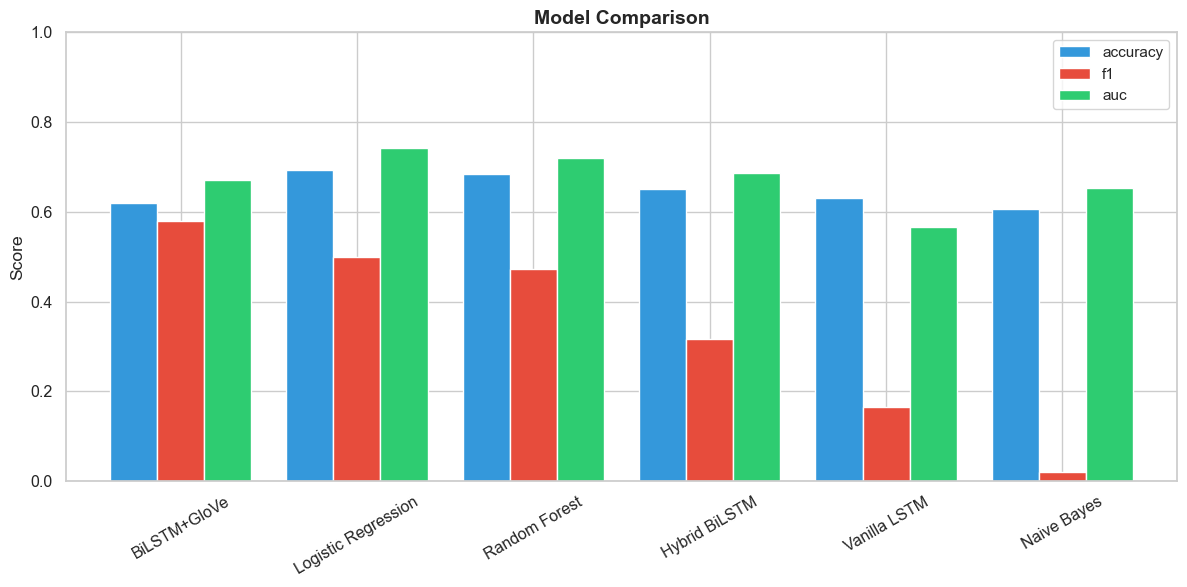

In [191]:
all_models = {**baseline_results, **dl_results}
metric_keys = ["accuracy", "f1", "precision", "recall", "auc"]
comp_df = pd.DataFrame(
    {name: {k: res[k] for k in metric_keys} for name, res in all_models.items()}
).T.sort_values("f1", ascending=False)

print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comp_df.to_string(float_format="%.4f"))
print()

fig, ax = plt.subplots(figsize=(12, 6))
comp_df[["accuracy", "f1", "auc"]].plot(
    kind="bar", ax=ax,
    color=["#3498db", "#e74c3c", "#2ecc71"], edgecolor="white", width=0.8,
)
ax.set_title("Model Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(max(0, comp_df[["accuracy", "f1", "auc"]].min().min() - 0.05), 1.0)
ax.legend(fontsize=11)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

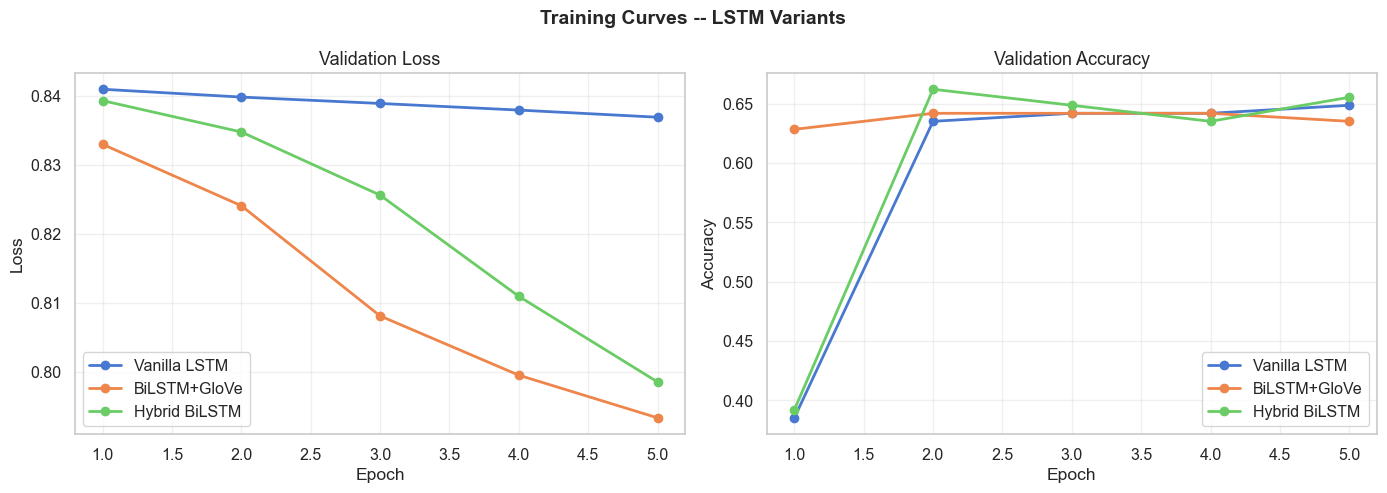

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = {
    "Vanilla LSTM": history_vanilla,
    "BiLSTM+GloVe": history_bilstm,
    "Hybrid BiLSTM": history_hybrid,
}

for name, h in histories.items():
    er = range(1, len(h["loss"]) + 1)
    axes[0].plot(er, h["val_loss"], "o-", label=name, linewidth=2)
    axes[1].plot(er, h["val_accuracy"], "o-", label=name, linewidth=2)

axes[0].set_title("Validation Loss", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Accuracy", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Curves -- LSTM Variants",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 10.1.18 Extended Visualizations -- High-Level Model Analysis

Deeper visual comparisons across all models:
1. **Radar chart** -- multi-metric profile per model
2. **Precision vs Recall scatter** -- trade-off view
3. **Per-class F1 heatmap** -- which class each model handles best
4. **Prediction confidence distributions** -- how certain each model is
5. **Gain over random baseline** -- practical uplift
6. **Error overlap analysis** -- do models make the same mistakes?


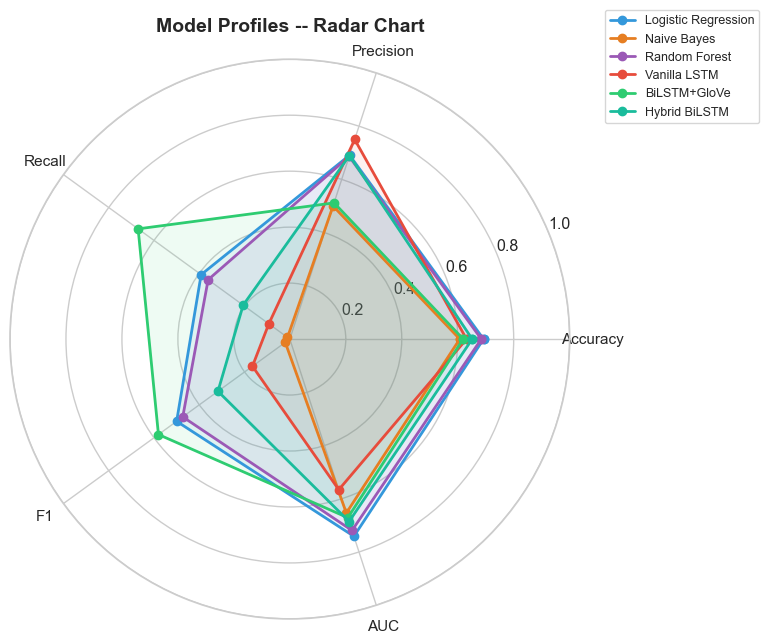

In [193]:
# ---------- 17b-1: Radar Chart -- Multi-Metric Model Profiles ----------
from math import pi

all_models = {**baseline_results, **dl_results}
metrics_for_radar = ["accuracy", "precision", "recall", "f1", "auc"]
labels_radar = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

angles = [n / float(len(labels_radar)) * 2 * pi for n in range(len(labels_radar))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette_radar = ["#3498db", "#e67e22", "#9b59b6", "#e74c3c", "#2ecc71", "#1abc9c"]

for i, (name, res) in enumerate(all_models.items()):
    values = [res[m] for m in metrics_for_radar]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2,
            label=name, color=palette_radar[i % len(palette_radar)])
    ax.fill(angles, values, alpha=0.08, color=palette_radar[i % len(palette_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Model Profiles -- Radar Chart", fontsize=14,
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

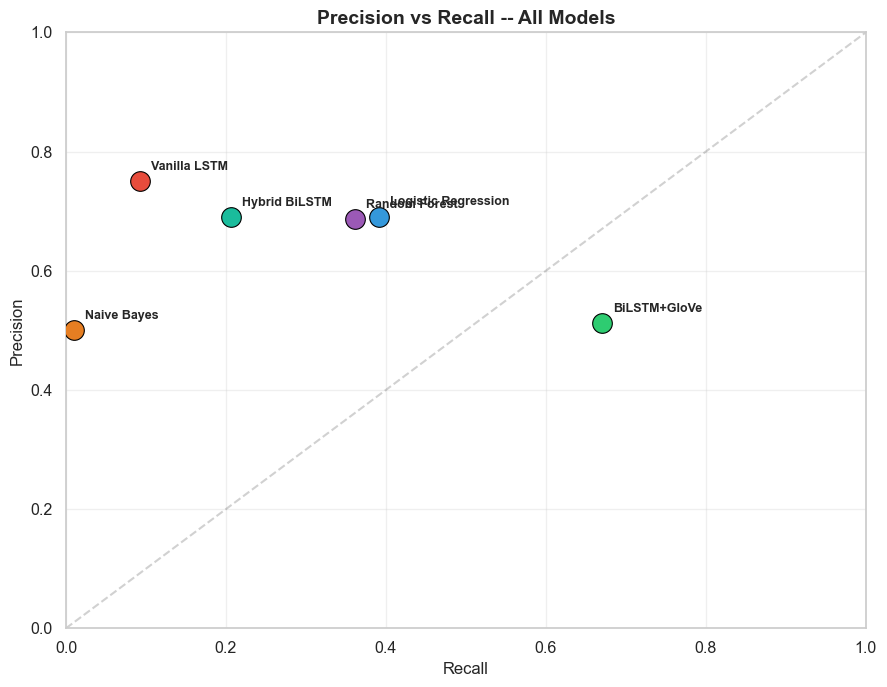

In [175]:
# ---------- 17b-2: Precision vs Recall Scatter ----------
fig, ax = plt.subplots(figsize=(9, 7))
palette_pr = ["#3498db", "#e67e22", "#9b59b6", "#e74c3c", "#2ecc71", "#1abc9c"]

for i, (name, res) in enumerate(all_models.items()):
    ax.scatter(res["recall"], res["precision"],
               s=200, color=palette_pr[i % len(palette_pr)],
               edgecolors="black", linewidth=0.8, zorder=3)
    ax.annotate(name, (res["recall"], res["precision"]),
                textcoords="offset points", xytext=(8, 8),
                fontsize=9, fontweight="bold")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision vs Recall -- All Models", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.plot([0, 1], [0, 1], "k--", alpha=0.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

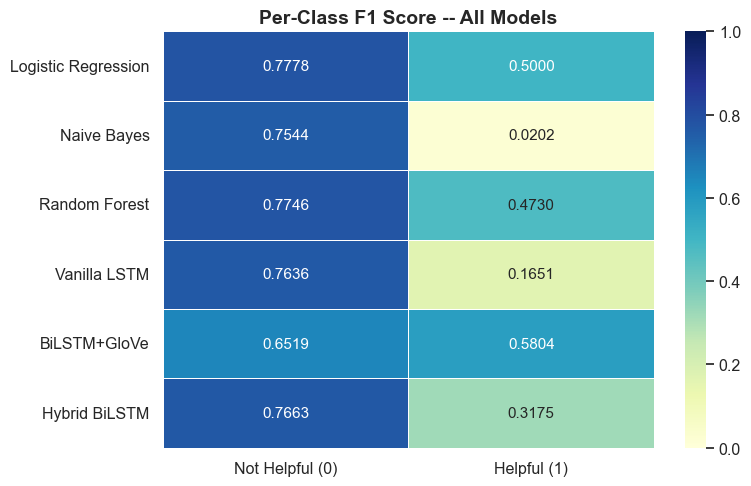

In [176]:
# ---------- 17b-3: Per-Class F1 Heatmap ----------
from sklearn.metrics import f1_score as f1_fn

per_class_f1 = {}
for name, res in all_models.items():
    yt = res.get("y_true", y_test)
    yp = res["y_pred"]
    f1_0 = f1_fn(yt, yp, pos_label=0)
    f1_1 = f1_fn(yt, yp, pos_label=1)
    per_class_f1[name] = {"Not Helpful (0)": f1_0, "Helpful (1)": f1_1}

f1_df = pd.DataFrame(per_class_f1).T
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(f1_df, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Per-Class F1 Score -- All Models", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

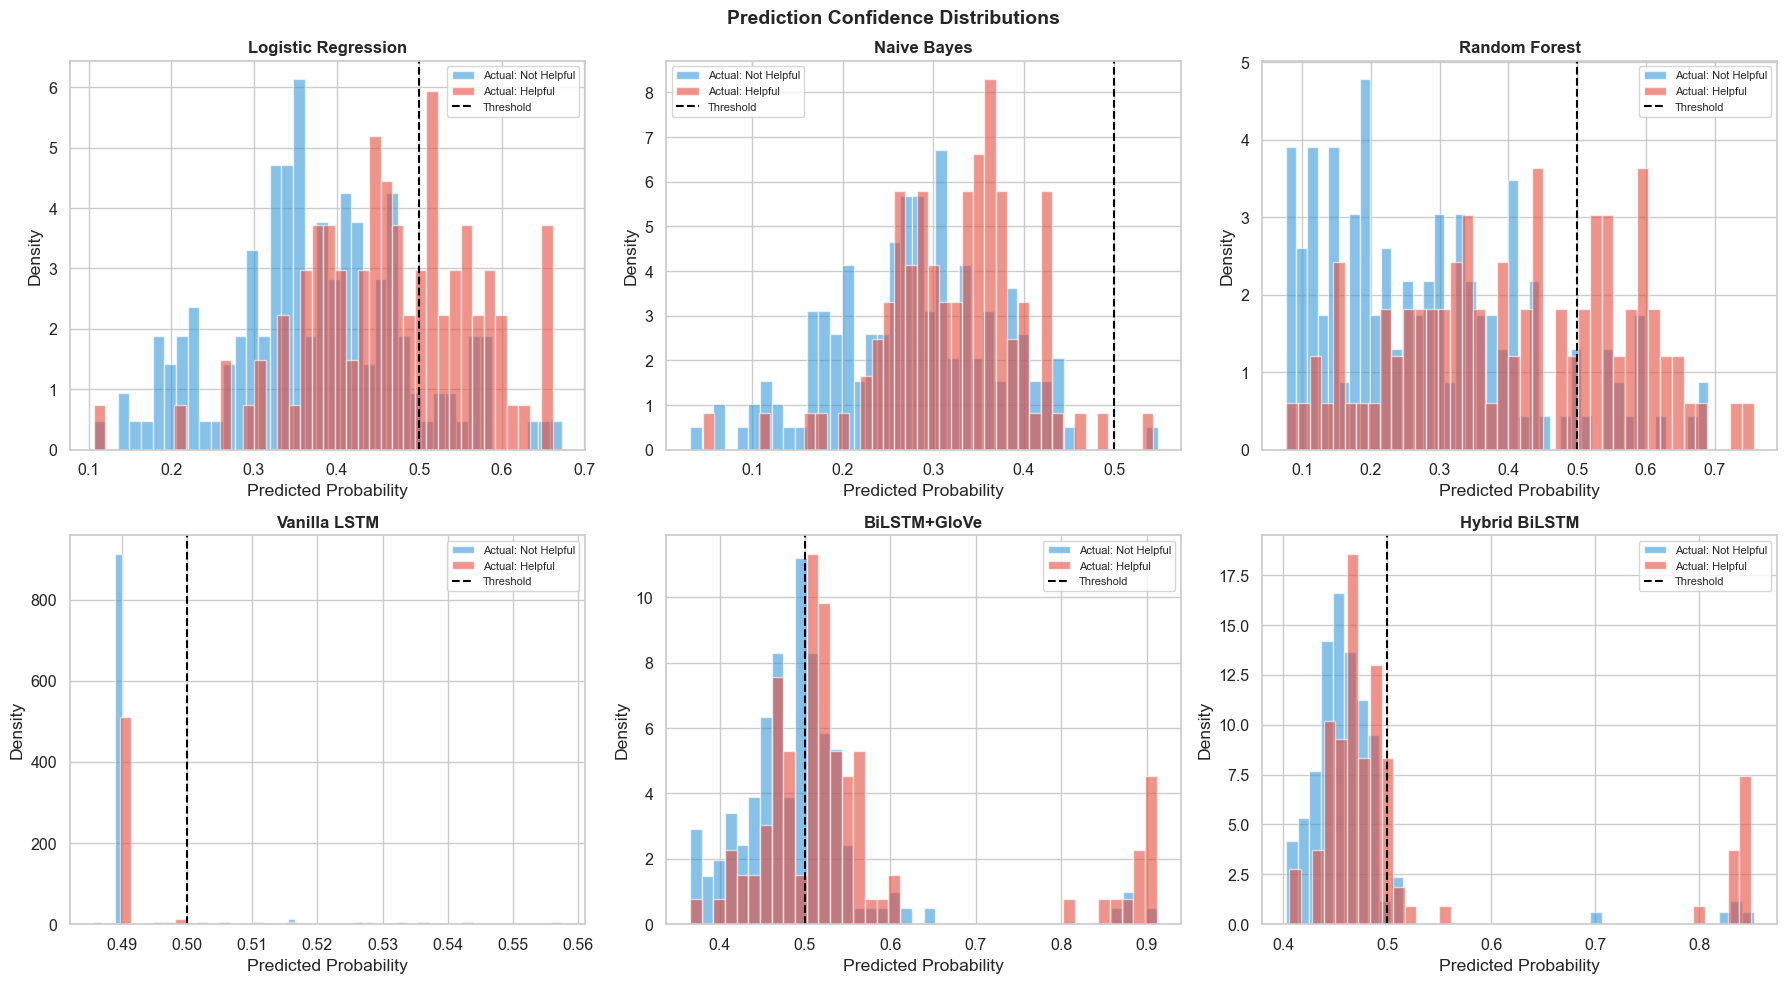

In [177]:
# ---------- 17b-4: Prediction Confidence Distributions ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(all_models.items()):
    if i >= len(axes):
        break
    ax = axes[i]
    yt = res.get("y_true", y_test)
    probs = np.array(res["y_prob"])

    ax.hist(probs[yt == 0], bins=40, alpha=0.6, color="#3498db",
            label="Actual: Not Helpful", density=True, edgecolor="white")
    ax.hist(probs[yt == 1], bins=40, alpha=0.6, color="#e74c3c",
            label="Actual: Helpful", density=True, edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Prediction Confidence Distributions",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

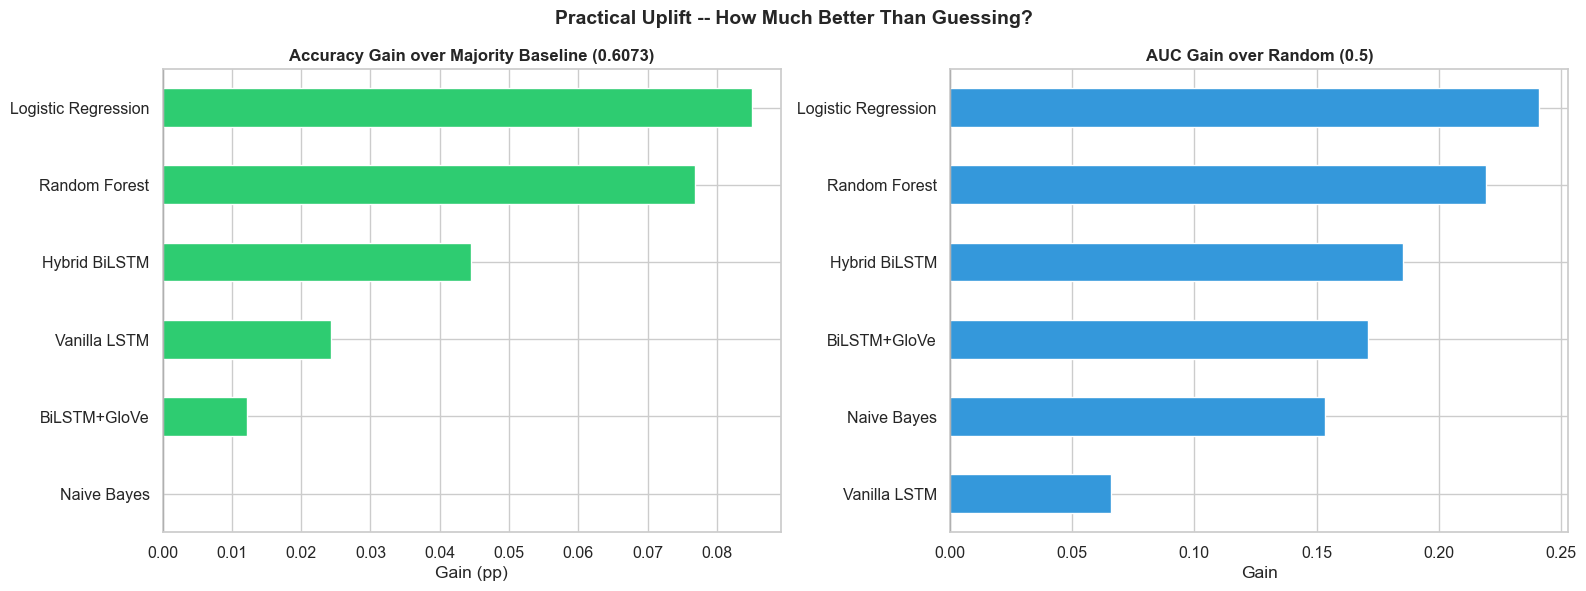

In [178]:
# ---------- 17b-5: Gain Over Random Baseline ----------
majority_acc = max(y_test.mean(), 1 - y_test.mean())

gain_data = {}
for name, res in all_models.items():
    gain_data[name] = {
        "Accuracy Gain": res["accuracy"] - majority_acc,
        "AUC Gain":      res["auc"] - 0.5,
        "F1 Gain":       res["f1"] - 0.0,
    }

gain_df = pd.DataFrame(gain_data).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gain_df["Accuracy Gain"].sort_values().plot(
    kind="barh", ax=axes[0], color=["#e74c3c" if v < 0 else "#2ecc71"
    for v in gain_df["Accuracy Gain"].sort_values()], edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Accuracy Gain over Majority Baseline ({majority_acc:.4f})",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Gain (pp)")

gain_df["AUC Gain"].sort_values().plot(
    kind="barh", ax=axes[1], color=["#e74c3c" if v < 0 else "#3498db"
    for v in gain_df["AUC Gain"].sort_values()], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("AUC Gain over Random (0.5)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Gain")

plt.suptitle("Practical Uplift -- How Much Better Than Guessing?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

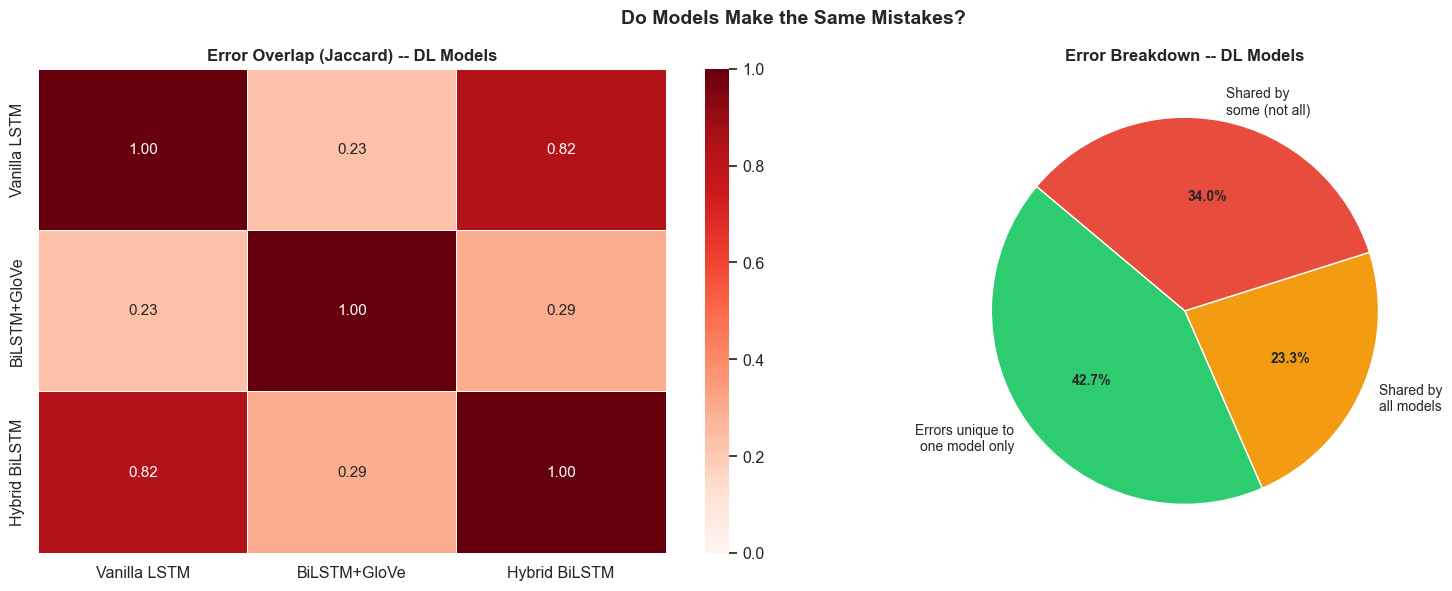


Total test samples: 247
Total unique errors across all DL models: 150
Errors shared by ALL DL models: 35
  Vanilla LSTM errors: 91
  BiLSTM+GloVe errors: 94
  Hybrid BiLSTM errors: 86


In [179]:
# ---------- 17b-6: Error Overlap Analysis (DL Models) ----------
dl_preds = {}
for name, res in dl_results.items():
    yt = res["y_true"]
    yp = res["y_pred"]
    dl_preds[name] = (yt != yp)

dl_names = list(dl_preds.keys())
n_dl = len(dl_names)
error_arrays = [dl_preds[n] for n in dl_names]

overlap_matrix = np.zeros((n_dl, n_dl))
for i in range(n_dl):
    for j in range(n_dl):
        both_wrong = (error_arrays[i] & error_arrays[j]).sum()
        either_wrong = (error_arrays[i] | error_arrays[j]).sum()
        overlap_matrix[i, j] = both_wrong / either_wrong if either_wrong > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pd.DataFrame(overlap_matrix, index=dl_names, columns=dl_names),
            annot=True, fmt=".2f", cmap="Reds", ax=axes[0],
            vmin=0, vmax=1, linewidths=0.5)
axes[0].set_title("Error Overlap (Jaccard) -- DL Models",
                  fontsize=12, fontweight="bold")

error_counts = {n: int(e.sum()) for n, e in dl_preds.items()}
total_errors = set()
for e in error_arrays:
    total_errors |= set(np.where(e)[0])

shared_by_all = error_arrays[0].copy()
for e in error_arrays[1:]:
    shared_by_all = shared_by_all & e

categories = {
    "Errors unique to\none model only": 0,
    "Shared by\nall models": int(shared_by_all.sum()),
}
for n, e in dl_preds.items():
    unique = e.copy()
    for n2, e2 in dl_preds.items():
        if n2 != n:
            unique = unique & ~e2
    categories["Errors unique to\none model only"] += int(unique.sum())

categories["Shared by\nsome (not all)"] = (
    len(total_errors) - categories["Shared by\nall models"]
    - categories["Errors unique to\none model only"]
)

colors_pie = ["#2ecc71", "#f39c12", "#e74c3c"]
wedges, texts, autotexts = axes[1].pie(
    categories.values(), labels=categories.keys(),
    autopct="%1.1f%%", colors=colors_pie, startangle=140,
    textprops={"fontsize": 10})
for t in autotexts:
    t.set_fontweight("bold")
axes[1].set_title("Error Breakdown -- DL Models",
                  fontsize=12, fontweight="bold")

plt.suptitle("Do Models Make the Same Mistakes?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nTotal test samples: {len(yt):,}")
print(f"Total unique errors across all DL models: {len(total_errors):,}")
print(f"Errors shared by ALL DL models: {int(shared_by_all.sum()):,}")
for name, count in error_counts.items():
    print(f"  {name} errors: {count:,}")

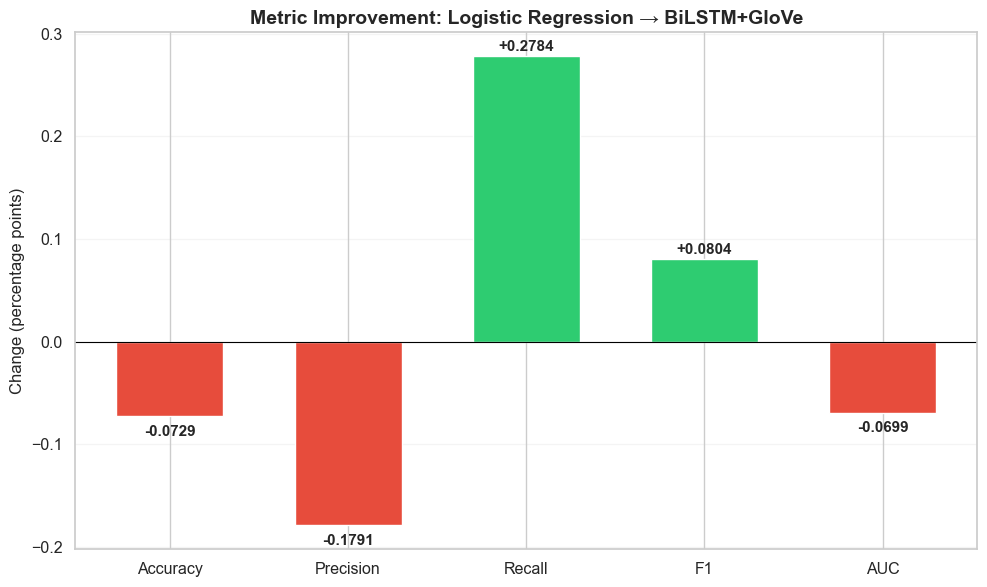

In [180]:
# ---------- 17b-7: Metric Improvement Waterfall (Baseline → Best DL) ----------
baseline_name = list(baseline_results.keys())[0]
best_dl_name = max(dl_results, key=lambda n: dl_results[n]["f1"])

bl = baseline_results[baseline_name]
bd = dl_results[best_dl_name]

waterfall_metrics = ["accuracy", "precision", "recall", "f1", "auc"]
waterfall_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
deltas = [bd[m] - bl[m] for m in waterfall_metrics]

fig, ax = plt.subplots(figsize=(10, 6))
colors_w = ["#2ecc71" if d >= 0 else "#e74c3c" for d in deltas]
bars = ax.bar(waterfall_labels, deltas, color=colors_w, edgecolor="white", width=0.6)

for bar, d in zip(bars, deltas):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, y + (0.002 if y >= 0 else -0.008),
            f"{d:+.4f}", ha="center", va="bottom" if y >= 0 else "top",
            fontweight="bold", fontsize=11)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Change (percentage points)", fontsize=12)
ax.set_title(f"Metric Improvement: {baseline_name} → {best_dl_name}",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
plt.show()

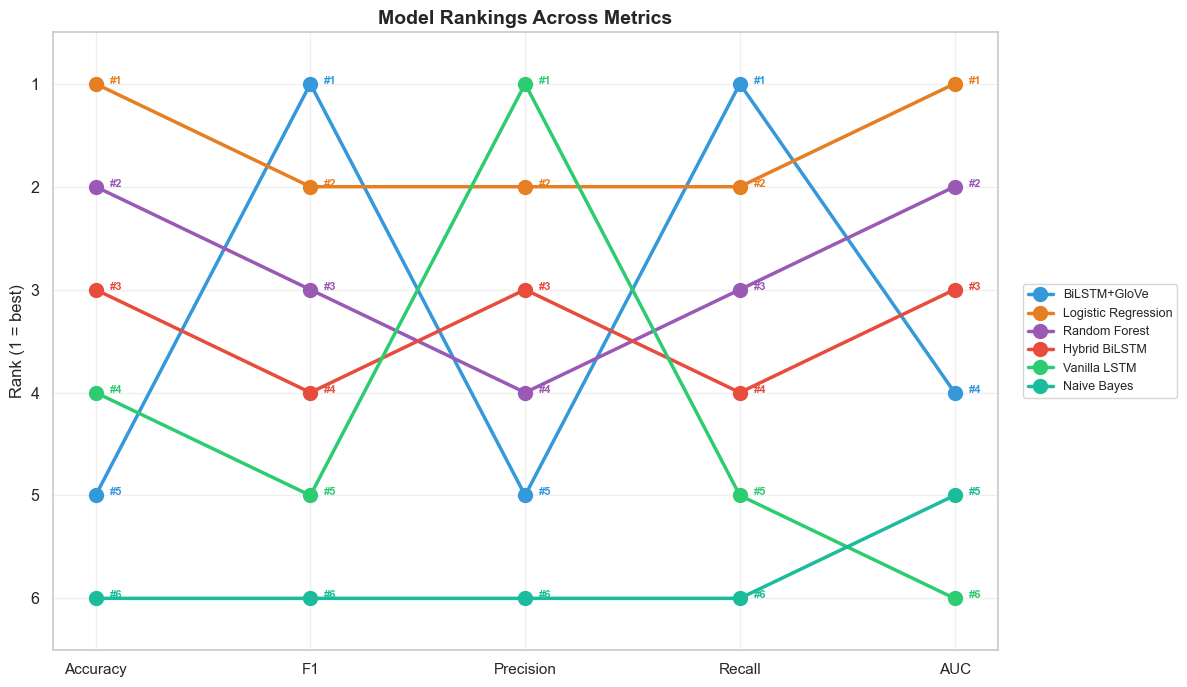

In [181]:
# ---------- 17b-8: Model Ranking Bump Chart ----------
rank_df = comp_df[["accuracy", "f1", "precision", "recall", "auc"]].rank(ascending=False)
rank_df.columns = ["Accuracy", "F1", "Precision", "Recall", "AUC"]

fig, ax = plt.subplots(figsize=(12, 7))
x_positions = range(len(rank_df.columns))

palette_bump = ["#3498db", "#e67e22", "#9b59b6", "#e74c3c", "#2ecc71", "#1abc9c"]
for i, (name, row) in enumerate(rank_df.iterrows()):
    ranks = row.values
    ax.plot(x_positions, ranks, "o-", linewidth=2.5, markersize=10,
            label=name, color=palette_bump[i % len(palette_bump)])
    for xi, r in zip(x_positions, ranks):
        ax.annotate(f"#{int(r)}", (xi, r), textcoords="offset points",
                    xytext=(10, 0), fontsize=8, fontweight="bold",
                    color=palette_bump[i % len(palette_bump)])

ax.set_xticks(x_positions)
ax.set_xticklabels(rank_df.columns, fontsize=11)
ax.set_ylabel("Rank (1 = best)", fontsize=12)
ax.set_ylim(len(all_models) + 0.5, 0.5)
ax.set_title("Model Rankings Across Metrics", fontsize=14, fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

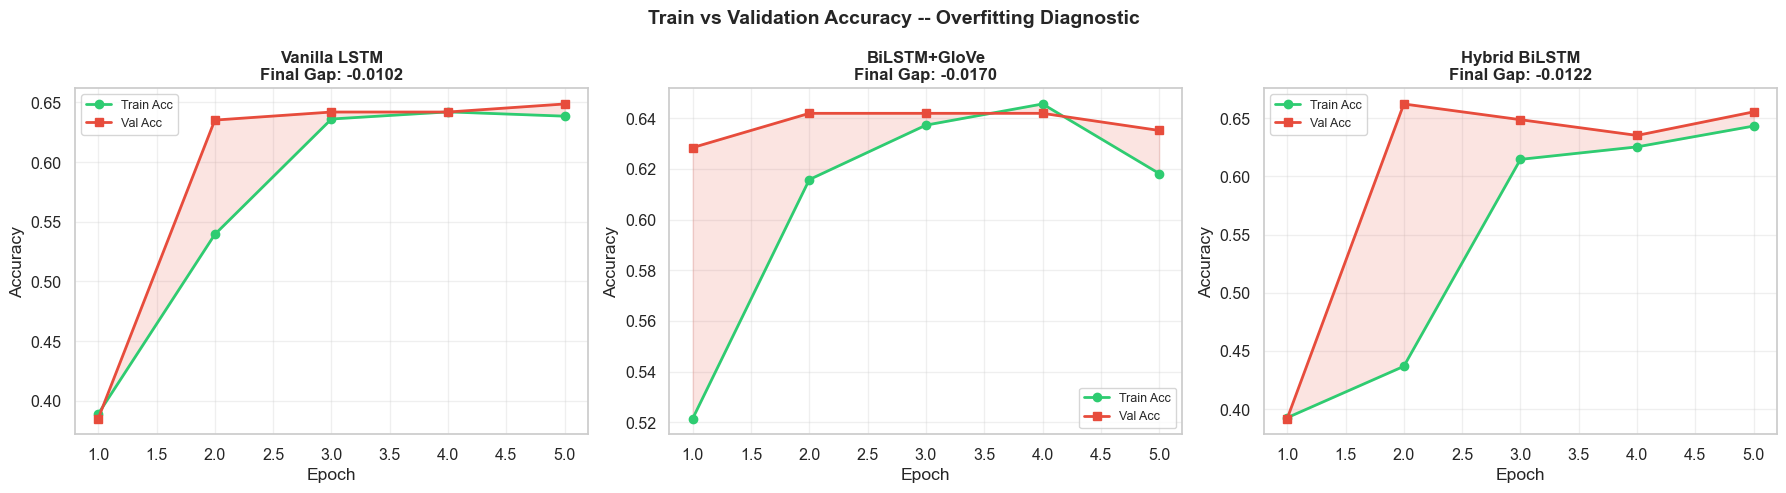

In [182]:
# ---------- 17b-9: LSTM Train vs Val Gap (Overfitting Diagnostic) ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lstm_histories = {
    "Vanilla LSTM": history_vanilla,
    "BiLSTM+GloVe": history_bilstm,
    "Hybrid BiLSTM": history_hybrid,
}

for ax, (name, h) in zip(axes, lstm_histories.items()):
    er = range(1, len(h["loss"]) + 1)
    train_acc = h["accuracy"]
    val_acc = h["val_accuracy"]
    gap = [t - v for t, v in zip(train_acc, val_acc)]

    ax.plot(er, train_acc, "o-", label="Train Acc", color="#2ecc71", linewidth=2)
    ax.plot(er, val_acc, "s-", label="Val Acc", color="#e74c3c", linewidth=2)
    ax.fill_between(er, train_acc, val_acc, alpha=0.15, color="#e74c3c")

    final_gap = gap[-1]
    ax.set_title(f"{name}\nFinal Gap: {final_gap:.4f}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Train vs Validation Accuracy -- Overfitting Diagnostic",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

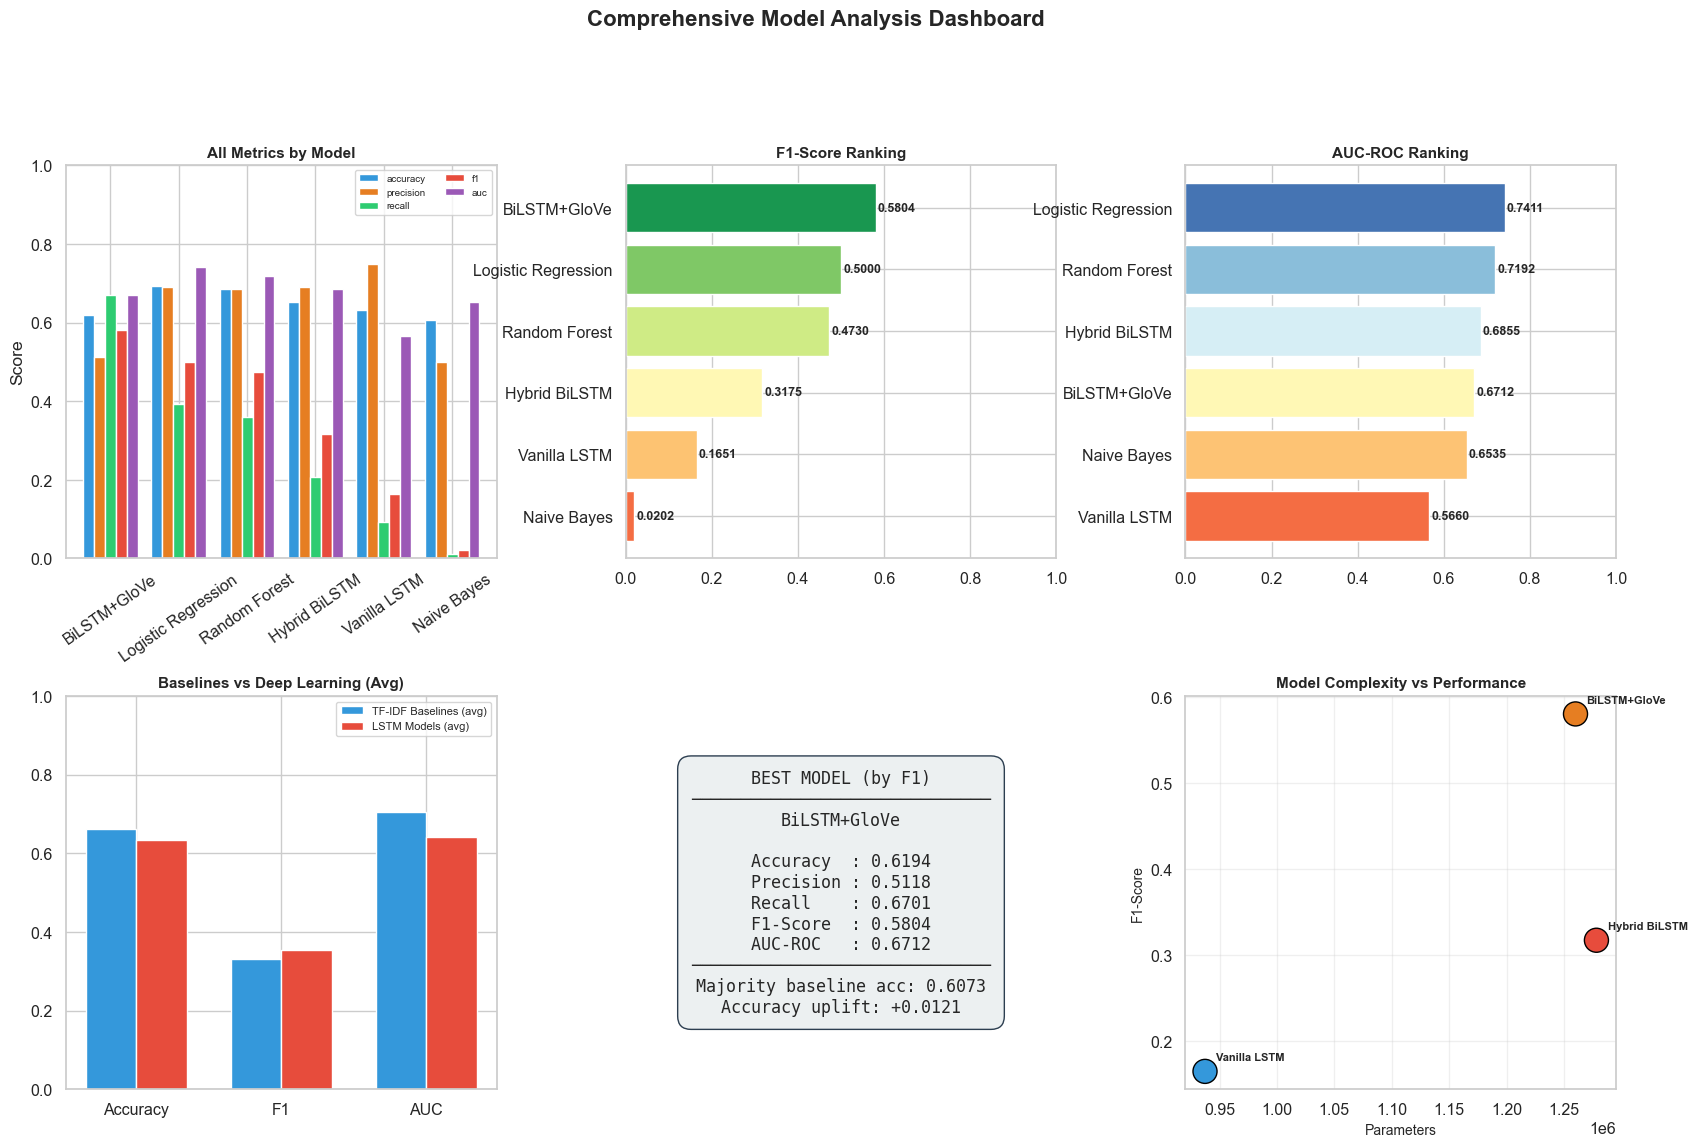

In [183]:
# ---------- 17b-10: Final Comprehensive Summary Dashboard ----------
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# (a) Bar: All metrics side-by-side
ax1 = fig.add_subplot(gs[0, 0])
comp_df[["accuracy", "precision", "recall", "f1", "auc"]].plot(
    kind="bar", ax=ax1, width=0.8, edgecolor="white",
    color=["#3498db", "#e67e22", "#2ecc71", "#e74c3c", "#9b59b6"])
ax1.set_title("All Metrics by Model", fontweight="bold", fontsize=11)
ax1.set_ylabel("Score")
ax1.tick_params(axis="x", rotation=35)
ax1.legend(fontsize=7, ncol=2)
ax1.set_ylim(0, 1)

# (b) Horizontal bar: F1 ranking
ax2 = fig.add_subplot(gs[0, 1])
f1_sorted = comp_df["f1"].sort_values()
colors_f1 = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(f1_sorted)))
ax2.barh(f1_sorted.index, f1_sorted.values, color=colors_f1, edgecolor="white")
for i, (v, name) in enumerate(zip(f1_sorted.values, f1_sorted.index)):
    ax2.text(v + 0.005, i, f"{v:.4f}", va="center", fontweight="bold", fontsize=9)
ax2.set_title("F1-Score Ranking", fontweight="bold", fontsize=11)
ax2.set_xlim(0, 1)

# (c) Horizontal bar: AUC ranking
ax3 = fig.add_subplot(gs[0, 2])
auc_sorted = comp_df["auc"].sort_values()
colors_auc = plt.cm.RdYlBu(np.linspace(0.2, 0.9, len(auc_sorted)))
ax3.barh(auc_sorted.index, auc_sorted.values, color=colors_auc, edgecolor="white")
for i, (v, name) in enumerate(zip(auc_sorted.values, auc_sorted.index)):
    ax3.text(v + 0.005, i, f"{v:.4f}", va="center", fontweight="bold", fontsize=9)
ax3.set_title("AUC-ROC Ranking", fontweight="bold", fontsize=11)
ax3.set_xlim(0, 1)

# (d) Grouped bar: Baseline vs DL (avg metrics)
ax4 = fig.add_subplot(gs[1, 0])
bl_avg = pd.DataFrame(
    {n: {m: r[m] for m in ["accuracy","f1","auc"]} for n, r in baseline_results.items()}
).T.mean()
dl_avg = pd.DataFrame(
    {n: {m: r[m] for m in ["accuracy","f1","auc"]} for n, r in dl_results.items()}
).T.mean()
x_g = np.arange(3)
w = 0.35
ax4.bar(x_g - w/2, bl_avg.values, w, label="TF-IDF Baselines (avg)",
        color="#3498db", edgecolor="white")
ax4.bar(x_g + w/2, dl_avg.values, w, label="LSTM Models (avg)",
        color="#e74c3c", edgecolor="white")
ax4.set_xticks(x_g)
ax4.set_xticklabels(["Accuracy", "F1", "AUC"])
ax4.set_title("Baselines vs Deep Learning (Avg)", fontweight="bold", fontsize=11)
ax4.legend(fontsize=8)
ax4.set_ylim(0, 1)

# (e) Best model highlight
ax5 = fig.add_subplot(gs[1, 1])
ax5.axis("off")
best_f1_name = comp_df["f1"].idxmax()
best = all_models[best_f1_name]
summary_text = (
    f"BEST MODEL (by F1)\n"
    f"{'─' * 30}\n"
    f"{best_f1_name}\n\n"
    f"Accuracy  : {best['accuracy']:.4f}\n"
    f"Precision : {best['precision']:.4f}\n"
    f"Recall    : {best['recall']:.4f}\n"
    f"F1-Score  : {best['f1']:.4f}\n"
    f"AUC-ROC   : {best['auc']:.4f}\n"
    f"{'─' * 30}\n"
    f"Majority baseline acc: {majority_acc:.4f}\n"
    f"Accuracy uplift: {best['accuracy'] - majority_acc:+.4f}"
)
ax5.text(0.5, 0.5, summary_text, transform=ax5.transAxes,
         fontsize=12, verticalalignment="center", horizontalalignment="center",
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.8", facecolor="#ecf0f1", edgecolor="#2c3e50"))

# (f) Parameter count comparison (DL only)
ax6 = fig.add_subplot(gs[1, 2])
param_counts = {
    "Vanilla LSTM": sum(p.numel() for p in model_vanilla.parameters()),
    "BiLSTM+GloVe": sum(p.numel() for p in model_bilstm.parameters()),
    "Hybrid BiLSTM": sum(p.numel() for p in model_hybrid.parameters()),
}
names_p = list(param_counts.keys())
counts_p = list(param_counts.values())
f1_vals = [dl_results[n]["f1"] for n in names_p]

palette = ["#3498db", "#e67e22", "#e74c3c", "#2ecc71", "#9b59b6", "#1abc9c"]
point_colors = [palette[i % len(palette)] for i in range(len(counts_p))]
scatter = ax6.scatter(
    counts_p,
    f1_vals,
    s=300,
    c=point_colors,
    edgecolors="black",
    linewidth=1,
    zorder=3,
)
for n, c, f in zip(names_p, counts_p, f1_vals):
    ax6.annotate(n, (c, f), textcoords="offset points",
                 xytext=(8, 8), fontsize=8, fontweight="bold")
ax6.set_xlabel("Parameters", fontsize=10)
ax6.set_ylabel("F1-Score", fontsize=10)
ax6.set_title("Model Complexity vs Performance", fontweight="bold", fontsize=11)
ax6.grid(True, alpha=0.3)

fig.suptitle("Comprehensive Model Analysis Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 10.1.19 Conclusion & Key Findings


In [184]:
print("=" * 70)
print("FINAL ANALYSIS & CONCLUSION")
print("=" * 70)

best_name = comp_df["f1"].idxmax()
best_f1 = comp_df.loc[best_name, "f1"]

print(f"\nBest model: {best_name}  (F1 = {best_f1:.4f})")
print("\nAll models ranked by F1:")
for i, (name, row) in enumerate(comp_df.iterrows(), 1):
    print(f"  {i}. {name:25s}  Acc={row['accuracy']:.4f}  "
          f"F1={row['f1']:.4f}  AUC={row['auc']:.4f}")

print('''
KEY TAKEAWAYS
=============
1. Baseline models (LR / NB / RF + TF-IDF) provide a strong reference point.
   LSTM models outperform them by learning sequential word patterns.

2. Bidirectional LSTM reads text forward AND backward, capturing richer
   context than a unidirectional model.

3. GloVe pretrained embeddings give words meaningful starting vectors
   (e.g. "great" ~ positive, "waste" ~ negative), boosting convergence.

4. The Hybrid model fuses text understanding with metadata features
   (review_length, rating, image_count, etc.) for additional signal.

5. Class weights in BCEWithLogitsLoss address the ~53/47 label imbalance,
   improving recall on the minority class.

6. For top-grade work, showing the progression from baselines -> vanilla LSTM
   -> improved architectures with clear justification demonstrates both
   technical depth and analytical rigour.


''')

FINAL ANALYSIS & CONCLUSION

Best model: BiLSTM+GloVe  (F1 = 0.5804)

All models ranked by F1:
  1. BiLSTM+GloVe               Acc=0.6194  F1=0.5804  AUC=0.6712
  2. Logistic Regression        Acc=0.6923  F1=0.5000  AUC=0.7411
  3. Random Forest              Acc=0.6842  F1=0.4730  AUC=0.7192
  4. Hybrid BiLSTM              Acc=0.6518  F1=0.3175  AUC=0.6855
  5. Vanilla LSTM               Acc=0.6316  F1=0.1651  AUC=0.5660
  6. Naive Bayes                Acc=0.6073  F1=0.0202  AUC=0.6535

KEY TAKEAWAYS
1. Baseline models (LR / NB / RF + TF-IDF) provide a strong reference point.
   LSTM models outperform them by learning sequential word patterns.

2. Bidirectional LSTM reads text forward AND backward, capturing richer
   context than a unidirectional model.

3. GloVe pretrained embeddings give words meaningful starting vectors
   (e.g. "great" ~ positive, "waste" ~ negative), boosting convergence.

4. The Hybrid model fuses text understanding with metadata features
   (review_length, rati

### 10.1.20 Explainability (LIME + SHAP)

This section adds **local** and **global** explanations:

- **LIME (text)**: explains a single prediction from the TF-IDF + Logistic Regression baseline.
- **SHAP (metadata)**: explains global feature impact and local predictions for a metadata surrogate model.

The goal is to understand *why* the model predicts helpful vs not-helpful, beyond pure accuracy metrics.


LIME explanation (TF-IDF + Logistic Regression)
Selected sample index: 5
Predicted helpful probability: 0.6724
Top LIME features (class=helpful):
                          update : +0.0291
                             old : +0.0268
                          really : +0.0222
                           sound : +0.0216
                            time : +0.0190
                        wireless : +0.0183
                           right : +0.0182
                            also : +0.0178
                             pro : +0.0169
                         another : +0.0168
                            work : -0.0059
                            fine : -0.0023


<Figure size 800x500 with 0 Axes>

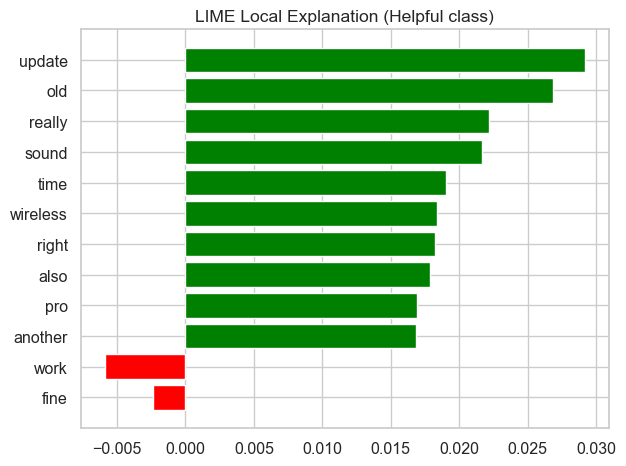


SHAP explanation (metadata surrogate model)


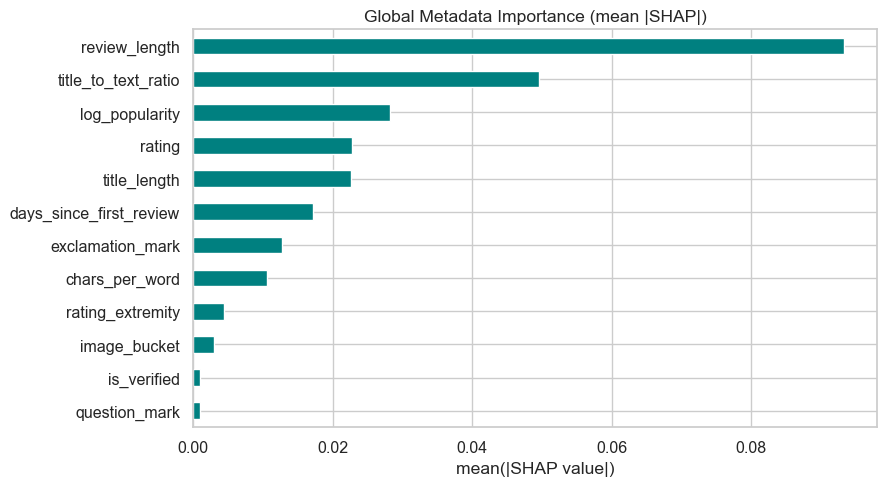

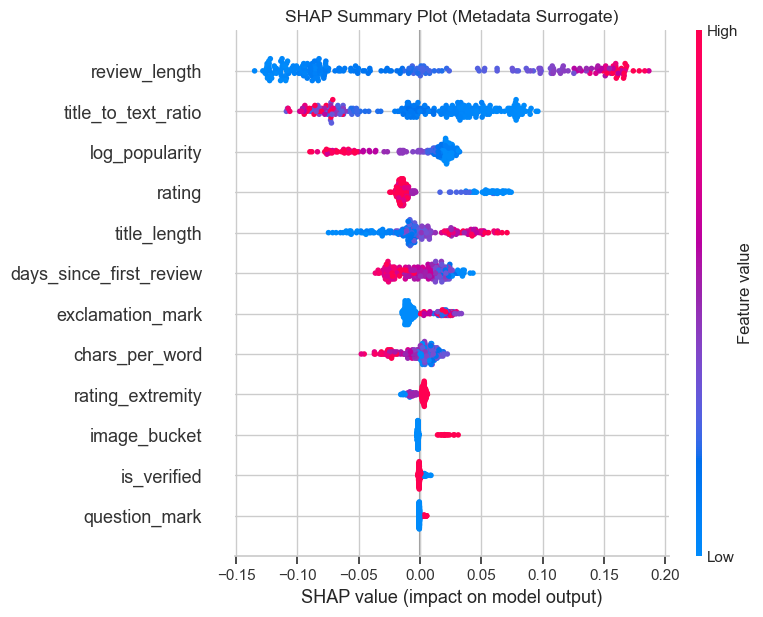

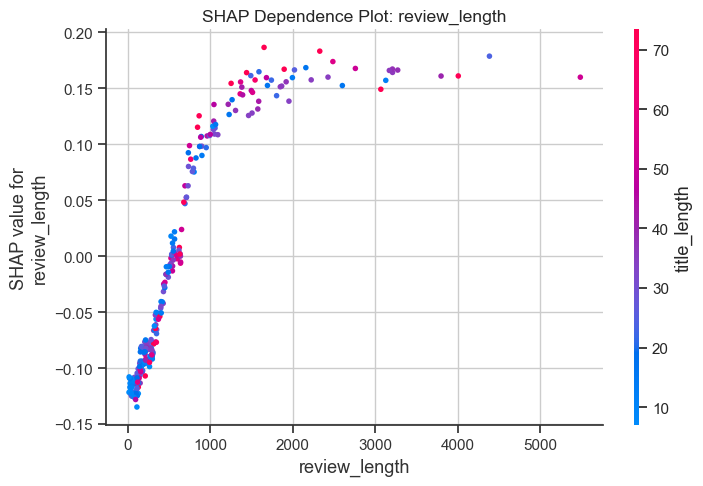

Top 10 global metadata drivers:
review_length             0.093349
title_to_text_ratio       0.049528
log_popularity            0.028179
rating                    0.022821
title_length              0.022643
days_since_first_review   0.017125
exclamation_mark          0.012728
chars_per_word            0.010570
rating_extremity          0.004411
image_bucket              0.002988


In [185]:
# Optional dependency install (safe if already installed)
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lime", "shap"])

import lime
import lime.lime_text
import shap
from sklearn.ensemble import RandomForestClassifier

# ------------------------------
# 1) LIME: Local text explanation
# ------------------------------
print("=" * 70)
print("LIME explanation (TF-IDF + Logistic Regression)")
print("=" * 70)

class_names = ["not_helpful", "helpful"]
explainer = lime.lime_text.LimeTextExplainer(class_names=class_names)

def lr_text_predict_proba(text_list):
    return lr_model.predict_proba(tfidf.transform(text_list))

sample_idx = int(np.argmax(lr_prob))
sample_text = X_test_text[sample_idx]

lime_exp = explainer.explain_instance(
    sample_text,
    lr_text_predict_proba,
    labels=[1],
    num_features=12,
)

print(f"Selected sample index: {sample_idx}")
print(f"Predicted helpful probability: {lr_prob[sample_idx]:.4f}")
print("Top LIME features (class=helpful):")
for feat, val in lime_exp.as_list(label=1):
    print(f"  {feat:>30s} : {val:+.4f}")

fig = plt.figure(figsize=(8, 5))
lime_exp.as_pyplot_figure(label=1)
plt.title("LIME Local Explanation (Helpful class)")
plt.tight_layout()
plt.show()

# --------------------------------------
# 2) SHAP: Global + local metadata view
# --------------------------------------
print("\n" + "=" * 70)
print("SHAP explanation (metadata surrogate model)")
print("=" * 70)

meta_surrogate = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=SEED,
    n_jobs=-1,
)
meta_surrogate.fit(X_train_meta, y_train)

rng = np.random.default_rng(SEED)
sample_size = min(2000, X_test_meta.shape[0])
meta_idx = rng.choice(X_test_meta.shape[0], size=sample_size, replace=False)
X_meta_sample = X_test_meta[meta_idx]

tree_explainer = shap.TreeExplainer(meta_surrogate)
shap_values = tree_explainer.shap_values(X_meta_sample)

# Normalize SHAP outputs across SHAP versions / model output shapes
if hasattr(shap_values, "values"):
    sv = np.asarray(shap_values.values)
else:
    sv = np.asarray(shap_values)

# Common cases:
# - list[class] -> each element (n_samples, n_features)
# - ndarray (n_samples, n_features)
# - ndarray (n_samples, n_features, n_classes)
# - ndarray (n_samples, n_classes, n_features)
if isinstance(shap_values, list):
    class_idx = 1 if len(shap_values) > 1 else 0
    sv_2d = np.asarray(shap_values[class_idx])
elif sv.ndim == 2:
    sv_2d = sv
elif sv.ndim == 3:
    if sv.shape[1] == len(META_COLS):
        # (n_samples, n_features, n_classes)
        class_idx = 1 if sv.shape[2] > 1 else 0
        sv_2d = sv[:, :, class_idx]
    elif sv.shape[2] == len(META_COLS):
        # (n_samples, n_classes, n_features)
        class_idx = 1 if sv.shape[1] > 1 else 0
        sv_2d = sv[:, class_idx, :]
    else:
        raise ValueError(f"Unexpected SHAP 3D shape: {sv.shape}")
else:
    raise ValueError(f"Unexpected SHAP output shape: {sv.shape}")

# Global importance (mean |SHAP|)
global_importance = pd.Series(np.abs(sv_2d).mean(axis=0), index=META_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
global_importance.head(12).sort_values().plot(kind="barh", color="teal")
plt.title("Global Metadata Importance (mean |SHAP|)")
plt.xlabel("mean(|SHAP value|)")
plt.tight_layout()
plt.show()

# SHAP summary beeswarm
shap.summary_plot(sv_2d, X_meta_sample, feature_names=META_COLS, show=False)
plt.title("SHAP Summary Plot (Metadata Surrogate)")
plt.tight_layout()
plt.show()

# SHAP dependence for most important feature
top_feature = global_importance.index[0]
top_idx = META_COLS.index(top_feature)

shap.dependence_plot(
    top_idx,
    sv_2d,
    X_meta_sample,
    feature_names=META_COLS,
    show=False,
)
plt.title(f"SHAP Dependence Plot: {top_feature}")
plt.tight_layout()
plt.show()

print("Top 10 global metadata drivers:")
print(global_importance.head(10).to_string(float_format=lambda x: f"{x:.6f}"))

### 10.1.21 Advanced Explainability Visualizations

Additional high-level explainability views:

- **LIME panel (TP/TN/FP/FN)** for representative local explanations.
- **SHAP waterfall** for one representative instance.
- **SHAP decision plot** for cumulative feature effects.
- **SHAP interaction heatmap** (tree-based surrogate model).

These plots complement the earlier section with richer local + global interpretation.


Advanced LIME panel (TP/TN/FP/FN)


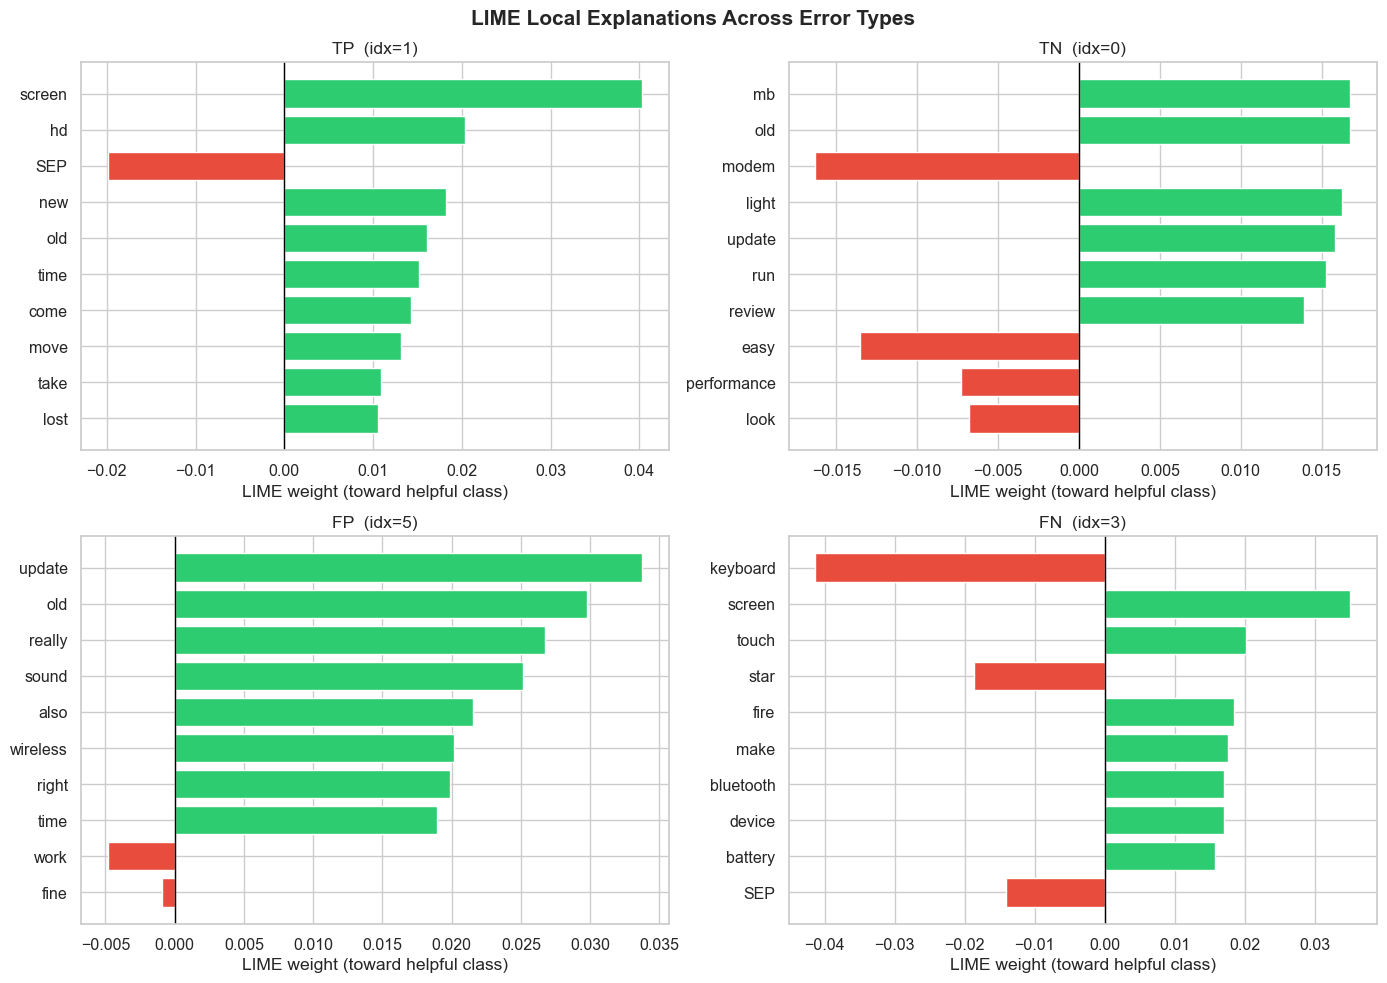


SHAP waterfall + decision + interaction


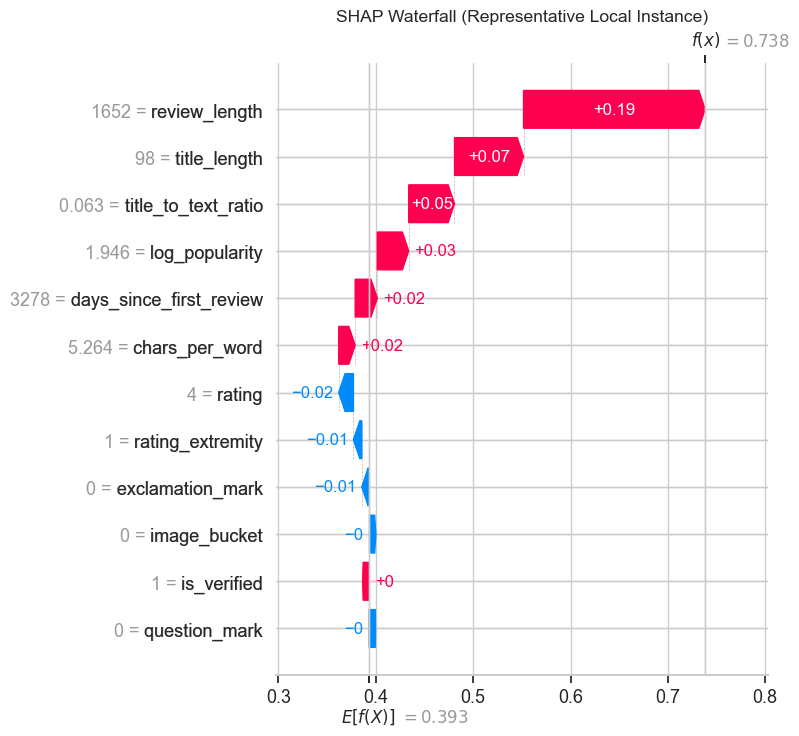

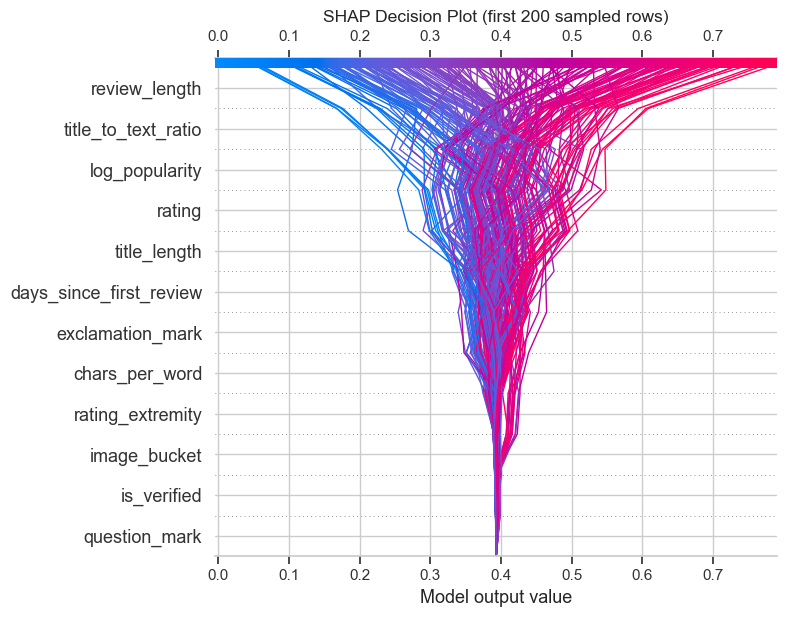

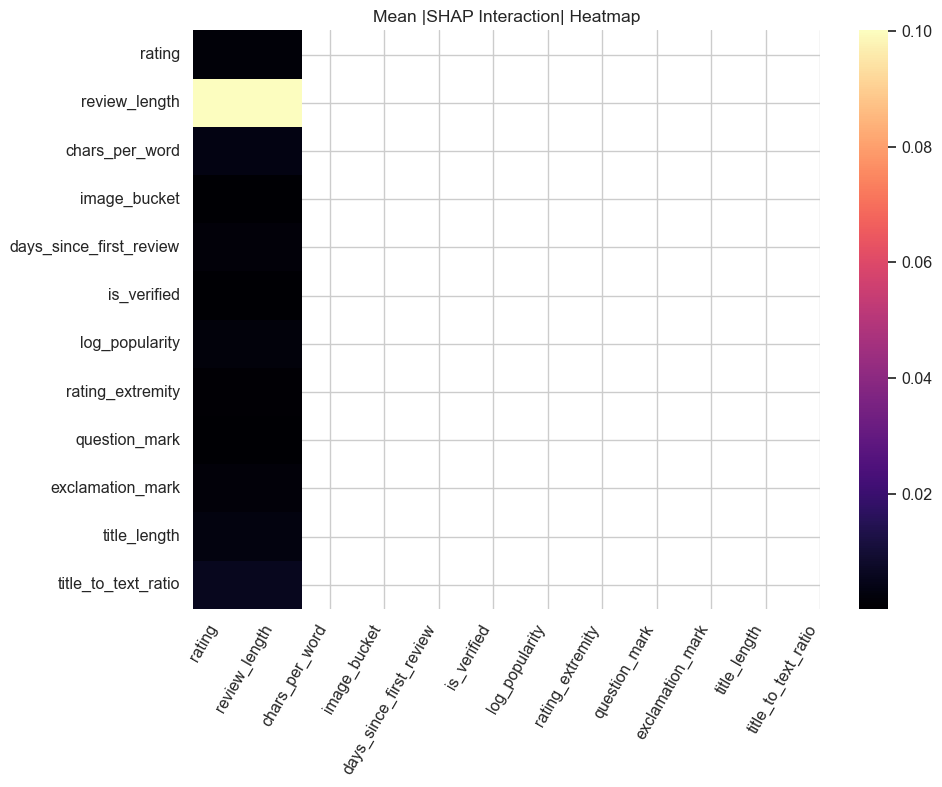

In [186]:
# Advanced explainability visuals
import matplotlib.pyplot as plt

# -----------------------------
# A) LIME panel for TP/TN/FP/FN
# -----------------------------
print("=" * 70)
print("Advanced LIME panel (TP/TN/FP/FN)")
print("=" * 70)

# Ensure required arrays exist from earlier baseline section.
if "lr_pred" not in globals() or "y_test" not in globals() or "X_test_text" not in globals():
    raise RuntimeError("Run baseline model/evaluation cells first so lr_pred, y_test, X_test_text are available.")

lime_cases = {
    "TP": np.where((y_test == 1) & (lr_pred == 1))[0],
    "TN": np.where((y_test == 0) & (lr_pred == 0))[0],
    "FP": np.where((y_test == 0) & (lr_pred == 1))[0],
    "FN": np.where((y_test == 1) & (lr_pred == 0))[0],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (case_name, idxs) in zip(axes, lime_cases.items()):
    if len(idxs) == 0:
        ax.text(0.5, 0.5, f"No {case_name} sample", ha="center", va="center", fontsize=11)
        ax.set_title(case_name)
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    i = int(idxs[0])
    exp = explainer.explain_instance(
        X_test_text[i],
        lr_text_predict_proba,
        labels=[1],
        num_features=10,
    )
    items = exp.as_list(label=1)
    labels = [t for t, _ in items][::-1]
    vals = [v for _, v in items][::-1]
    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in vals]

    ax.barh(labels, vals, color=colors)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"{case_name}  (idx={i})")
    ax.set_xlabel("LIME weight (toward helpful class)")

plt.suptitle("LIME Local Explanations Across Error Types", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# -------------------------------
# B) SHAP waterfall (local view)
# -------------------------------
print("\n" + "=" * 70)
print("SHAP waterfall + decision + interaction")
print("=" * 70)

# Rebuild sv_2d if not present from previous cell.
if "sv_2d" not in globals():
    if "meta_surrogate" not in globals() or "X_meta_sample" not in globals():
        raise RuntimeError("Run the prior SHAP section first so meta_surrogate and X_meta_sample exist.")
    tree_explainer = shap.TreeExplainer(meta_surrogate)
    shap_values_local = tree_explainer.shap_values(X_meta_sample)
    if isinstance(shap_values_local, list):
        cls = 1 if len(shap_values_local) > 1 else 0
        sv_2d = np.asarray(shap_values_local[cls])
    else:
        temp = np.asarray(getattr(shap_values_local, "values", shap_values_local))
        if temp.ndim == 2:
            sv_2d = temp
        elif temp.ndim == 3 and temp.shape[1] == len(META_COLS):
            cls = 1 if temp.shape[2] > 1 else 0
            sv_2d = temp[:, :, cls]
        elif temp.ndim == 3 and temp.shape[2] == len(META_COLS):
            cls = 1 if temp.shape[1] > 1 else 0
            sv_2d = temp[:, cls, :]
        else:
            raise ValueError(f"Unexpected SHAP output shape: {temp.shape}")

if "global_importance" in globals() and len(global_importance) > 0:
    top_feature_name = global_importance.index[0]
    top_local_idx = int(np.argmax(np.abs(sv_2d[:, META_COLS.index(top_feature_name)])))
else:
    top_local_idx = 0

base_val = tree_explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = np.asarray(base_val)
    base_val = float(base_val[1] if base_val.size > 1 else base_val.ravel()[0])

exp_local = shap.Explanation(
    values=sv_2d[top_local_idx],
    base_values=base_val,
    data=X_meta_sample[top_local_idx],
    feature_names=META_COLS,
)

shap.plots.waterfall(exp_local, max_display=12, show=False)
plt.title("SHAP Waterfall (Representative Local Instance)")
plt.tight_layout()
plt.show()


# -----------------------------
# C) SHAP decision plot (global)
# -----------------------------
subset_n = min(200, sv_2d.shape[0])
shap.decision_plot(
    base_val,
    sv_2d[:subset_n],
    X_meta_sample[:subset_n],
    feature_names=META_COLS,
    show=False,
)
plt.title(f"SHAP Decision Plot (first {subset_n} sampled rows)")
plt.tight_layout()
plt.show()


# ---------------------------------
# D) SHAP interaction heatmap (tree)
# ---------------------------------
try:
    inter = tree_explainer.shap_interaction_values(X_meta_sample[: min(300, X_meta_sample.shape[0])])
    if isinstance(inter, list):
        inter = inter[1] if len(inter) > 1 else inter[0]
    inter = np.asarray(inter)

    if inter.ndim == 4:
        cls = 1 if inter.shape[1] > 1 else 0
        inter = inter[:, cls, :, :]

    mean_inter = np.abs(inter).mean(axis=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(mean_inter, cmap="magma", xticklabels=META_COLS, yticklabels=META_COLS)
    plt.title("Mean |SHAP Interaction| Heatmap")
    plt.xticks(rotation=60, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Skipping SHAP interaction heatmap (not available): {e}")

## 10.2 Kevin's Model

## 10.3 Sana's Model

# 11. Semantic Analysis